In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/robikscube/hourly-energy-consumption/est_hourly.paruqet
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DOM_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/EKPC_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DUQ_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DAYTON_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJM_Load_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/NI_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/FE_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/COMED_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/AEP_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/pjm_hourly_est.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DEOK_hourly.csv
/kaggl

# Forecasting de Demanda Eléctrica Horaria

## Proyecto de Ciencia de Datos aplicado al consumo eléctrico

Este proyecto tiene como objetivo analizar y predecir la demanda eléctrica horaria utilizando datos históricos del sistema PJM Interconnection, una organización regional de transmisión eléctrica en Estados Unidos.

El dataset utilizado corresponde a **Hourly Energy Consumption**, disponible en Kaggle, el cual contiene registros horarios de consumo eléctrico medidos en megawatts para distintas zonas del mercado PJM.

El propósito del proyecto es construir un flujo completo de análisis de series de tiempo, desde la exploración inicial de los datos hasta la generación de modelos predictivos capaces de anticipar la demanda eléctrica futura.

## 1. Contexto del problema

La demanda eléctrica es una variable crítica para la planificación, operación y gestión de los sistemas energéticos. 

Una predicción adecuada del consumo permite anticipar períodos de alta demanda, mejorar la asignación de recursos, reducir riesgos operacionales y apoyar la toma de decisiones en generación, transmisión y distribución eléctrica.

En este proyecto se trabajará con datos horarios de consumo eléctrico, lo que permite capturar patrones de comportamiento asociados a:

- Horas del día.
- Días de la semana.
- Meses del año.
- Estacionalidad anual.
- Eventos de alta demanda o peak demand.

Este tipo de problema corresponde a un caso clásico de **forecasting de series de tiempo**, ampliamente utilizado en sectores como energía, retail, logística, finanzas y planificación operacional.

## 2. Objetivo del proyecto

El objetivo principal de este proyecto es desarrollar un modelo predictivo para estimar la demanda eléctrica horaria futura a partir de patrones históricos de consumo.

### Objetivos específicos

1. Cargar y explorar el dataset de consumo eléctrico horario.
2. Analizar la estructura temporal de la serie.
3. Identificar patrones horarios, diarios, semanales y mensuales.
4. Detectar períodos de alta demanda eléctrica.
5. Preparar variables temporales para modelamiento predictivo.
6. Entrenar modelos base de forecasting.
7. Comparar el desempeño de distintos enfoques predictivos.
8. Generar conclusiones orientadas a un contexto de negocio energético.

## 3. Carga de librerías

In [2]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# Manipulación de datos
import os
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Series de tiempo y estadística
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine Learning
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Configuración general
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

En esta etapa se importan las librerías necesarias para desarrollar el flujo completo del proyecto.

El proyecto utilizará `pandas` y `numpy` para manipulación de datos; `matplotlib`, `seaborn` y `plotly` para visualización; `statsmodels` para análisis estadístico de series de tiempo; y `scikit-learn` para modelamiento predictivo y evaluación de resultados.

La incorporación de distintas librerías permite enriquecer el análisis sin perder coherencia metodológica. Python será el lenguaje principal del proyecto, mientras que R se incorporará posteriormente como anexo metodológico complementario.

## 4. Revisión de archivos disponibles en Kaggle

Antes de cargar un archivo específico, se inspecciona el directorio de entrada de Kaggle para identificar todos los archivos disponibles dentro del dataset.

Esto es importante porque el dataset contiene múltiples archivos CSV asociados a distintas zonas eléctricas del sistema PJM.

In [3]:
# ============================================================
# 2. EXPLORACIÓN DE ARCHIVOS DISPONIBLES
# ============================================================

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/robikscube/hourly-energy-consumption/est_hourly.paruqet
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DOM_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/EKPC_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DUQ_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DAYTON_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJM_Load_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/NI_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/FE_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/COMED_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/AEP_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/pjm_hourly_est.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DEOK_hourly.csv
/kaggl

El dataset contiene distintos archivos asociados a zonas o subconjuntos del sistema eléctrico PJM. 

Para desarrollar una primera versión controlada del proyecto, se seleccionará inicialmente el archivo `PJME_hourly.csv`, correspondiente a una zona específica del mercado PJM.

Trabajar primero con una sola serie permite construir una metodología clara de análisis y modelamiento, la cual posteriormente puede ser extendida a otras zonas eléctricas.

## 5. Carga del dataset principal

Para esta primera etapa del proyecto se utilizará el archivo `PJME_hourly.csv`.

Este archivo contiene registros horarios de consumo eléctrico en megawatts. Cada observación representa el nivel de demanda eléctrica registrado en una fecha y hora específica.

In [4]:
# ============================================================
# 3. CARGA DEL DATASET PRINCIPAL
# ============================================================

path = '/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv'

df = pd.read_csv(path)

df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,"26,498.00"
1,2002-12-31 02:00:00,"25,147.00"
2,2002-12-31 03:00:00,"24,574.00"
3,2002-12-31 04:00:00,"24,393.00"
4,2002-12-31 05:00:00,"24,860.00"


La vista inicial del dataset permite confirmar que la información está estructurada en dos columnas principales:

- `Datetime`: fecha y hora del registro.
- `PJME_MW`: consumo eléctrico medido en megawatts.

Esta estructura es adecuada para construir una serie de tiempo univariada, donde la variable objetivo será el consumo eléctrico horario.

## 6. Exploración inicial del dataset

En esta sección se revisan las dimensiones del dataset, los tipos de datos, las columnas disponibles y la presencia de valores nulos.

Este paso es fundamental para detectar problemas iniciales de calidad de datos antes de avanzar hacia el análisis temporal y el modelamiento predictivo.

In [5]:
# ============================================================
# 4. EXPLORACIÓN INICIAL DEL DATASET
# ============================================================

print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas disponibles:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nPrimeras filas:")
display(df.head())

print("\nÚltimas filas:")
display(df.tail())

Dimensiones del dataset:
(145366, 2)

Columnas disponibles:
Index(['Datetime', 'PJME_MW'], dtype='object')

Tipos de datos:
Datetime     object
PJME_MW     float64
dtype: object

Valores nulos por columna:
Datetime    0
PJME_MW     0
dtype: int64

Primeras filas:


,Datetime,PJME_MW
0,2002-12-31 01:00:00,"26,498.00"
1,2002-12-31 02:00:00,"25,147.00"
2,2002-12-31 03:00:00,"24,574.00"
3,2002-12-31 04:00:00,"24,393.00"
4,2002-12-31 05:00:00,"24,860.00"



Últimas filas:


,Datetime,PJME_MW
145361,2018-01-01 20:00:00,"44,284.00"
145362,2018-01-01 21:00:00,"43,751.00"
145363,2018-01-01 22:00:00,"42,402.00"
145364,2018-01-01 23:00:00,"40,164.00"
145365,2018-01-02 00:00:00,"38,608.00"


La exploración inicial permite verificar la cantidad de registros disponibles, el tipo de dato de cada columna y la existencia de valores nulos.

Dado que se trata de una serie temporal horaria, es especialmente importante revisar que la columna de fecha sea convertida correctamente a formato `datetime` y que los registros queden ordenados cronológicamente.

## 7. Preparación de la serie temporal

Para trabajar correctamente con series de tiempo, la columna `Datetime` debe convertirse a formato temporal y utilizarse como índice del dataframe.

Esto permitirá realizar operaciones temporales como agregaciones por hora, día, semana, mes y año, además de facilitar la construcción de variables predictivas basadas en el calendario.

In [6]:
# ============================================================
# 5. PREPARACIÓN DE LA COLUMNA DATETIME
# ============================================================

df['Datetime'] = pd.to_datetime(df['Datetime'])

df = df.sort_values('Datetime')

df = df.set_index('Datetime')

df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,"30,393.00"
2002-01-01 02:00:00,"29,265.00"
2002-01-01 03:00:00,"28,357.00"
2002-01-01 04:00:00,"27,899.00"
2002-01-01 05:00:00,"28,057.00"


In [7]:
# ============================================================
# 6. REVISIÓN DEL RANGO TEMPORAL
# ============================================================

print("Fecha inicial:", df.index.min())
print("Fecha final:", df.index.max())
print("Cantidad total de registros:", len(df))

Fecha inicial: 2002-01-01 01:00:00
Fecha final: 2018-08-03 00:00:00
Cantidad total de registros: 145366


Una vez convertida la columna `Datetime`, el dataset queda estructurado como una serie temporal indexada por fecha y hora.

Esto facilita el análisis cronológico de la demanda eléctrica y permite identificar el rango histórico cubierto por los datos.

## 8. Visualización general del consumo eléctrico

La primera visualización de la serie completa permite observar el comportamiento general de la demanda eléctrica a lo largo del tiempo.

Este gráfico ayuda a identificar visualmente patrones de estacionalidad, cambios de nivel, períodos de alta variabilidad y posibles eventos extremos de consumo.

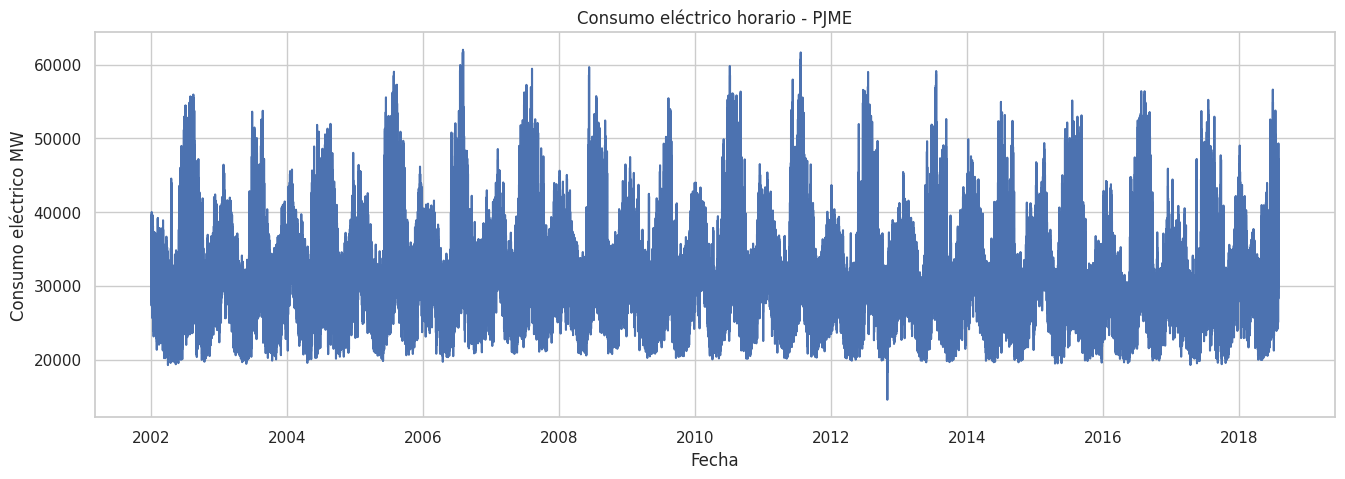

In [8]:
# ============================================================
# 7. VISUALIZACIÓN GENERAL DE LA SERIE TEMPORAL
# ============================================================

plt.figure(figsize=(16, 5))
plt.plot(df.index, df['PJME_MW'])
plt.title('Consumo eléctrico horario - PJME')
plt.xlabel('Fecha')
plt.ylabel('Consumo eléctrico MW')
plt.grid(True)
plt.show()

La serie muestra una alta frecuencia de observaciones debido a que los datos son horarios.

A simple vista se pueden observar fluctuaciones recurrentes en la demanda eléctrica, lo que sugiere la presencia de patrones temporales asociados al comportamiento diario, semanal y estacional del consumo.

## 9. Creación de variables temporales

Para analizar y modelar una serie de tiempo horaria, es necesario extraer información del calendario a partir del índice temporal.

Estas variables permiten capturar patrones recurrentes del consumo eléctrico asociados a distintos niveles de agregación temporal, como la hora del día, el día de la semana, el mes y el año.

En esta etapa se crearán variables temporales que posteriormente serán utilizadas tanto para el análisis exploratorio como para el modelamiento predictivo.

In [9]:
# ============================================================
# 8. CREACIÓN DE VARIABLES TEMPORALES
# ============================================================

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['dayofmonth'] = df.index.day
df['dayofyear'] = df.index.dayofyear
df['weekofyear'] = df.index.isocalendar().week.astype(int)
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year

df.head()

,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year
Datetime,,,,,,,,,
2002-01-01 01:00:00,"30,393.00",1,1,1,1,1,1,1,2002
2002-01-01 02:00:00,"29,265.00",2,1,1,1,1,1,1,2002
2002-01-01 03:00:00,"28,357.00",3,1,1,1,1,1,1,2002
2002-01-01 04:00:00,"27,899.00",4,1,1,1,1,1,1,2002
2002-01-01 05:00:00,"28,057.00",5,1,1,1,1,1,1,2002


Las variables temporales creadas permiten descomponer el comportamiento de la demanda eléctrica en distintas dimensiones de tiempo.

Esto es especialmente relevante porque el consumo eléctrico no suele comportarse de manera aleatoria, sino que responde a rutinas humanas, ciclos laborales, condiciones climáticas y patrones estacionales.

## 10. Validación y tratamiento de continuidad temporal

Dado que el dataset corresponde a datos horarios, se espera que entre un registro y otro exista una diferencia de una hora.

La validación inicial detectó timestamps duplicados y algunas fechas faltantes dentro del rango histórico. En problemas de forecasting, estos aspectos deben tratarse antes de entrenar modelos predictivos, ya que muchos algoritmos asumen observaciones igualmente espaciadas en el tiempo.

Para corregir la serie, se consolidan los duplicados utilizando el promedio y posteriormente se reconstruye el índice horario completo, imputando los valores faltantes mediante interpolación temporal.

In [10]:
# ============================================================
# 9. VALIDACIÓN DE DUPLICADOS TEMPORALES
# ============================================================

duplicated_dates = df.index.duplicated().sum()

print("Cantidad de fechas duplicadas:", duplicated_dates)

if duplicated_dates > 0:
    print("\nFechas duplicadas detectadas:")
    display(df[df.index.duplicated(keep=False)].sort_index())

Cantidad de fechas duplicadas: 4

Fechas duplicadas detectadas:


,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year
Datetime,,,,,,,,,
2014-11-02 02:00:00,"23,755.00",2,6,2,306,44,11,4,2014
2014-11-02 02:00:00,"22,935.00",2,6,2,306,44,11,4,2014
2015-11-01 02:00:00,"21,567.00",2,6,1,305,44,11,4,2015
2015-11-01 02:00:00,"21,171.00",2,6,1,305,44,11,4,2015
2016-11-06 02:00:00,"20,795.00",2,6,6,311,44,11,4,2016
2016-11-06 02:00:00,"21,692.00",2,6,6,311,44,11,4,2016
2017-11-05 02:00:00,"21,236.00",2,6,5,309,44,11,4,2017
2017-11-05 02:00:00,"20,666.00",2,6,5,309,44,11,4,2017


La validación detecta la existencia de registros duplicados para algunas fechas y horas.

En una serie temporal horaria, cada timestamp debería representar una única observación. Por lo tanto, los duplicados deben ser tratados antes de realizar análisis agregados o entrenar modelos predictivos.

In [11]:
# ============================================================
# 10. TRATAMIENTO DE DUPLICADOS TEMPORALES
# ============================================================

# Si existen timestamps duplicados, se consolida la información usando el promedio.
# Esta decisión es conservadora porque mantiene la señal temporal sin eliminar completamente información.

df = df.groupby(df.index).mean()

print("Cantidad de fechas duplicadas después del tratamiento:", df.index.duplicated().sum())
print("Dimensiones después de tratar duplicados:", df.shape)

Cantidad de fechas duplicadas después del tratamiento: 0
Dimensiones después de tratar duplicados: (145362, 9)


In [12]:
# ============================================================
# 11. VALIDACIÓN DE FRECUENCIA HORARIA
# ============================================================

expected_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='h'
)

missing_dates = expected_range.difference(df.index)

print("Cantidad de fechas esperadas:", len(expected_range))
print("Cantidad de registros reales:", len(df))
print("Cantidad de fechas faltantes:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nPrimeras fechas faltantes:")
    print(missing_dates[:10])

Cantidad de fechas esperadas: 145392
Cantidad de registros reales: 145362
Cantidad de fechas faltantes: 30

Primeras fechas faltantes:
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00'],
              dtype='datetime64[ns]', freq=None)


La revisión de frecuencia horaria permite identificar si existen horas faltantes dentro del rango temporal completo.

En este caso, al tratarse de un número bajo de fechas faltantes en relación con el tamaño total del dataset, se optará por reconstruir el índice horario completo e imputar los valores faltantes mediante interpolación temporal.

In [13]:
# ============================================================
# 12. TRATAMIENTO DE FECHAS FALTANTES
# ============================================================

# Se reconstruye la serie con frecuencia horaria completa.
df = df.reindex(expected_range)

# Se asigna nombre al índice para mantener claridad en el dataframe.
df.index.name = 'Datetime'

# Se imputan valores faltantes de la variable objetivo mediante interpolación temporal.
df['PJME_MW'] = df['PJME_MW'].interpolate(method='time')

# Validación posterior al tratamiento.
missing_after = df['PJME_MW'].isnull().sum()

print("Valores faltantes en PJME_MW después de interpolar:", missing_after)
print("Cantidad final de registros:", len(df))
print("Fecha inicial:", df.index.min())
print("Fecha final:", df.index.max())

Valores faltantes en PJME_MW después de interpolar: 0
Cantidad final de registros: 145392
Fecha inicial: 2002-01-01 01:00:00
Fecha final: 2018-08-03 00:00:00


In [14]:
# ============================================================
# 13. RECREACIÓN DE VARIABLES TEMPORALES DESPUÉS DEL REINDEX
# ============================================================

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['dayofmonth'] = df.index.day
df['dayofyear'] = df.index.dayofyear
df['weekofyear'] = df.index.isocalendar().week.astype(int)
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year

df.head()

,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year
Datetime,,,,,,,,,
2002-01-01 01:00:00,"30,393.00",1,1,1,1,1,1,1,2002
2002-01-01 02:00:00,"29,265.00",2,1,1,1,1,1,1,2002
2002-01-01 03:00:00,"28,357.00",3,1,1,1,1,1,1,2002
2002-01-01 04:00:00,"27,899.00",4,1,1,1,1,1,1,2002
2002-01-01 05:00:00,"28,057.00",5,1,1,1,1,1,1,2002


Después del tratamiento, la serie queda con una frecuencia horaria continua, sin duplicados y con valores faltantes imputados de forma controlada.

Dado que la cantidad de fechas faltantes es baja respecto del total de registros, la interpolación temporal es una solución razonable para esta etapa del proyecto.

Esta decisión permite conservar la estructura temporal necesaria para modelos de forecasting y evita que los modelos reciban una serie irregular.

## 11. Estadística descriptiva del consumo eléctrico

Antes de analizar patrones temporales específicos, se revisan las principales estadísticas descriptivas de la variable objetivo `PJME_MW`.

Este análisis permite conocer el nivel promedio de demanda, la variabilidad del consumo y los valores mínimos y máximos registrados durante el período histórico.

In [15]:
# ============================================================
# 14. ESTADÍSTICA DESCRIPTIVA DE LA VARIABLE OBJETIVO
# ============================================================

df['PJME_MW'].describe()

count   145,392.00
mean     32,078.93
std       6,464.28
min      14,544.00
25%      27,571.00
50%      31,420.00
75%      35,647.00
max      62,009.00
Name: PJME_MW, dtype: float64

In [16]:
# ============================================================
# 15. RESUMEN DE INDICADORES PRINCIPALES
# ============================================================

mean_demand = df['PJME_MW'].mean()
median_demand = df['PJME_MW'].median()
min_demand = df['PJME_MW'].min()
max_demand = df['PJME_MW'].max()
std_demand = df['PJME_MW'].std()

print(f"Demanda promedio: {mean_demand:,.2f} MW")
print(f"Mediana de demanda: {median_demand:,.2f} MW")
print(f"Demanda mínima: {min_demand:,.2f} MW")
print(f"Demanda máxima: {max_demand:,.2f} MW")
print(f"Desviación estándar: {std_demand:,.2f} MW")

Demanda promedio: 32,078.93 MW
Mediana de demanda: 31,420.00 MW
Demanda mínima: 14,544.00 MW
Demanda máxima: 62,009.00 MW
Desviación estándar: 6,464.28 MW


La estadística descriptiva entrega una primera aproximación al comportamiento general de la demanda eléctrica.

La diferencia entre valores mínimos, máximos y promedio permite dimensionar la amplitud del consumo y anticipar que la serie presenta variabilidad relevante, lo que justifica un análisis más detallado por patrones temporales.

## 12. Distribución del consumo eléctrico

La distribución de la demanda permite observar la concentración de los valores de consumo y detectar si existen rangos especialmente frecuentes o valores extremos.

Este análisis es útil para comprender si el consumo se distribuye de forma relativamente simétrica o si existen períodos de demanda inusualmente alta.

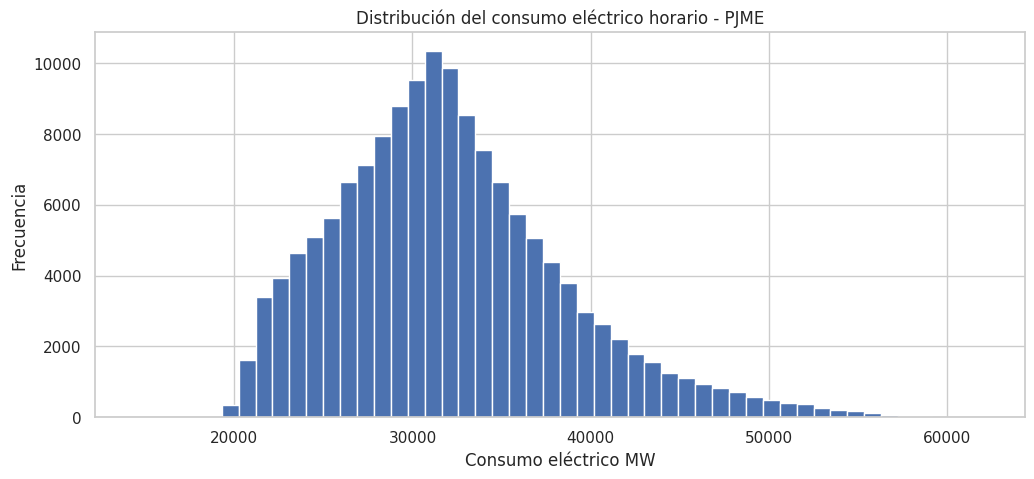

In [17]:
# ============================================================
# 16. HISTOGRAMA DEL CONSUMO ELÉCTRICO
# ============================================================

plt.figure(figsize=(12, 5))
plt.hist(df['PJME_MW'], bins=50)
plt.title('Distribución del consumo eléctrico horario - PJME')
plt.xlabel('Consumo eléctrico MW')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

El histograma permite observar la frecuencia con la que aparecen distintos niveles de consumo eléctrico.

En este tipo de series es habitual encontrar una distribución amplia, ya que la demanda varía según la hora del día, el día de la semana y la estación del año.

## 13. Patrón horario de consumo

Uno de los patrones más importantes en la demanda eléctrica es el comportamiento por hora del día.

El consumo eléctrico suele variar significativamente entre la madrugada, la jornada laboral, la tarde y la noche. Analizar este patrón permite identificar las horas de mayor y menor demanda promedio.

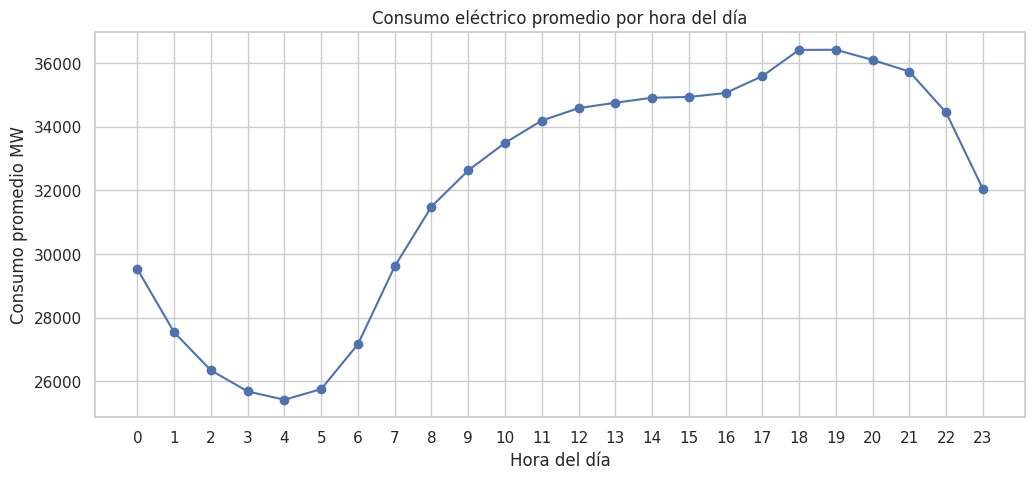

In [18]:
# ============================================================
# 17. PATRÓN PROMEDIO POR HORA DEL DÍA
# ============================================================

hourly_pattern = df.groupby('hour')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Consumo promedio MW')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [19]:
# ============================================================
# 18. TABLA DE CONSUMO PROMEDIO POR HORA
# ============================================================

hourly_pattern_df = hourly_pattern.reset_index()
hourly_pattern_df.columns = ['hour', 'avg_demand_MW']

hourly_pattern_df.sort_values('avg_demand_MW', ascending=False).head(10)

,hour,avg_demand_MW
19,19,"36,426.63"
18,18,"36,421.93"
20,20,"36,106.84"
21,21,"35,741.06"
17,17,"35,596.05"
16,16,"35,065.39"
15,15,"34,940.67"
14,14,"34,916.60"
13,13,"34,759.57"
12,12,"34,588.62"


El análisis horario permite identificar las horas del día en que la demanda eléctrica promedio tiende a ser más alta.

Este patrón es fundamental para el modelamiento predictivo, ya que la hora del día suele ser una de las variables más relevantes en modelos de forecasting de consumo eléctrico.

## 14. Patrón semanal de consumo

Además del patrón horario, la demanda eléctrica puede presentar diferencias importantes según el día de la semana.

En muchos sistemas eléctricos, los días laborales presentan dinámicas distintas a los fines de semana debido a cambios en la actividad industrial, comercial y residencial.

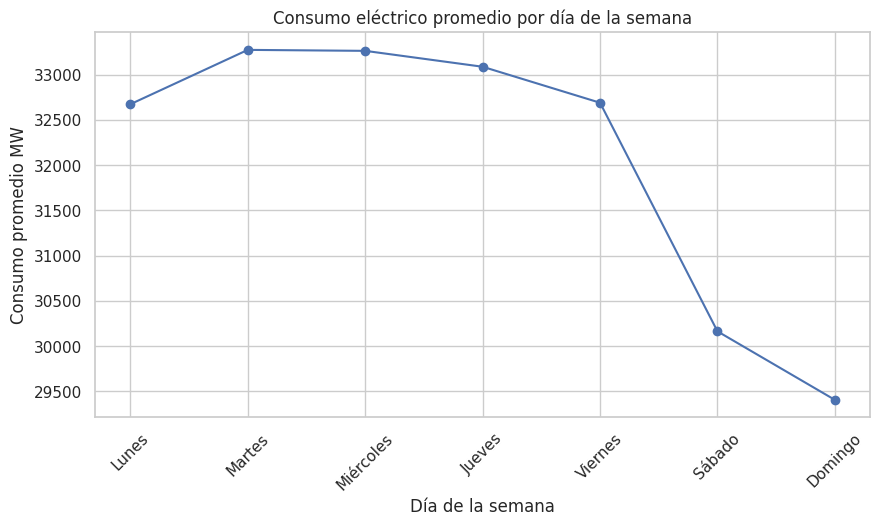

In [20]:
# ============================================================
# 19. PATRÓN PROMEDIO POR DÍA DE LA SEMANA
# ============================================================

weekly_pattern = df.groupby('dayofweek')['PJME_MW'].mean()

plt.figure(figsize=(10, 5))
plt.plot(weekly_pattern.index, weekly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Consumo promedio MW')
plt.xticks(
    ticks=range(0, 7),
    labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'],
    rotation=45
)
plt.grid(True)
plt.show()

In [21]:
# ============================================================
# 21. TABLA DE CONSUMO PROMEDIO POR DÍA DE LA SEMANA
# ============================================================

weekly_pattern_df = weekly_pattern.reset_index()
weekly_pattern_df.columns = ['dayofweek', 'avg_demand_MW']

day_names = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}

weekly_pattern_df['day_name'] = weekly_pattern_df['dayofweek'].map(day_names)

weekly_pattern_df.sort_values('avg_demand_MW', ascending=False)

,dayofweek,avg_demand_MW,day_name
1,1,"33,272.27",Martes
2,2,"33,261.50",Miércoles
3,3,"33,085.86",Jueves
4,4,"32,688.23",Viernes
0,0,"32,672.03",Lunes
5,5,"30,162.88",Sábado
6,6,"29,405.85",Domingo


El patrón semanal permite comparar la demanda promedio entre días laborales y fines de semana.

Esta información es relevante porque ayuda a identificar si la serie presenta ciclos asociados a la actividad económica y social durante la semana.

## 15. Patrón mensual y estacionalidad anual

La demanda eléctrica también puede presentar patrones estacionales a lo largo del año.

Estos patrones suelen estar asociados a cambios climáticos, temperatura, uso de calefacción, aire acondicionado, actividad económica y comportamiento residencial.

En esta sección se analiza el consumo promedio por mes para identificar posibles ciclos estacionales.

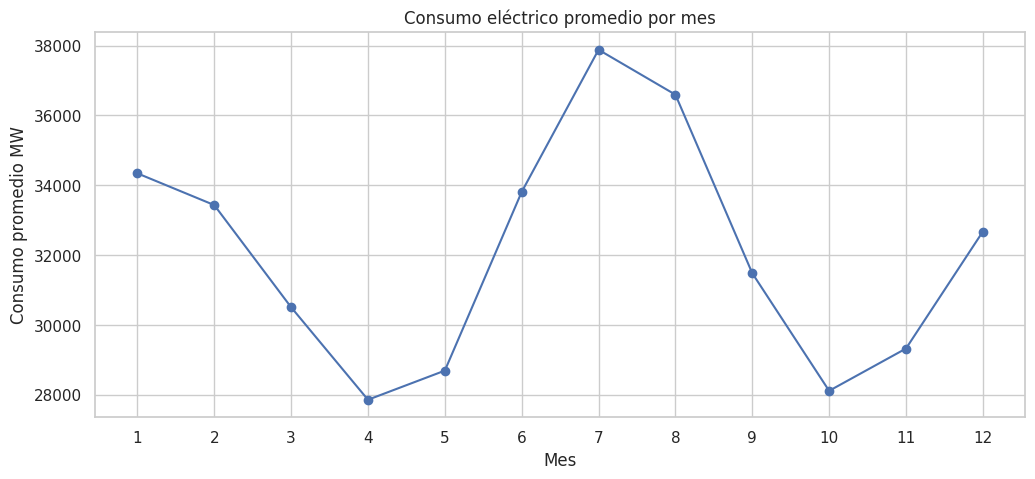

In [22]:
# ============================================================
# 22. PATRÓN PROMEDIO POR MES
# ============================================================

monthly_pattern = df.groupby('month')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por mes')
plt.xlabel('Mes')
plt.ylabel('Consumo promedio MW')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [23]:
# ============================================================
# 23. TABLA DE CONSUMO PROMEDIO POR MES
# ============================================================

monthly_pattern_df = monthly_pattern.reset_index()
monthly_pattern_df.columns = ['month', 'avg_demand_MW']

month_names = {
    1: 'Enero',
    2: 'Febrero',
    3: 'Marzo',
    4: 'Abril',
    5: 'Mayo',
    6: 'Junio',
    7: 'Julio',
    8: 'Agosto',
    9: 'Septiembre',
    10: 'Octubre',
    11: 'Noviembre',
    12: 'Diciembre'
}

monthly_pattern_df['month_name'] = monthly_pattern_df['month'].map(month_names)

monthly_pattern_df.sort_values('avg_demand_MW', ascending=False)

,month,avg_demand_MW,month_name
6,7,"37,881.97",Julio
7,8,"36,595.96",Agosto
0,1,"34,343.25",Enero
5,6,"33,811.80",Junio
1,2,"33,434.97",Febrero
11,12,"32,676.48",Diciembre
8,9,"31,484.05",Septiembre
2,3,"30,510.02",Marzo
10,11,"29,327.69",Noviembre
4,5,"28,695.36",Mayo


El análisis mensual permite observar si existen meses con mayor demanda promedio.

En sistemas eléctricos, estos patrones suelen estar fuertemente relacionados con condiciones estacionales. Por ejemplo, los meses de verano o invierno pueden presentar mayor consumo debido al uso intensivo de sistemas de climatización.

## 16. Evolución anual de la demanda eléctrica

Además de los patrones intra-anuales, es importante analizar la evolución de la demanda a nivel anual.

Este análisis permite observar si el consumo promedio ha aumentado, disminuido o se ha mantenido relativamente estable durante el período histórico disponible.

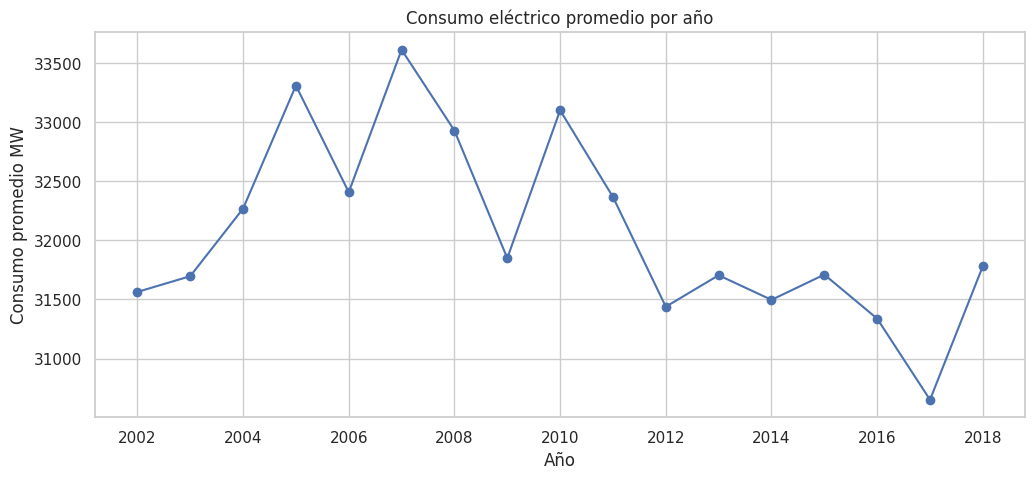

In [24]:
# ============================================================
# 24. CONSUMO PROMEDIO POR AÑO
# ============================================================

yearly_pattern = df.groupby('year')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly_pattern.index, yearly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por año')
plt.xlabel('Año')
plt.ylabel('Consumo promedio MW')
plt.grid(True)
plt.show()

In [25]:
# ============================================================
# 25. TABLA DE CONSUMO PROMEDIO POR AÑO
# ============================================================

yearly_pattern_df = yearly_pattern.reset_index()
yearly_pattern_df.columns = ['year', 'avg_demand_MW']

yearly_pattern_df

,year,avg_demand_MW
0,2002,"31,563.70"
1,2003,"31,696.65"
2,2004,"32,268.23"
3,2005,"33,308.36"
4,2006,"32,407.06"
5,2007,"33,611.36"
6,2008,"32,927.88"
7,2009,"31,849.28"
8,2010,"33,099.39"
9,2011,"32,366.50"


La evolución anual permite evaluar tendencias generales de largo plazo en la demanda eléctrica.

Este análisis es útil para identificar posibles cambios estructurales en el consumo, aunque para confirmar una tendencia sería necesario complementar la visualización con técnicas estadísticas o modelos específicos de series de tiempo.

## 17. Mapa de calor: hora del día vs día de la semana

Para visualizar simultáneamente el patrón horario y semanal, se construye una matriz de consumo promedio según hora del día y día de la semana.

Este tipo de visualización permite identificar franjas horarias de alta demanda y comparar si el comportamiento cambia entre días laborales y fines de semana.

In [26]:
# ============================================================
# 26. MATRIZ HORA VS DÍA DE LA SEMANA
# ============================================================

heatmap_data = df.pivot_table(
    values='PJME_MW',
    index='hour',
    columns='dayofweek',
    aggfunc='mean'
)

heatmap_data.columns = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

heatmap_data

,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
hour,,,,,,,
0,"28,529.78","29,831.18","30,043.36","30,020.83","29,985.96","29,642.72","28,616.58"
1,"26,734.91","27,788.00","27,954.89","27,937.34","27,915.33","27,627.63","26,789.79"
2,"25,692.81","26,609.14","26,757.68","26,731.43","26,704.65","26,333.37","25,554.23"
3,"25,174.36","25,979.33","26,106.43","26,071.67","26,046.41","25,557.09","24,798.20"
4,"25,071.05","25,774.56","25,878.04","25,843.71","25,810.89","25,143.01","24,381.76"
5,"25,634.90","26,279.50","26,350.68","26,306.41","26,245.01","25,127.18","24,300.38"
6,"27,457.40","28,132.18","28,195.19","28,116.67","27,967.60","25,653.54","24,613.97"
7,"30,494.81","31,339.48","31,390.85","31,254.29","30,962.82","26,611.24","25,217.87"
8,"32,650.76","33,494.89","33,527.85","33,376.99","33,086.30","28,011.02","26,281.13"


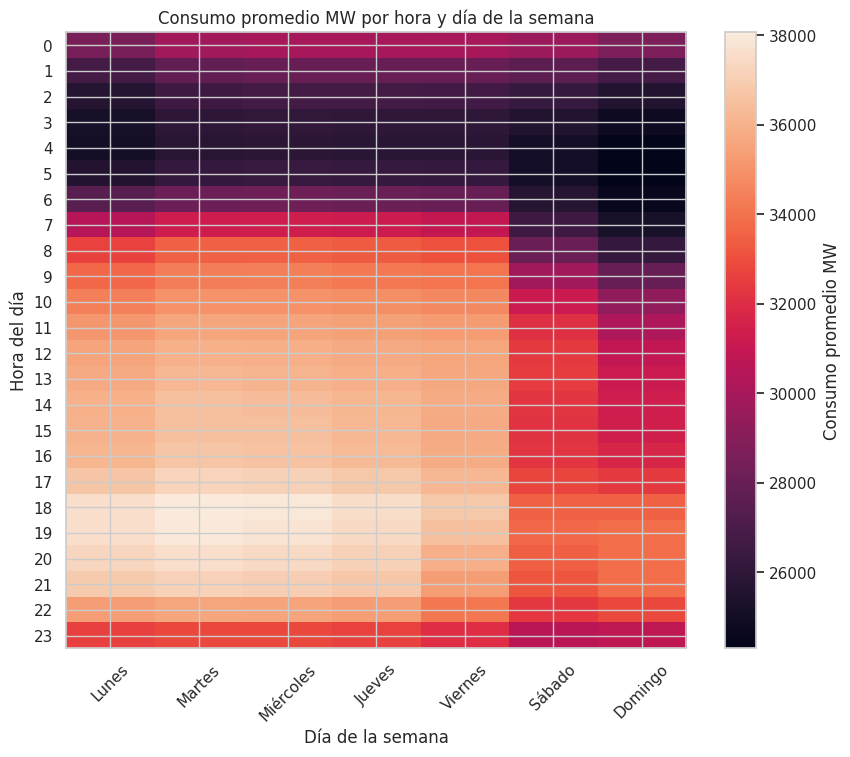

In [27]:
# ============================================================
# 27. HEATMAP HORA VS DÍA DE LA SEMANA
# ============================================================

plt.figure(figsize=(10, 8))
plt.imshow(heatmap_data, aspect='auto')
plt.title('Consumo promedio MW por hora y día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Hora del día')
plt.xticks(ticks=range(7), labels=heatmap_data.columns, rotation=45)
plt.yticks(ticks=range(24), labels=range(24))
plt.colorbar(label='Consumo promedio MW')
plt.show()

El mapa de calor permite observar de manera integrada cómo cambia la demanda eléctrica según la hora del día y el día de la semana.

Las zonas de mayor intensidad representan períodos de mayor consumo promedio, mientras que las zonas de menor intensidad reflejan períodos de menor demanda relativa.

## 18. Detección inicial de peak demand

Uno de los aspectos más relevantes en la gestión eléctrica es la identificación de períodos de alta demanda o `peak demand`.

Estos eventos son importantes porque pueden tensionar la operación del sistema eléctrico, requerir mayor capacidad de generación y afectar decisiones de planificación energética.

En esta primera aproximación se identificarán los registros que se encuentran sobre el percentil 95 de consumo.

In [28]:
# ============================================================
# 28. DEFINICIÓN DE UMBRAL DE PEAK DEMAND
# ============================================================

peak_threshold = df['PJME_MW'].quantile(0.95)

print(f"Umbral de peak demand percentil 95: {peak_threshold:,.2f} MW")

Umbral de peak demand percentil 95: 44,187.00 MW


In [29]:
# ============================================================
# 29. IDENTIFICACIÓN DE REGISTROS DE PEAK DEMAND
# ============================================================

df['is_peak_demand'] = np.where(df['PJME_MW'] >= peak_threshold, 1, 0)

peak_events = df[df['is_peak_demand'] == 1]

print("Cantidad de registros peak demand:", len(peak_events))
print("Porcentaje del total:", round(len(peak_events) / len(df) * 100, 2), "%")

peak_events.head()

Cantidad de registros peak demand: 7272
Porcentaje del total: 5.0 %


,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year,is_peak_demand
Datetime,,,,,,,,,,
2002-04-17 17:00:00,"44,537.00",17,2,17,107,16,4,2,2002,1
2002-04-17 18:00:00,"44,332.00",18,2,17,107,16,4,2,2002,1
2002-06-05 15:00:00,"44,615.00",15,2,5,156,23,6,2,2002,1
2002-06-05 16:00:00,"45,533.00",16,2,5,156,23,6,2,2002,1
2002-06-05 17:00:00,"46,006.00",17,2,5,156,23,6,2,2002,1


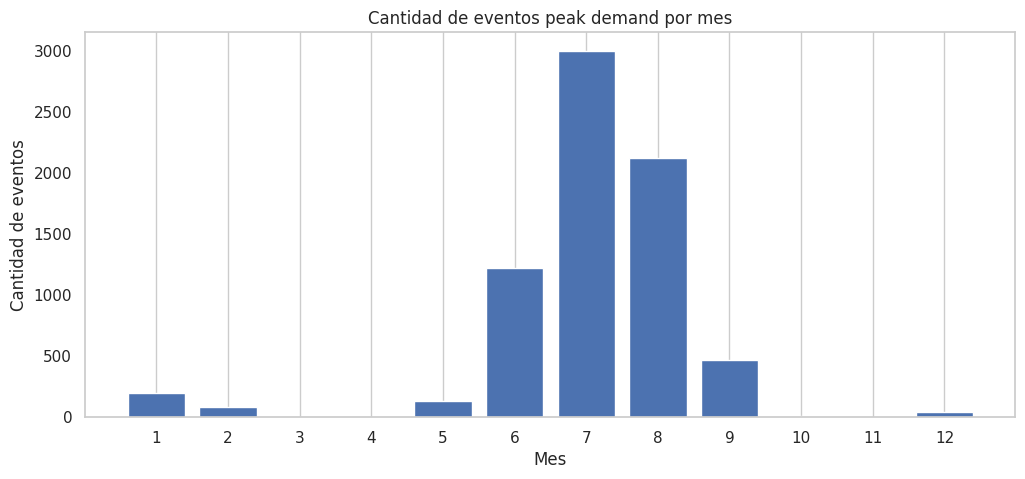

In [30]:
# ============================================================
# 30. DISTRIBUCIÓN DE PEAK DEMAND POR MES
# ============================================================

peak_by_month = peak_events.groupby('month').size()

plt.figure(figsize=(12, 5))
plt.bar(peak_by_month.index, peak_by_month.values)
plt.title('Cantidad de eventos peak demand por mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de eventos')
plt.xticks(range(1, 13))
plt.grid(axis='y')
plt.show()

La detección de peak demand permite identificar los períodos donde la demanda eléctrica se ubica dentro del 5% más alto de toda la serie histórica.

Este análisis entrega una primera visión sobre la concentración temporal de los eventos de alta demanda y puede ser utilizado posteriormente para análisis de riesgo operacional, planificación de capacidad o diseño de estrategias de respuesta ante demanda.

## 19. Conclusiones preliminares del análisis exploratorio

En esta primera etapa del proyecto se realizó una exploración inicial del consumo eléctrico horario de la zona PJME.

A partir del análisis se observaron elementos clave para el desarrollo posterior del modelo predictivo:

1. La serie cuenta con una estructura temporal horaria adecuada para forecasting.
2. La demanda eléctrica presenta variabilidad relevante a lo largo del tiempo.
3. Existen patrones diferenciados según la hora del día.
4. El consumo varía según el día de la semana, lo que sugiere comportamiento asociado a ciclos laborales y residenciales.
5. La demanda promedio cambia entre meses, evidenciando posible estacionalidad anual.
6. Los eventos de peak demand pueden identificarse mediante umbrales estadísticos como el percentil 95.

Estos hallazgos justifican avanzar hacia una etapa de preparación de datos para modelamiento, incorporando variables temporales, rezagos de demanda y validación temporal.

## Segunda fase del proyecto: modelamiento predictivo y valor de negocio

Luego de realizar la exploración inicial de la demanda eléctrica horaria, el proyecto avanza hacia una etapa de modelamiento predictivo.

El objetivo de esta fase es construir modelos capaces de estimar la demanda eléctrica futura utilizando patrones históricos, variables temporales, rezagos y promedios móviles.

Además del desempeño técnico, esta etapa busca conectar los resultados del modelo con posibles aplicaciones reales para empresas eléctricas, operadores del sistema, grandes consumidores, gestores energéticos y usuarios finales.

## 20. Preparación del dataset para forecasting

Para construir modelos predictivos, se requiere transformar la serie temporal en una estructura supervisada.

Esto significa que la variable objetivo será la demanda eléctrica futura, mientras que las variables explicativas incluirán información temporal, rezagos de consumo y promedios móviles.

Este enfoque permite que modelos de machine learning aprendan patrones históricos asociados al comportamiento horario, semanal y estacional de la demanda eléctrica.

In [31]:
# ============================================================
# 31. CREACIÓN DE VARIABLES PARA FORECASTING
# ============================================================

# Copia del dataframe tratado para modelamiento
model_df = df.copy()

# Rezagos horarios
model_df['lag_1'] = model_df['PJME_MW'].shift(1)       # hora anterior
model_df['lag_24'] = model_df['PJME_MW'].shift(24)     # mismo horario del día anterior
model_df['lag_168'] = model_df['PJME_MW'].shift(168)   # mismo horario de la semana anterior

# Promedios móviles históricos
model_df['rolling_24'] = model_df['PJME_MW'].shift(1).rolling(window=24).mean()
model_df['rolling_168'] = model_df['PJME_MW'].shift(1).rolling(window=168).mean()

# Variables cíclicas para capturar periodicidad
model_df['hour_sin'] = np.sin(2 * np.pi * model_df['hour'] / 24)
model_df['hour_cos'] = np.cos(2 * np.pi * model_df['hour'] / 24)
model_df['month_sin'] = np.sin(2 * np.pi * model_df['month'] / 12)
model_df['month_cos'] = np.cos(2 * np.pi * model_df['month'] / 12)
model_df['dayofweek_sin'] = np.sin(2 * np.pi * model_df['dayofweek'] / 7)
model_df['dayofweek_cos'] = np.cos(2 * np.pi * model_df['dayofweek'] / 7)

# Eliminación de registros con nulos generados por rezagos y ventanas móviles
model_df = model_df.dropna()

print("Dimensiones del dataset original:", df.shape)
print("Dimensiones del dataset para modelamiento:", model_df.shape)

model_df.head()

Dimensiones del dataset original: (145392, 10)
Dimensiones del dataset para modelamiento: (145224, 21)


,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year,is_peak_demand,lag_1,lag_24,lag_168,rolling_24,rolling_168,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos
Datetime,,,,,,,,,,,,,,,,,,,,,
2002-01-08 01:00:00,"29,445.00",1,1,8,8,2,1,1,2002,0,"31,187.00","26,862.00","30,393.00","33,452.58","32,519.51",0.26,0.97,0.50,0.87,0.78,0.62
2002-01-08 02:00:00,"28,670.00",2,1,8,8,2,1,1,2002,0,"29,445.00","25,976.00","29,265.00","33,560.21","32,513.87",0.50,0.87,0.50,0.87,0.78,0.62
2002-01-08 03:00:00,"28,375.00",3,1,8,8,2,1,1,2002,0,"28,670.00","25,641.00","28,357.00","33,672.46","32,510.33",0.71,0.71,0.50,0.87,0.78,0.62
2002-01-08 04:00:00,"28,542.00",4,1,8,8,2,1,1,2002,0,"28,375.00","25,666.00","27,899.00","33,786.38","32,510.43",0.87,0.50,0.50,0.87,0.78,0.62
2002-01-08 05:00:00,"29,261.00",5,1,8,8,2,1,1,2002,0,"28,542.00","26,328.00","28,057.00","33,906.21","32,514.26",0.97,0.26,0.50,0.87,0.78,0.62


Se incorporan rezagos de demanda para entregar memoria temporal al modelo:

- `lag_1`: consumo de la hora anterior.
- `lag_24`: consumo del mismo horario del día anterior.
- `lag_168`: consumo del mismo horario de la semana anterior.

También se agregan promedios móviles de 24 y 168 horas para capturar tendencia reciente diaria y semanal.

Las variables cíclicas permiten representar correctamente patrones horarios, semanales y mensuales, evitando que el modelo interprete variables como la hora 23 y la hora 0 como valores lejanos cuando en realidad son temporalmente consecutivos.

## 21. Separación temporal entre entrenamiento y prueba

En problemas de series de tiempo no se debe dividir el dataset de forma aleatoria, ya que eso provocaría fuga de información desde el futuro hacia el pasado.

Por esta razón, se utilizará una separación temporal: los datos más antiguos serán usados para entrenamiento y el último período histórico será reservado para prueba.

En esta primera versión, se utilizará el último año de datos como conjunto de prueba.

In [32]:
# ============================================================
# 32. DEFINICIÓN DE VARIABLES PREDICTORAS Y OBJETIVO
# ============================================================

target = 'PJME_MW'

features = [
    'hour', 'dayofweek', 'dayofmonth', 'dayofyear', 'weekofyear',
    'month', 'quarter', 'year',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dayofweek_sin', 'dayofweek_cos',
    'lag_1', 'lag_24', 'lag_168',
    'rolling_24', 'rolling_168'
]

X = model_df[features]
y = model_df[target]

print("Cantidad de variables predictoras:", len(features))
print("Variable objetivo:", target)

Cantidad de variables predictoras: 19
Variable objetivo: PJME_MW


In [33]:
# ============================================================
# 33. SPLIT TEMPORAL TRAIN / TEST
# ============================================================

# Se reserva el último año como período de prueba.
test_start_date = model_df.index.max() - pd.DateOffset(years=1)

train = model_df[model_df.index < test_start_date]
test = model_df[model_df.index >= test_start_date]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Fecha de inicio train:", train.index.min())
print("Fecha de término train:", train.index.max())
print("Fecha de inicio test:", test.index.min())
print("Fecha de término test:", test.index.max())
print("Registros train:", len(train))
print("Registros test:", len(test))

Fecha de inicio train: 2002-01-08 01:00:00
Fecha de término train: 2017-08-02 23:00:00
Fecha de inicio test: 2017-08-03 00:00:00
Fecha de término test: 2018-08-03 00:00:00
Registros train: 136463
Registros test: 8761


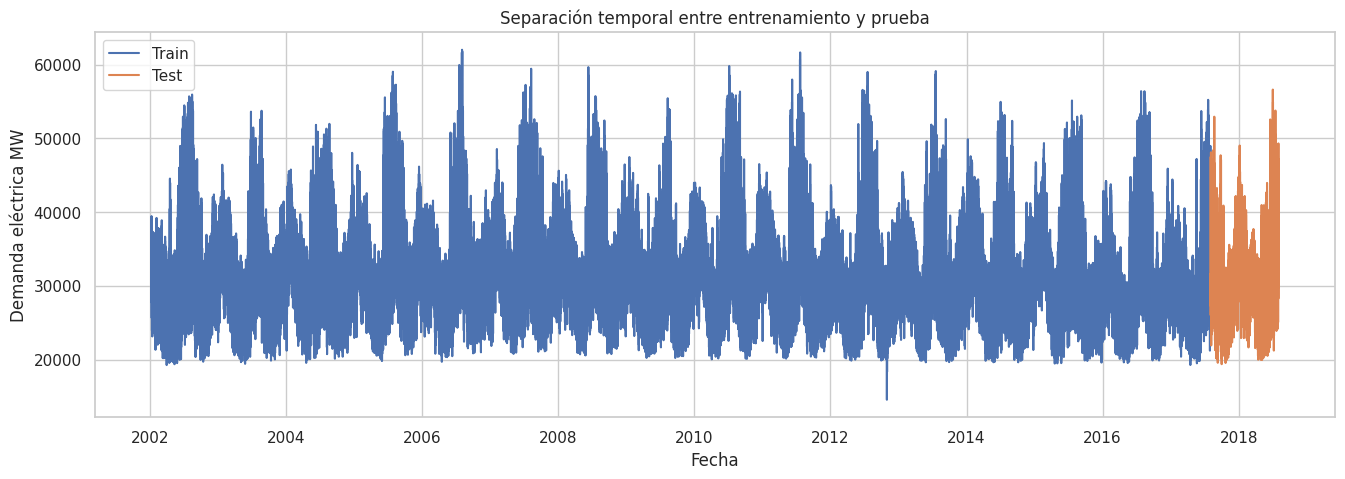

In [34]:
# ============================================================
# 34. VISUALIZACIÓN DEL SPLIT TEMPORAL
# ============================================================

plt.figure(figsize=(16, 5))
plt.plot(train.index, train[target], label='Train')
plt.plot(test.index, test[target], label='Test')
plt.title('Separación temporal entre entrenamiento y prueba')
plt.xlabel('Fecha')
plt.ylabel('Demanda eléctrica MW')
plt.legend()
plt.grid(True)
plt.show()

La separación temporal permite evaluar el desempeño del modelo en un período futuro no utilizado durante el entrenamiento.

Esta estrategia es más realista para un problema de forecasting, ya que simula el escenario en que el modelo debe predecir datos que todavía no conoce.

## 22. Métricas de evaluación

Para comparar modelos se utilizarán métricas comunes en problemas de regresión y forecasting:

- **MAE**: error absoluto medio. Mide el error promedio en las mismas unidades de la variable objetivo.
- **RMSE**: penaliza con mayor fuerza errores grandes.
- **MAPE**: expresa el error como porcentaje respecto del valor real.

Estas métricas permiten comparar modelos desde distintas perspectivas: error medio, sensibilidad a errores grandes y error relativo porcentual.

In [35]:
# ============================================================
# 35. FUNCIÓN DE EVALUACIÓN DE MODELOS
# ============================================================

def evaluate_forecast(y_true, y_pred, model_name):
    """
    Calcula métricas principales para evaluar modelos de forecasting.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    results = {
        'model': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE_%': round(mape, 2)
    }
    
    return results

Para mantener claridad y consistencia en la comparación de modelos, las métricas se reportarán con dos decimales.

- `MAE`: 2 decimales, expresado en MW.
- `RMSE`: 2 decimales, expresado en MW.
- `MAPE`: 2 decimales, expresado como porcentaje.

Además, para la presentación en español se utilizará el formato numérico habitual:

- Separador de miles: punto.
- Separador decimal: coma.

Ejemplo:

- `2.306,94 MW`
- `4.146,19 MW`
- `7,32%`

Para los cálculos internos se mantendrá el formato numérico estándar de Python, donde el punto se usa como separador decimal. Esto evita errores en operaciones matemáticas, modelos y métricas.

La conversión a formato español se aplicará solo al momento de presentar resultados en tablas, textos Markdown o reportes ejecutivos.

In [36]:
# ============================================================
# 35.1 FUNCIÓN AUXILIAR DE FORMATO NUMÉRICO EN ESPAÑOL
# ============================================================

def format_spanish_number(value, decimals=2):
    """
    Convierte un número al formato usado en español:
    - punto como separador de miles
    - coma como separador decimal
    
    Ejemplo:
    2306.94 -> '2.306,94'
    """
    formatted = f"{value:,.{decimals}f}"
    formatted = formatted.replace(",", "X").replace(".", ",").replace("X", ".")
    return formatted

In [37]:
# ============================================================
# 35.2 FUNCIÓN PARA MOSTRAR RESULTADOS EN FORMATO ESPAÑOL
# ============================================================

def display_forecast_results(results_dict):
    """
    Recibe un diccionario de métricas y devuelve una versión formateada
    para presentación en español.
    """
    return {
        'Modelo': results_dict['model'],
        'MAE': f"{format_spanish_number(results_dict['MAE'])} MW",
        'RMSE': f"{format_spanish_number(results_dict['RMSE'])} MW",
        'MAPE': f"{format_spanish_number(results_dict['MAPE_%'])}%"
    }

## 22. Modelo baseline naive

Antes de entrenar modelos avanzados, se construye un modelo base o `baseline`.

El baseline permite establecer un punto mínimo de comparación. Si un modelo avanzado no supera al baseline, entonces no justifica su complejidad adicional.

En este caso se usará como predicción el valor de demanda observado 24 horas antes, asumiendo que el consumo horario de hoy se parece al del mismo horario del día anterior.

In [38]:
# ============================================================
# 36. MODELO BASELINE NAIVE 24 HORAS
# ============================================================

y_pred_naive = test['lag_24']

baseline_results = evaluate_forecast(y_test, y_pred_naive, 'Baseline Naive lag_24')
baseline_results

{'model': 'Baseline Naive lag_24',
 'MAE': 2306.93,
 'RMSE': np.float64(3146.19),
 'MAPE_%': 7.32}

<function matplotlib.pyplot.show(close=None, block=None)>

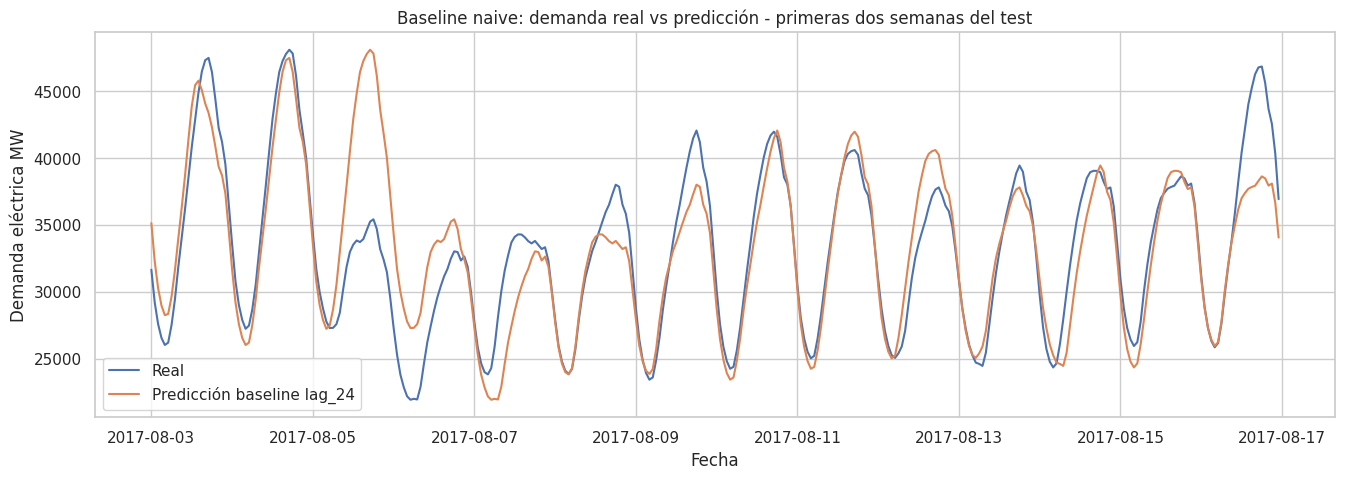

In [39]:
# ============================================================
# 37. VISUALIZACIÓN DEL BASELINE EN UNA VENTANA DE PRUEBA
# ============================================================

sample_days = 14
sample_test = test.iloc[:24 * sample_days].copy()
sample_pred = y_pred_naive.iloc[:24 * sample_days]

plt.figure(figsize=(16, 5))
plt.plot(sample_test.index, sample_test[target], label='Real')
plt.plot(sample_test.index, sample_pred, label='Predicción baseline lag_24')
plt.title('Baseline naive: demanda real vs predicción - primeras dos semanas del test')
plt.xlabel('Fecha')
plt.ylabel('Demanda eléctrica MW')
plt.legend()
plt.grid(True)
plt.show

El modelo baseline entrega una primera referencia de desempeño.

Este modelo no aprende parámetros ni relaciones complejas, pero suele ser competitivo en series con patrones diarios marcados. Por eso es una comparación importante antes de avanzar hacia modelos de machine learning.

En esta primera evaluación, el modelo `Baseline Naive lag_24` obtuvo aproximadamente:

- MAE: 2306.93 MW.
- RMSE: 3146.19 MW.
- MAPE: 7.32%.

Estos resultados indican que, usando únicamente el consumo observado 24 horas antes, el modelo logra capturar una parte relevante del patrón diario de la demanda eléctrica. El MAPE cercano al 7% sugiere que el baseline es razonablemente competitivo para una primera aproximación. Además, la diferencia entre MAE y RMSE muestra que existen errores más altos en ciertos momentos puntuales, pero no tan extremos como para desestabilizar completamente el desempeño general del modelo.

Sin embargo, el gráfico de las primeras dos semanas del período de prueba muestra que el modelo tiende a replicar bien la forma general del ciclo diario, pero presenta dificultades cuando existen cambios bruscos de nivel o peaks de demanda. En esos períodos, la predicción puede quedar desplazada respecto de la demanda real, especialmente cuando el comportamiento de un día no se parece al del día anterior.

Este resultado confirma que el patrón diario es una señal fuerte dentro de la serie, pero también evidencia la necesidad de incorporar modelos más flexibles y variables adicionales que capturen efectos semanales, estacionales, climáticos o eventos atípicos.

Desde una perspectiva de negocio energético, este baseline ya entrega una señal útil: la demanda de una hora determinada suele parecerse bastante al consumo registrado en la misma hora del día anterior.

Esto podría servir como una regla operacional simple para construir alertas tempranas básicas. Sin embargo, para aplicaciones de mayor valor, como gestión de peak demand, planificación de capacidad o recomendaciones de ahorro energético, se requiere mejorar la precisión en momentos críticos.

El principal riesgo del baseline es que puede fallar justo cuando más importa: cambios bruscos, peaks de demanda o días con patrones distintos al día anterior. Por eso, los siguientes modelos deberán buscar reducir el error en esos puntos, no solo mejorar el promedio general.

## 23. Modelo de Regresión Lineal

Como primer modelo supervisado se utiliza una regresión lineal.

Este modelo permite evaluar si una combinación lineal de variables temporales, rezagos y promedios móviles es suficiente para aproximar la demanda eléctrica horaria.

Aunque puede ser limitado para capturar relaciones no lineales complejas, entrega una referencia interpretable y sencilla.

In [40]:
# ============================================================
# 38. ENTRENAMIENTO DE REGRESIÓN LINEAL
# ============================================================

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_results = evaluate_forecast(y_test, y_pred_lr, 'Linear Regression')
lr_results

{'model': 'Linear Regression',
 'MAE': 785.51,
 'RMSE': np.float64(1004.98),
 'MAPE_%': 2.48}

In [41]:
# ============================================================
# 39. COEFICIENTES DE LA REGRESIÓN LINEAL
# ============================================================

coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', ascending=False)

coef_df

,feature,coefficient
8,hour_sin,745.55
13,dayofweek_cos,167.26
0,hour,53.15
6,quarter,26.16
3,dayofyear,6.79
10,month_sin,5.39
4,weekofyear,2.44
14,lag_1,0.83
15,lag_24,0.10
17,rolling_24,0.08


La regresión lineal permite tener una primera aproximación interpretable del problema.

En esta evaluación, el modelo de `Linear Regression` obtuvo los siguientes resultados:

- MAE: 785.51 MW.
- RMSE: 1004.98 MW.
- MAPE: 2.48%.

Estos resultados muestran una mejora significativa respecto del modelo `Baseline Naive lag_24`, que había obtenido un MAE de 2306.93 MW, un RMSE de 3146.19 MW y un MAPE de 7.32%.

La reducción del MAPE desde 7.32% a 2.48% indica que la regresión lineal logra capturar de mejor manera la estructura temporal de la demanda eléctrica cuando combina variables de calendario, variables cíclicas, rezagos y promedios móviles.

Desde el punto de vista técnico, este resultado es relevante porque demuestra que un modelo simple e interpretable puede superar ampliamente a una regla naive basada solo en el consumo del día anterior.

La revisión de coeficientes muestra que las variables cíclicas asociadas a la hora del día tienen un peso relevante dentro del modelo. En particular, `hour_sin` presenta un coeficiente positivo importante, mientras que `hour_cos` presenta un coeficiente negativo alto. Esto sugiere que el modelo está capturando el ciclo diario de la demanda eléctrica mediante la representación trigonométrica de la hora.

También aparecen efectos asociados al día de la semana, especialmente a través de `dayofweek_cos` y `dayofweek_sin`, lo que confirma la existencia de un componente semanal en la demanda.

Los rezagos `lag_1`, `lag_24`, `lag_168` y los promedios móviles presentan coeficientes relativamente pequeños en comparación con las variables cíclicas. Esto no significa necesariamente que sean irrelevantes, sino que dentro de un modelo lineal su efecto marginal queda distribuido junto con otras variables temporales.

En términos prácticos, la regresión lineal se posiciona como un modelo base fuerte: mejora claramente el baseline, mantiene interpretabilidad y entrega una primera evidencia de que la demanda eléctrica puede modelarse de forma efectiva mediante variables temporales bien diseñadas.

coeficientes estimados por el modelo fueron:

| Variable | Coeficiente |
|---|---:|
| hour_sin | 745.55 |
| dayofweek_cos | 167.26 |
| hour | 53.15 |
| quarter | 26.16 |
| dayofyear | 6.79 |
| month_sin | 5.39 |
| weekofyear | 2.44 |
| lag_1 | 0.83 |
| lag_24 | 0.10 |
| rolling_24 | 0.08 |
| lag_168 | 0.07 |
| rolling_168 | -0.08 |
| year | -0.51 |
| dayofmonth | -7.66 |
| month_cos | -18.08 |
| dayofweek | -75.68 |
| dayofweek_sin | -119.57 |
| month | -225.20 |
| hour_cos | -982.16 |
|

La magnitud de `hour_sin` y `hour_cos` confirma que el ciclo horario es una de las señales más importantes para explicar la demanda eléctrica. El efecto de `dayofweek_sin` y `dayofweek_cos` sugiere que también existe una dinámica semanal relevante.

Los coeficientes de los rezagos son positivos, aunque de menor magnitud relativa. Esto indica que la memoria histórica reciente aporta información, pero en este modelo lineal la estructura cíclica del calendario parece dominar la explicación del comportamiento de la demanda.

Desde una perspectiva de negocio energético, la regresión lineal mejora de forma importante la regla operacional simple basada en el consumo del día anterior.

Esto es una conclusión relevante porque muestra que no siempre es necesario comenzar con modelos complejos para obtener mejoras predictivas significativas. Un modelo interpretable, bien alimentado con variables temporales y rezagos, puede entregar una primera solución robusta para anticipar demanda.

Con un MAPE de 2.48%, la regresión lineal podría ser considerada como una primera base para herramientas de planificación, monitoreo y alertas preliminares. Sin embargo, antes de utilizarla en decisiones críticas, todavía sería necesario analizar su comportamiento en períodos de peak demand, días atípicos y cambios bruscos de nivel.

El valor de este modelo no está solamente en su precisión, sino también en su interpretabilidad. Para una empresa, esto permite explicar por qué el modelo predice ciertos niveles de demanda y qué variables temporales influyen más en el resultado.

El siguiente paso natural es avanzar hacia modelos no lineales como Random Forest, XGBoost o LightGBM para evaluar si se puede mejorar aún más la precisión, especialmente en períodos críticos de alta demanda.

## 25. Modelo Random Forest

Random Forest es un modelo de ensamble basado en múltiples árboles de decisión.

Este tipo de modelo puede capturar relaciones no lineales entre variables y suele funcionar bien con variables de calendario, rezagos y promedios móviles.

En esta etapa se entrena un Random Forest base para comparar su desempeño contra el baseline naive y la regresión lineal.

In [42]:
# ============================================================
# 40. ENTRENAMIENTO DE RANDOM FOREST
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_results = evaluate_forecast(y_test, y_pred_rf, 'Random Forest')
rf_results

{'model': 'Random Forest',
 'MAE': 316.64,
 'RMSE': np.float64(433.67),
 'MAPE_%': 0.99}

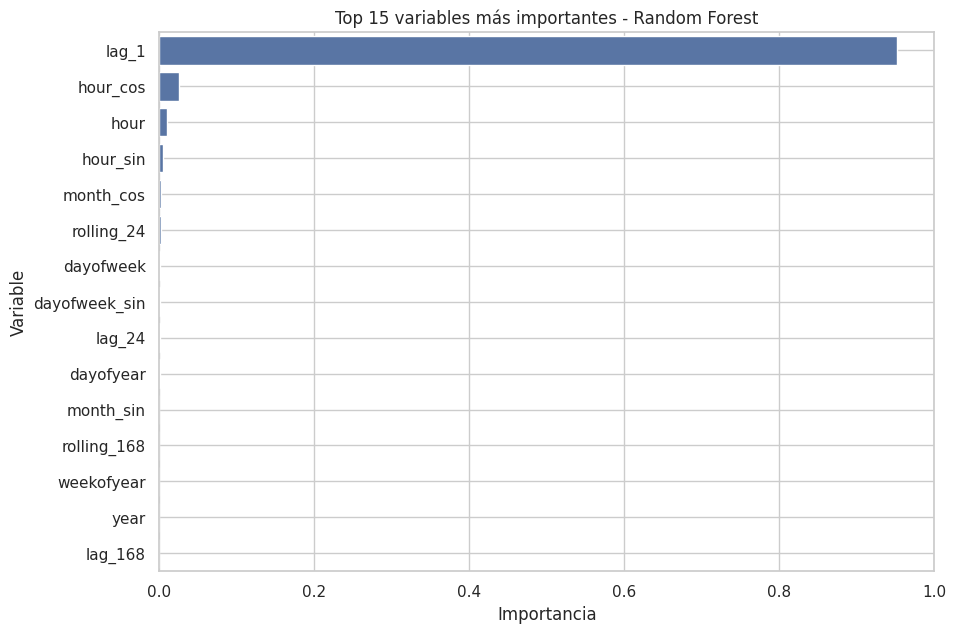

,feature,importance
14,lag_1,0.95
9,hour_cos,0.02
0,hour,0.01
8,hour_sin,0.01
11,month_cos,0.00
17,rolling_24,0.00
1,dayofweek,0.00
12,dayofweek_sin,0.00
15,lag_24,0.00
3,dayofyear,0.00


In [43]:
# ============================================================
# 41. IMPORTANCIA DE VARIABLES RANDOM FOREST
# ============================================================

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 variables más importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.grid(True)
plt.show()

importance_df.head(15)

El modelo `Random Forest` obtuvo los siguientes resultados:

- MAE: 316.64 MW.
- RMSE: 433.67 MW.
- MAPE: 0.99%.

Estos resultados representan una mejora significativa respecto de los modelos anteriores. En comparación con el `Baseline Naive lag_24`, el MAPE disminuye desde 7.32% a 0.99%. En comparación con la `Linear Regression`, el MAPE disminuye desde 2.48% a 0.99%.

Esto indica que Random Forest logra capturar relaciones no lineales y patrones temporales más complejos de la demanda eléctrica horaria. El modelo no solo utiliza variables de calendario, sino que también puede aprender interacciones entre rezagos, hora del día, ciclos diarios y otros componentes temporales.

La importancia de variables muestra que `lag_1` concentra la mayor parte del poder predictivo del modelo, con una importancia aproximada de 0.95. Esto significa que el consumo de la hora inmediatamente anterior es la señal más fuerte para estimar la demanda de la hora siguiente.

Después de `lag_1`, aparecen variables asociadas al ciclo horario, como `hour_cos`, `hour` y `hour_sin`, aunque con una importancia mucho menor. Esto confirma que el comportamiento reciente de la demanda domina la predicción, mientras que las variables de calendario aportan información complementaria.

El hecho de que `lag_24` y `lag_168` aparezcan con baja importancia relativa no significa que no sean útiles, sino que en este modelo el rezago inmediato contiene la señal más fuerte para el horizonte de predicción evaluado. Si el objetivo fuera predecir varios días hacia adelante, probablemente los rezagos diarios y semanales cobrarían mayor relevancia.

En términos técnicos, Random Forest se posiciona como el mejor modelo inicial dentro de esta comparación, superando tanto al baseline como a la regresión lineal en MAE, RMSE y MAPE.

Desde una perspectiva de negocio energético, el desempeño de Random Forest es especialmente relevante porque reduce el error promedio a un nivel cercano al 1% en términos de MAPE.

Esto sugiere que un modelo no lineal basado en datos históricos de consumo podría convertirse en una herramienta útil para monitoreo operativo, planificación de demanda y generación de alertas tempranas.

La alta importancia de `lag_1` indica que la demanda eléctrica tiene una fuerte dependencia de muy corto plazo. En aplicaciones reales, esto puede ser útil para sistemas de monitoreo casi en tiempo real, donde el consumo reciente permite anticipar el comportamiento inmediato del sistema.

Sin embargo, también aparece una advertencia importante: si el modelo depende demasiado del consumo de la hora anterior, podría tener menor capacidad para anticipar cambios abruptos causados por eventos externos, temperatura, feriados, fallas operacionales o cambios súbitos en la actividad económica.

Por esta razón, aunque Random Forest muestra un desempeño muy sólido, una aplicación empresarial debería complementarse con variables exógenas como clima, calendario laboral, tarifas eléctricas, eventos especiales y comportamiento sectorial.

Este resultado abre una línea clara de monetización: construir sistemas de alerta y dashboards predictivos que utilicen datos recientes de consumo para anticipar demanda de corto plazo y apoyar decisiones operacionales.

## 26. Comparación inicial de modelos

Una vez entrenados los primeros modelos, se comparan sus métricas de desempeño sobre el conjunto de prueba.

Esta comparación permite evaluar si los modelos supervisados logran mejorar el baseline naive y si la complejidad adicional se justifica en términos predictivos.

In [44]:
# ============================================================
# 42. COMPARACIÓN DE MODELOS
# ============================================================

results = pd.DataFrame([
    baseline_results,
    lr_results,
    rf_results
])

results = results.sort_values('MAE')
results

,model,MAE,RMSE,MAPE_%
2,Random Forest,316.64,433.67,0.99
1,Linear Regression,785.51,"1,004.98",2.48
0,Baseline Naive lag_24,"2,306.93","3,146.19",7.32


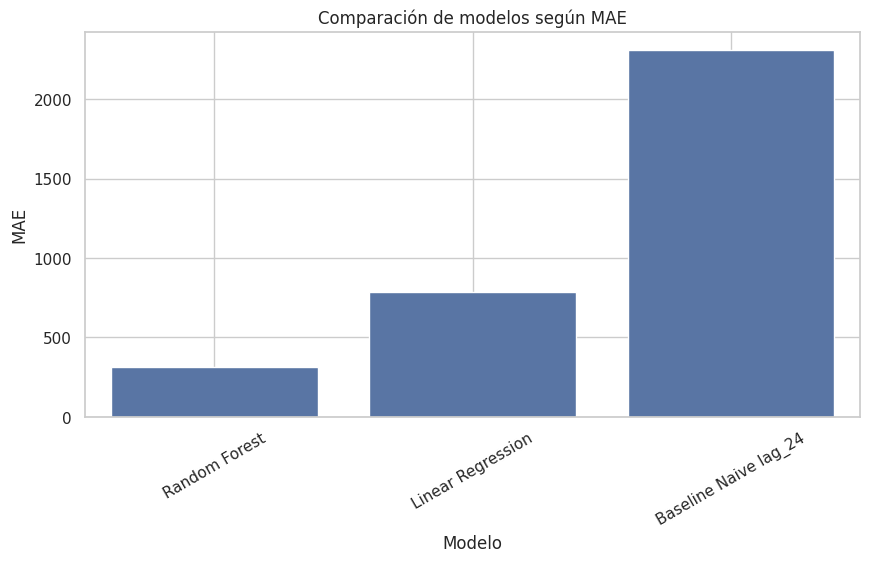

In [45]:
# ============================================================
# 43. VISUALIZACIÓN COMPARATIVA DE MÉTRICAS
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(data=results, x='model', y='MAE')
plt.title('Comparación de modelos según MAE')
plt.xlabel('Modelo')
plt.ylabel('MAE')
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

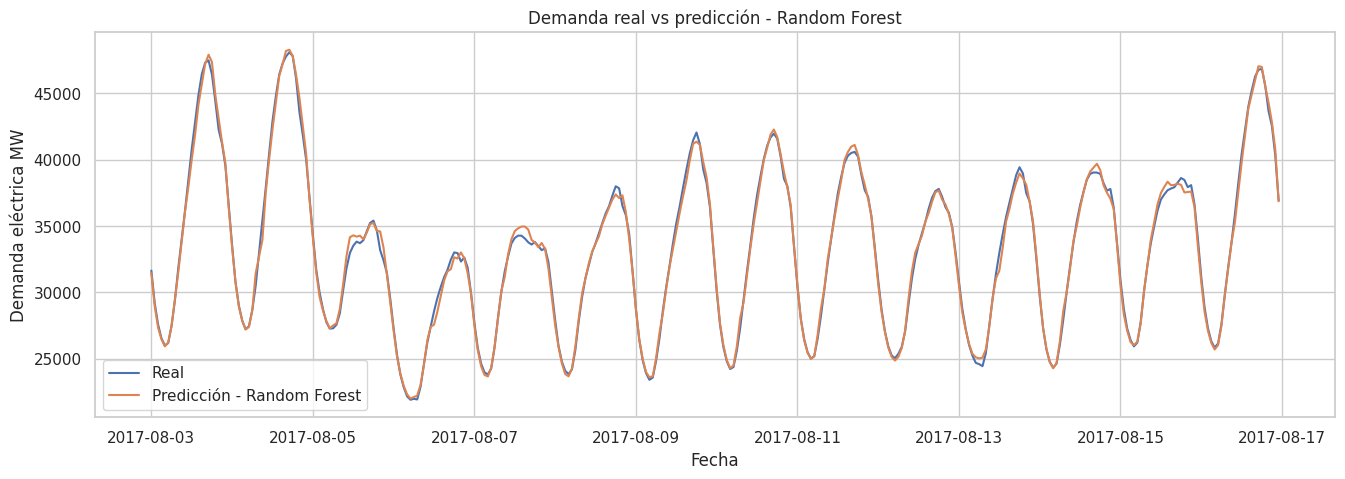

In [46]:
# ============================================================
# 44. VISUALIZACIÓN REAL VS PREDICCIÓN DEL MEJOR MODELO INICIAL
# ============================================================

best_model_name = results.iloc[0]['model']

if best_model_name == 'Baseline Naive lag_24':
    best_pred = y_pred_naive
elif best_model_name == 'Linear Regression':
    best_pred = pd.Series(y_pred_lr, index=y_test.index)
else:
    best_pred = pd.Series(y_pred_rf, index=y_test.index)

sample_days = 14

plt.figure(figsize=(16, 5))
plt.plot(y_test.iloc[:24 * sample_days].index, y_test.iloc[:24 * sample_days], label='Real')
plt.plot(best_pred.iloc[:24 * sample_days].index, best_pred.iloc[:24 * sample_days], label=f'Predicción - {best_model_name}')
plt.title(f'Demanda real vs predicción - {best_model_name}')
plt.xlabel('Fecha')
plt.ylabel('Demanda eléctrica MW')
plt.legend()
plt.grid(True)
plt.show()

La comparación inicial permite identificar qué modelo entrega mejor desempeño en el período de prueba.

Esta etapa es fundamental para construir una narrativa de modelamiento progresivo: primero se establece un baseline, luego se prueba un modelo interpretable y posteriormente se evalúa un modelo no lineal más flexible.

En una siguiente iteración se podrán incorporar modelos adicionales como XGBoost, LightGBM, SARIMA, Prophet o LSTM, dependiendo del equilibrio entre precisión, interpretabilidad y costo computacional.

### Nota metodológica sobre la comparación de modelos

La comparación entre el modelo baseline naive, la regresión lineal y Random Forest se realizó bajo un mismo escenario de evaluación.

En los tres casos se utilizó la misma serie temporal, la misma variable objetivo (`PJME_MW`), el mismo tratamiento previo de datos, el mismo período de entrenamiento y prueba, y las mismas métricas de evaluación: `MAE`, `RMSE` y `MAPE`.

Esto permite comparar los modelos bajo las mismas reglas del juego. En otras palabras, se mantiene constante el contexto del problema y solo cambia el método predictivo utilizado.

Por lo tanto, la comparación permite evaluar de forma justa si modelos más elaborados logran mejorar el desempeño de una regla simple como el baseline naive.

Bajo el mismo escenario de evaluación, los resultados muestran una mejora progresiva entre modelos:

- `Baseline Naive lag_24`: MAPE de 7.32%.
- `Linear Regression`: MAPE de 2.48%.
- `Random Forest`: MAPE de 0.99%.

Esto indica que la incorporación de variables temporales, rezagos y modelos no lineales mejora sustancialmente la capacidad predictiva sobre la demanda eléctrica horaria.

El baseline confirma que existe un patrón diario fuerte. La regresión lineal demuestra que una estructura interpretable con variables temporales bien diseñadas puede reducir significativamente el error. Random Forest, por su parte, logra el mejor desempeño al capturar relaciones no lineales y dependencia de corto plazo, especialmente mediante el rezago de una hora (`lag_1`).

## 27. Análisis de errores del mejor modelo

Además de revisar métricas agregadas, es importante analizar cómo se distribuyen los errores del modelo.

Este análisis permite identificar si el modelo tiende a sobreestimar o subestimar la demanda, y si existen períodos específicos donde los errores son más altos.

In [47]:
# ============================================================
# 45. ANÁLISIS DE ERRORES DEL MEJOR MODELO INICIAL
# ============================================================

error_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': best_pred
})

error_df['error'] = error_df['y_true'] - error_df['y_pred']
error_df['abs_error'] = error_df['error'].abs()
error_df['pct_error'] = error_df['abs_error'] / error_df['y_true'] * 100
error_df['hour'] = error_df.index.hour
error_df['dayofweek'] = error_df.index.dayofweek
error_df['month'] = error_df.index.month

error_df.head()

,y_true,y_pred,error,abs_error,pct_error,hour,dayofweek,month
Datetime,,,,,,,,
2017-08-03 00:00:00,"31,646.00","31,440.57",205.43,205.43,0.65,0,3,8
2017-08-03 01:00:00,"29,189.00","28,962.13",226.87,226.87,0.78,1,3,8
2017-08-03 02:00:00,"27,584.00","27,345.10",238.90,238.90,0.87,2,3,8
2017-08-03 03:00:00,"26,544.00","26,471.58",72.42,72.42,0.27,3,3,8
2017-08-03 04:00:00,"26,012.00","25,937.69",74.31,74.31,0.29,4,3,8


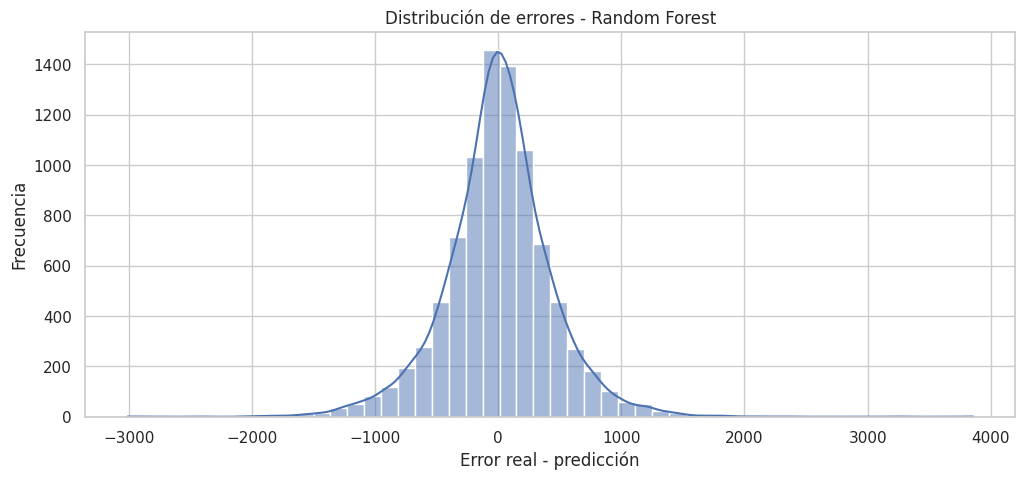

In [48]:
# ============================================================
# 46. DISTRIBUCIÓN DE ERRORES
# ============================================================

plt.figure(figsize=(12, 5))
sns.histplot(error_df['error'], bins=50, kde=True)
plt.title(f'Distribución de errores - {best_model_name}')
plt.xlabel('Error real - predicción')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

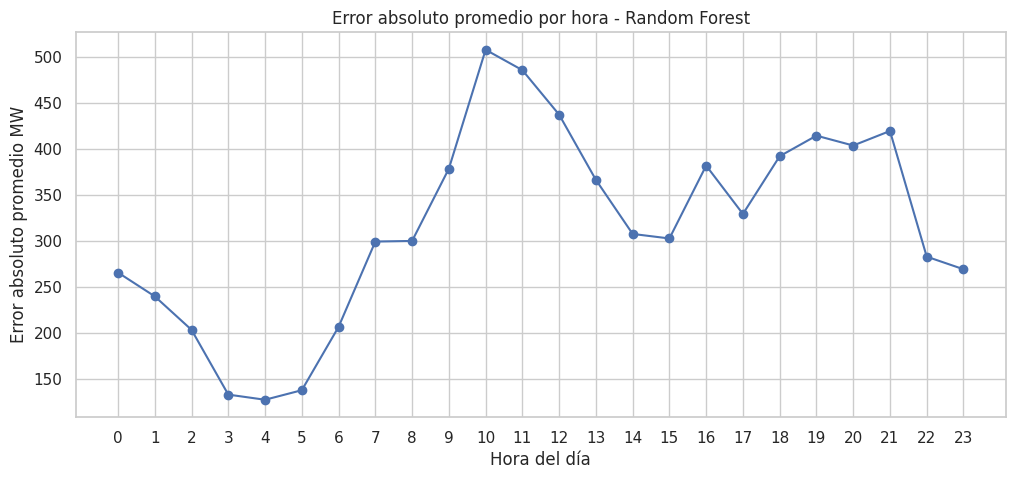

In [49]:
# ============================================================
# 47. ERROR PROMEDIO POR HORA DEL DÍA
# ============================================================

error_by_hour = error_df.groupby('hour')['abs_error'].mean()

plt.figure(figsize=(12, 5))
plt.plot(error_by_hour.index, error_by_hour.values, marker='o')
plt.title(f'Error absoluto promedio por hora - {best_model_name}')
plt.xlabel('Hora del día')
plt.ylabel('Error absoluto promedio MW')
plt.xticks(range(24))
plt.grid(True)
plt.show()

El análisis de errores del mejor modelo inicial, correspondiente a `Random Forest`, permite profundizar más allá de las métricas globales.

En las primeras filas del dataframe de errores se observa que las predicciones se encuentran muy cercanas a los valores reales. Por ejemplo, en las primeras horas del conjunto de prueba los errores porcentuales se mantienen bajo 1%, lo que es consistente con el MAPE global de 0.99% obtenido por el modelo.

La distribución de errores muestra una forma concentrada alrededor de cero. Esto indica que el modelo no presenta un sesgo evidente de sobreestimación o subestimación sistemática. En otras palabras, los errores positivos y negativos parecen distribuirse de forma relativamente balanceada en torno al valor real.

Sin embargo, la distribución también muestra colas hacia ambos extremos, con errores que pueden superar ampliamente los 1.000 MW en ciertos casos puntuales. Esto sugiere que, aunque el modelo tiene muy buen desempeño promedio, todavía existen momentos específicos donde la predicción se aleja de la demanda real.

El análisis del error absoluto promedio por hora del día muestra una variación importante según la hora. Los errores más bajos se concentran durante la madrugada, especialmente entre las 3:00 y las 5:00 horas, donde la demanda suele ser más estable y predecible.

En cambio, los errores aumentan durante las horas de mayor actividad, especialmente alrededor de las 10:00 a 13:00 horas y nuevamente entre las 18:00 y 21:00 horas. Estas franjas coinciden con períodos donde la demanda puede cambiar más rápido debido al inicio de actividades productivas, comerciales, residenciales o cambios de temperatura y climatización.

Este patrón confirma que el modelo predice mejor cuando la demanda evoluciona de forma estable, pero presenta mayor dificultad en horarios donde ocurren transiciones, rampas de consumo o posibles peaks.

El comportamiento del error por hora es coherente con la naturaleza de la demanda eléctrica horaria.

Durante la madrugada, el sistema suele estar en un régimen de menor variabilidad, con menor actividad económica y patrones de consumo más estables. Esto facilita que un modelo basado en rezagos recientes, especialmente `lag_1`, prediga con alta precisión.

Durante la mañana y la tarde-noche, la demanda entra en períodos de transición. En estos horarios, pequeños cambios en actividad económica, temperatura, uso de climatización, comportamiento residencial o dinámica industrial pueden generar diferencias más relevantes entre la predicción y el valor real.

El hecho de que el error aumente en ciertas horas sugiere que el modelo podría beneficiarse de variables exógenas adicionales, tales como:

- temperatura,
- humedad,
- calendario laboral,
- feriados,
- tipo de día,
- precios horarios,
- eventos extremos,
- variables de actividad económica o industrial.

Además, la alta dependencia de `lag_1` observada en la importancia de variables explica parte del buen desempeño del modelo, pero también revela una limitación: el modelo es muy fuerte para predicción de corto plazo, pero podría ser menos robusto cuando se requiere anticipar cambios de régimen con mayor margen temporal.

Desde una perspectiva de negocio energético, este análisis de errores es especialmente útil porque muestra que el modelo no falla de manera uniforme durante el día.

El modelo tiene mejor desempeño en horarios de menor variabilidad, pero sus errores aumentan en franjas horarias críticas para la operación del sistema eléctrico.

Esto es relevante porque las horas donde el error aumenta suelen ser justamente aquellas donde la predicción puede tener mayor valor operativo: inicio de jornada, rampas de consumo, horarios de alta actividad y posibles eventos de peak demand.

Por lo tanto, una aplicación real basada en este modelo no debería limitarse a mostrar un forecast general. También debería incluir indicadores de riesgo horario, señalando en qué momentos del día la predicción es históricamente menos precisa.

Una posible evolución del producto sería incorporar un módulo de `confianza del forecast`, donde el sistema no solo entregue la predicción de demanda, sino también un nivel de incertidumbre o riesgo asociado por hora.

El análisis de errores confirma que `Random Forest` es un modelo sólido dentro del esquema actual de evaluación, con errores promedio bajos y una distribución centrada en torno a cero.

No obstante, el error por hora demuestra que aún existen franjas temporales donde el modelo tiene mayor dificultad predictiva. Estas franjas coinciden con momentos de transición o mayor actividad, lo que abre una línea clara de mejora mediante variables exógenas y modelos más avanzados.

Con esta etapa se cierra el análisis del mejor modelo inicial en términos de métricas globales y comportamiento horario del error.

El siguiente paso será evaluar si el desempeño se mantiene estable a lo largo de la semana y, posteriormente, avanzar hacia escenarios más realistas de forecast con mayor margen de anticipación, como predicciones a 24, 48 y 168 horas.

## Marco metodológico: de predicción supervisada a forecast operativo

Los modelos evaluados inicialmente permiten medir capacidad predictiva bajo un escenario supervisado, donde las variables de rezago ya están disponibles en el conjunto de prueba.

Este enfoque es útil para comparar modelos bajo las mismas reglas, pero tiene una limitación: en una aplicación real, cuando se desea predecir varios días hacia adelante, los valores futuros intermedios no se conocen.

Por esta razón, el proyecto debe avanzar hacia un enfoque de forecast multi-step, donde el modelo genera predicciones encadenadas para simular un escenario más realista.

Este cambio es relevante porque una herramienta de negocio no solo debe predecir la próxima hora, sino entregar margen de anticipación suficiente para planificar operación, gestionar costos o activar alertas.

## 28. Evaluación del desempeño por día de la semana

Después de comparar los modelos con métricas globales, es necesario analizar si el desempeño se mantiene estable a lo largo de la semana.

En series de demanda eléctrica, el comportamiento puede variar entre días laborales y fines de semana debido a cambios en actividad residencial, comercial e industrial.

Por esta razón, se evaluará el error de cada modelo agrupando los resultados por día de la semana. Esto permite identificar si existen días donde el modelo predice mejor o peor, y si el desempeño global es consistente o está concentrado en ciertos períodos.

In [50]:
# ============================================================
# 48. DATAFRAME COMPARATIVO DE PREDICCIONES POR MODELO
# ============================================================

comparison_df = pd.DataFrame({
    'y_true': y_test,
    'Baseline_Naive': y_pred_naive,
    'Linear_Regression': pd.Series(y_pred_lr, index=y_test.index),
    'Random_Forest': pd.Series(y_pred_rf, index=y_test.index)
})

comparison_df['hour'] = comparison_df.index.hour
comparison_df['dayofweek'] = comparison_df.index.dayofweek
comparison_df['week'] = comparison_df.index.to_period('W').astype(str)

day_names = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}

comparison_df['day_name'] = comparison_df['dayofweek'].map(day_names)

comparison_df.head()

,y_true,Baseline_Naive,Linear_Regression,Random_Forest,hour,dayofweek,week,day_name
Datetime,,,,,,,,
2017-08-03 00:00:00,"31,646.00","35,126.00","32,798.05","31,440.57",0,3,2017-07-31/2017-08-06,Jueves
2017-08-03 01:00:00,"29,189.00","32,263.00","30,227.89","28,962.13",1,3,2017-07-31/2017-08-06,Jueves
2017-08-03 02:00:00,"27,584.00","30,266.00","28,224.83","27,345.10",2,3,2017-07-31/2017-08-06,Jueves
2017-08-03 03:00:00,"26,544.00","28,966.00","27,062.38","26,471.58",3,3,2017-07-31/2017-08-06,Jueves
2017-08-03 04:00:00,"26,012.00","28,243.00","26,469.37","25,937.69",4,3,2017-07-31/2017-08-06,Jueves


In [51]:
# ============================================================
# 49. FUNCIÓN DE MÉTRICAS POR GRUPO TEMPORAL
# ============================================================

def metrics_by_group(df_eval, prediction_col, group_col):
    """
    Calcula MAE, RMSE y MAPE agrupados por una variable temporal.
    """
    results = []

    for group_value, group_data in df_eval.groupby(group_col):
        y_true_group = group_data['y_true']
        y_pred_group = group_data[prediction_col]

        mae = mean_absolute_error(y_true_group, y_pred_group)
        rmse = np.sqrt(mean_squared_error(y_true_group, y_pred_group))
        mape = mean_absolute_percentage_error(y_true_group, y_pred_group) * 100

        results.append({
            group_col: group_value,
            'model': prediction_col,
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'MAPE_%': round(mape, 2)
        })

    return pd.DataFrame(results)

In [52]:
# ============================================================
# 50. MÉTRICAS POR DÍA DE LA SEMANA PARA LOS TRES MODELOS
# ============================================================

models_cols = ['Baseline_Naive', 'Linear_Regression', 'Random_Forest']

weekly_metrics = []

for model_col in models_cols:
    temp_metrics = metrics_by_group(
        df_eval=comparison_df,
        prediction_col=model_col,
        group_col='day_name'
    )
    weekly_metrics.append(temp_metrics)

weekly_metrics_df = pd.concat(weekly_metrics, ignore_index=True)

day_order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

weekly_metrics_df['day_name'] = pd.Categorical(
    weekly_metrics_df['day_name'],
    categories=day_order,
    ordered=True
)

weekly_metrics_df = weekly_metrics_df.sort_values(['model', 'day_name'])

weekly_metrics_df

,day_name,model,MAE,RMSE,MAPE_%
2,Lunes,Baseline_Naive,"3,198.13","4,008.88",9.88
3,Martes,Baseline_Naive,"2,016.15","2,926.71",5.94
4,Miércoles,Baseline_Naive,"2,119.94","2,916.96",6.31
1,Jueves,Baseline_Naive,"2,021.62","2,668.87",6.18
6,Viernes,Baseline_Naive,"1,802.33","2,467.36",5.65
5,Sábado,Baseline_Naive,"2,879.81","3,747.00",10.02
0,Domingo,Baseline_Naive,"2,116.46","2,991.63",7.29
9,Lunes,Linear_Regression,852.57,"1,082.61",2.66
10,Martes,Linear_Regression,863.95,"1,110.10",2.65
11,Miércoles,Linear_Regression,807.61,"1,032.28",2.48


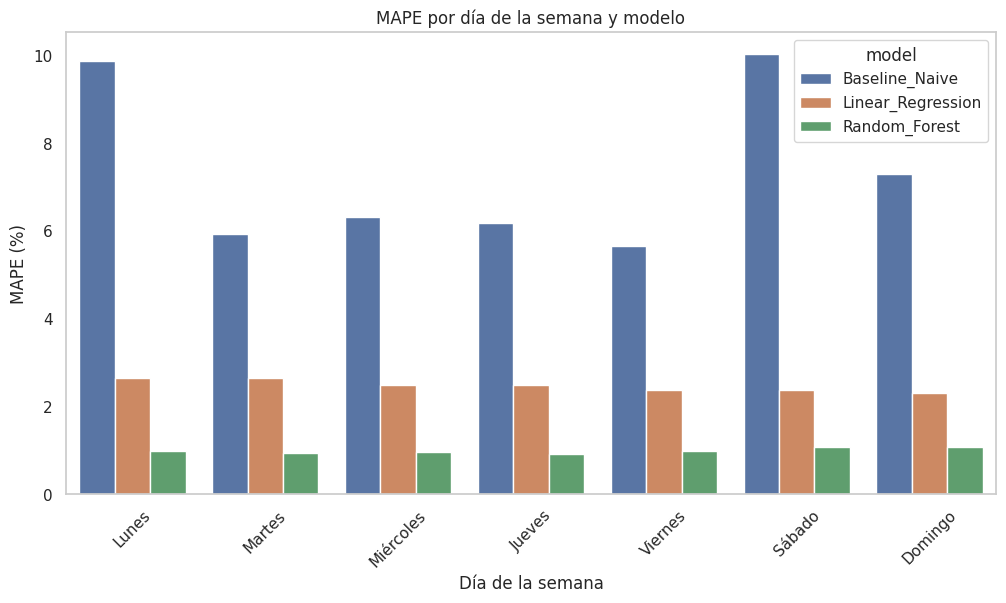

In [53]:
# ============================================================
# 51. COMPARACIÓN DE MAPE POR DÍA DE LA SEMANA
# ============================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    data=weekly_metrics_df,
    x='day_name',
    y='MAPE_%',
    hue='model'
)

plt.title('MAPE por día de la semana y modelo')
plt.xlabel('Día de la semana')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

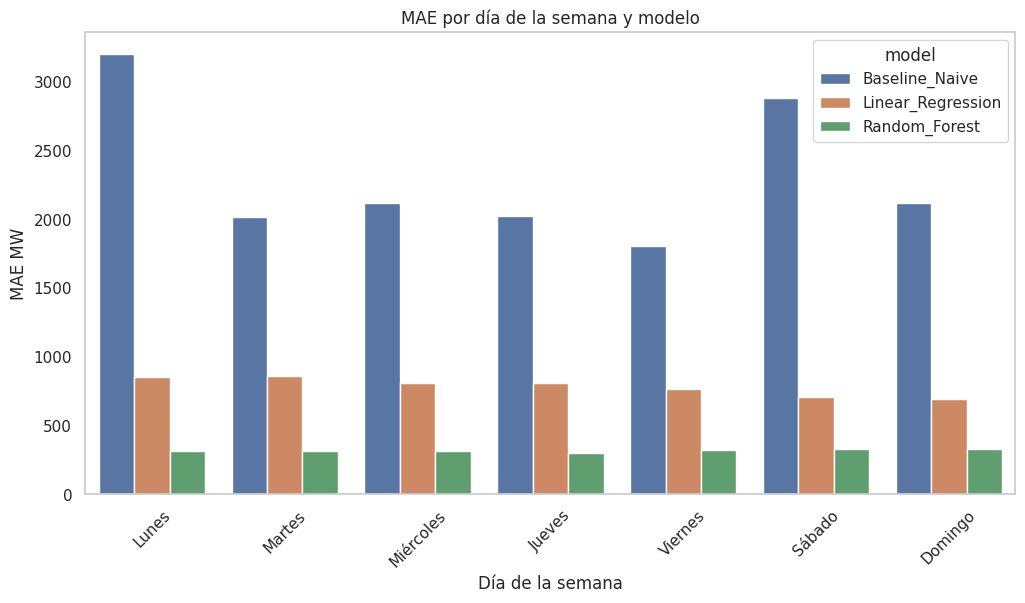

In [54]:
# ============================================================
# 52. COMPARACIÓN DE MAE POR DÍA DE LA SEMANA
# ============================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    data=weekly_metrics_df,
    x='day_name',
    y='MAE',
    hue='model'
)

plt.title('MAE por día de la semana y modelo')
plt.xlabel('Día de la semana')
plt.ylabel('MAE MW')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [55]:
# ============================================================
# 53. DESEMPEÑO SEMANAL DEL MEJOR MODELO INICIAL
# ============================================================

weekly_rf_metrics = metrics_by_group(
    df_eval=comparison_df,
    prediction_col='Random_Forest',
    group_col='week'
)

weekly_rf_metrics = weekly_rf_metrics.sort_values('week')

weekly_rf_metrics.head()

,week,model,MAE,RMSE,MAPE_%
0,2017-07-31/2017-08-06,Random_Forest,351.91,493.33,1.02
1,2017-08-07/2017-08-13,Random_Forest,271.65,353.94,0.83
2,2017-08-14/2017-08-20,Random_Forest,307.88,383.76,0.85
3,2017-08-21/2017-08-27,Random_Forest,291.55,405.82,0.85
4,2017-08-28/2017-09-03,Random_Forest,257.49,355.42,0.90


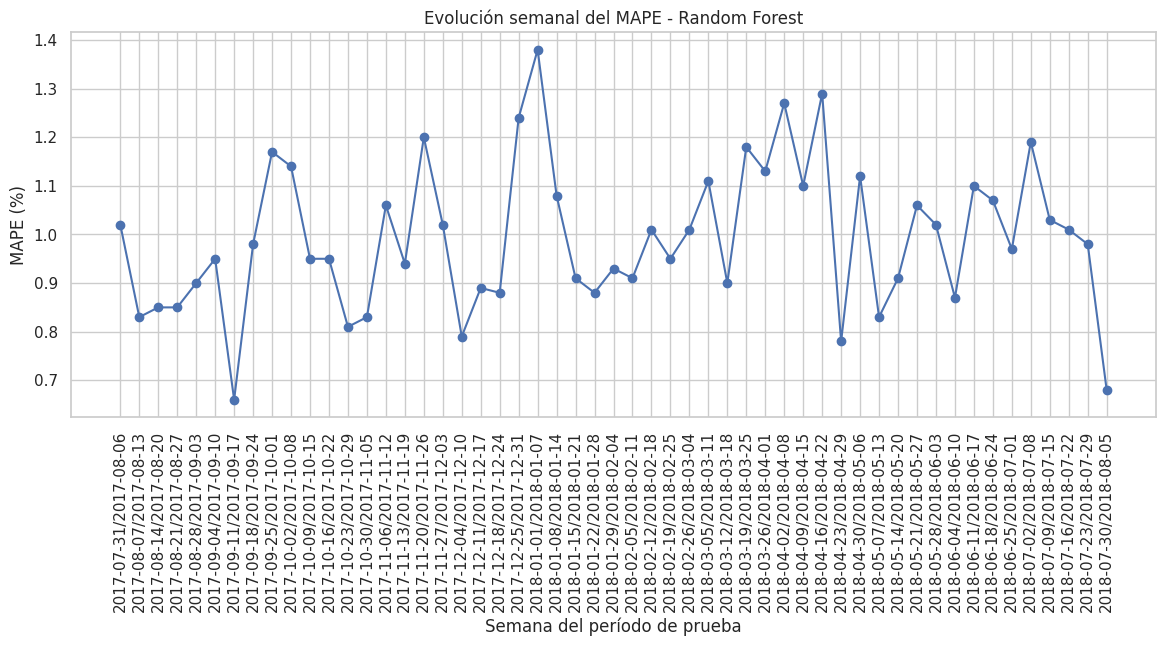

In [56]:
# ============================================================
# 54. EVOLUCIÓN SEMANAL DEL MAPE - RANDOM FOREST
# ============================================================

plt.figure(figsize=(14, 5))
plt.plot(
    weekly_rf_metrics['week'],
    weekly_rf_metrics['MAPE_%'],
    marker='o'
)

plt.title('Evolución semanal del MAPE - Random Forest')
plt.xlabel('Semana del período de prueba')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

El análisis por día de la semana permite evaluar si los modelos mantienen un desempeño estable entre días laborales y fines de semana.

A partir de los resultados obtenidos, se observa que los tres modelos presentan comportamientos distintos:

### Baseline Naive

El modelo `Baseline_Naive` presenta el desempeño más débil y más irregular durante la semana.

Sus errores porcentuales se mueven aproximadamente entre 5,65% y 10,02% de MAPE. Los días con peor desempeño son:

- Sábado: MAPE de 10,02%.
- Lunes: MAPE de 9,88%.
- Domingo: MAPE de 7,29%.

Esto indica que la regla de usar el consumo del mismo horario del día anterior no es suficientemente robusta para capturar cambios entre días laborales y fines de semana. El baseline funciona como referencia inicial, pero muestra debilidades importantes cuando cambia la dinámica semanal.

### Regresión Lineal

La `Linear_Regression` mejora claramente respecto del baseline y presenta un comportamiento mucho más estable durante la semana.

Sus valores de MAPE se ubican aproximadamente entre 2,32% y 2,66%, mostrando baja variabilidad entre días. Esto indica que las variables temporales, cíclicas, rezagos y promedios móviles permiten capturar mejor los patrones semanales de la demanda eléctrica.

Los mejores días para la regresión lineal son:

- Domingo: MAPE de 2,32%.
- Viernes: MAPE de 2,37%.
- Sábado: MAPE de 2,38%.

### Random Forest

El modelo `Random_Forest` mantiene el mejor desempeño en todos los días de la semana.

Sus valores de MAPE se mantienen aproximadamente entre 0,91% y 1,09%, lo que evidencia una alta estabilidad predictiva en días laborales y fines de semana.

Los mejores días para Random Forest son:

- Jueves: MAPE de 0,91%.
- Martes: MAPE de 0,95%.
- Miércoles: MAPE de 0,96%.

Los días con mayor error relativo son:

- Domingo: MAPE de 1,09%.
- Sábado: MAPE de 1,08%.

Aunque el error aumenta levemente durante el fin de semana, sigue siendo bajo en comparación con los otros modelos.

### Conclusión semanal

La comparación por día de la semana confirma que `Random_Forest` no solo es el mejor modelo en métricas globales, sino que también mantiene un desempeño consistente durante la semana.

Esto es importante porque una métrica global podría ocultar errores concentrados en ciertos días. En este caso, el análisis muestra que Random Forest conserva un MAPE cercano al 1% tanto en días laborales como en fines de semana.

Por lo tanto, bajo el esquema actual de evaluación supervisada con rezagos observados, Random Forest es el mejor modelo candidato para continuar hacia una evaluación más exigente de forecast multi-step.

| Día | Baseline MAPE | Linear Regression MAPE | Random Forest MAPE |
|---|---:|---:|---:|
| Lunes | 9,88% | 2,66% | 0,99% |
| Martes | 5,94% | 2,65% | 0,95% |
| Miércoles | 6,31% | 2,48% | 0,96% |
| Jueves | 6,18% | 2,48% | 0,91% |
| Viernes | 5,65% | 2,37% | 0,98% |
| Sábado | 10,02% | 2,38% | 1,08% |
| Domingo | 7,29% | 2,32% | 1,09% |

Al revisar la evolución semanal del MAPE del modelo Random Forest, se observa que el desempeño se mantiene estable a lo largo del período de prueba.

El MAPE semanal se mueve mayoritariamente en un rango cercano a 0,8% - 1,2%, con algunos peaks puntuales que se aproximan a 1,3% - 1,4%. Aun en esas semanas de mayor error relativo, el desempeño sigue siendo bajo en comparación con los modelos baseline y regresión lineal.

Esto indica que Random Forest no está funcionando bien solo en días aislados, sino que mantiene una capacidad predictiva consistente a través de múltiples semanas del conjunto de prueba.

También se observa que el error no presenta una tendencia creciente sostenida durante el tiempo. Esto es relevante, porque si el MAPE aumentara progresivamente semana a semana, podría indicar pérdida de estabilidad del modelo o cambios estructurales no capturados por las variables utilizadas.

En este caso, el comportamiento semanal del error parece fluctuar dentro de un rango controlado, lo que refuerza la estabilidad del modelo bajo el esquema actual de evaluación supervisada.

Sin embargo, existen semanas puntuales con mayor error. Estas semanas deben ser revisadas en una etapa posterior para identificar si coinciden con eventos particulares, cambios bruscos de demanda, feriados, condiciones climáticas extremas o patrones atípicos del sistema eléctrico.

Desde una mirada técnica, este resultado valida a Random Forest como el mejor modelo inicial para avanzar hacia una evaluación más exigente de forecast multi-step.

El análisis semanal confirma que Random Forest mantiene un desempeño sólido y estable durante el período de prueba.

La mayoría de las semanas presentan errores porcentuales cercanos al 1%, lo que sugiere que el modelo logra sostener su capacidad predictiva en el tiempo y no depende únicamente de un buen desempeño puntual en algunos días.

Para una audiencia no técnica, esto puede explicarse de la siguiente forma:

> El modelo no solo predice bien en promedio; también mantiene un comportamiento estable semana a semana.

Esta estabilidad es importante para una posible aplicación de negocio, porque una herramienta de planificación o monitoreo energético necesita ser confiable de forma continua, no solo en momentos aislados.

Aun así, esta evaluación todavía utiliza rezagos observados. Por lo tanto, el siguiente paso será probar si el modelo mantiene esta estabilidad cuando debe proyectar varias horas o días hacia adelante sin conocer los consumos futuros intermedios.

Las semanas con mayor MAPE deberían revisarse con mayor detalle en una fase posterior.

Preguntas sugeridas:

1. ¿Coinciden las semanas de mayor error con peaks de demanda?
2. ¿Ocurren en meses de mayor estacionalidad, como verano o invierno?
3. ¿Existen feriados o eventos especiales en esas semanas?
4. ¿El error aumenta durante fines de semana o días laborales específicos?
5. ¿El modelo subestima o sobreestima en esas semanas?
6. ¿La incorporación de temperatura o calendario laboral reduciría esos errores?

Estas preguntas permiten transformar el análisis de error en una línea de mejora del modelo y en una posible fuente de valor para aplicaciones reales.

La evaluación por día de la semana y por semana confirma que Random Forest es el modelo más robusto dentro del esquema actual.

El modelo muestra:

- Mejor desempeño global.
- Mejor desempeño por día de la semana.
- Estabilidad semanal del MAPE.
- Error relativo bajo y controlado.

Por lo tanto, Random Forest queda seleccionado como modelo base para la siguiente fase del proyecto: evaluación de forecast con mayor margen de anticipación.

La siguiente etapa será pasar desde una evaluación supervisada con rezagos observados hacia un enfoque de forecast multi-step, con horizontes de 24, 48 y 168 horas.

Desde una perspectiva de negocio, el análisis semanal confirma que Random Forest es el modelo más confiable de los tres evaluados hasta esta etapa.

El baseline naive puede ser útil como regla simple, pero muestra debilidades claras en lunes y sábado. La regresión lineal mejora considerablemente el desempeño, pero Random Forest entrega el menor error y la mayor estabilidad.

Esto significa que, si se quisiera construir una primera herramienta de monitoreo o alerta de corto plazo, Random Forest sería el mejor candidato inicial.

Sin embargo, esta conclusión todavía corresponde a una evaluación con rezagos observados. Para una aplicación real con mayor margen de anticipación, el siguiente paso será construir una evaluación multi-step de 24, 48 y 168 horas.

Esta evaluación semanal compara el desempeño de los modelos sobre el conjunto de test utilizando rezagos observados.

Por lo tanto, sirve para analizar estabilidad del error por día de la semana y por semana histórica, pero todavía no representa un forecast semanal real hacia adelante.

Para evaluar una predicción semanal con mayor margen de anticipación, será necesario construir un escenario multi-step, donde el modelo prediga 24, 48 o 168 horas hacia adelante sin utilizar valores reales intermedios del futuro.

## 29. Forecast multi-step: evaluación con mayor margen de anticipación

Hasta ahora, los modelos fueron evaluados bajo un esquema supervisado tradicional, donde los rezagos utilizados como variables predictoras ya estaban disponibles en el conjunto de prueba.

Ese enfoque permite comparar modelos de forma justa, pero no representa completamente un escenario operativo real. En la práctica, cuando se desea predecir 24, 48 o 168 horas hacia adelante, los valores futuros intermedios no se conocen.

Por esta razón, en esta sección se implementa una evaluación multi-step recursiva. El modelo predice la siguiente hora y luego utiliza esa predicción como parte del historial para predecir la hora posterior. Este proceso se repite hasta completar el horizonte definido.

Esta evaluación permite medir si el modelo sigue siendo útil cuando debe anticipar la demanda con mayor margen de tiempo.

En esta primera evaluación multi-step se utilizará el enfoque recursivo con el modelo Random Forest, ya que fue el mejor modelo en la comparación global, diaria y semanal.

El objetivo no es todavía construir el modelo final de producción, sino medir cuánto se deteriora el desempeño cuando el modelo debe proyectar varios pasos hacia adelante utilizando sus propias predicciones previas.

In [57]:
# ============================================================
# 55. FUNCIÓN PARA CONSTRUIR FEATURES FUTURAS EN FORECAST RECURSIVO
# ============================================================

def build_future_features(timestamp, history_series):
    """
    Construye las variables predictoras para un timestamp futuro usando:
    - variables temporales del calendario
    - rezagos calculados desde history_series
    - promedios móviles calculados desde history_series

    history_series debe contener valores reales pasados y, durante el forecast,
    también predicciones generadas recursivamente.
    """

    feature_row = {}

    # Variables temporales básicas
    feature_row['hour'] = timestamp.hour
    feature_row['dayofweek'] = timestamp.dayofweek
    feature_row['dayofmonth'] = timestamp.day
    feature_row['dayofyear'] = timestamp.dayofyear
    feature_row['weekofyear'] = int(timestamp.isocalendar().week)
    feature_row['month'] = timestamp.month
    feature_row['quarter'] = timestamp.quarter
    feature_row['year'] = timestamp.year

    # Variables cíclicas
    feature_row['hour_sin'] = np.sin(2 * np.pi * feature_row['hour'] / 24)
    feature_row['hour_cos'] = np.cos(2 * np.pi * feature_row['hour'] / 24)
    feature_row['month_sin'] = np.sin(2 * np.pi * feature_row['month'] / 12)
    feature_row['month_cos'] = np.cos(2 * np.pi * feature_row['month'] / 12)
    feature_row['dayofweek_sin'] = np.sin(2 * np.pi * feature_row['dayofweek'] / 7)
    feature_row['dayofweek_cos'] = np.cos(2 * np.pi * feature_row['dayofweek'] / 7)

    # Rezagos
    feature_row['lag_1'] = history_series.loc[timestamp - pd.Timedelta(hours=1)]
    feature_row['lag_24'] = history_series.loc[timestamp - pd.Timedelta(hours=24)]
    feature_row['lag_168'] = history_series.loc[timestamp - pd.Timedelta(hours=168)]

    # Rolling windows usando solo pasado disponible
    feature_row['rolling_24'] = history_series.loc[:timestamp - pd.Timedelta(hours=1)].tail(24).mean()
    feature_row['rolling_168'] = history_series.loc[:timestamp - pd.Timedelta(hours=1)].tail(168).mean()

    # Mantener el mismo orden de columnas usado en entrenamiento
    return pd.DataFrame([feature_row])[features]

In [58]:
# ============================================================
# 56. FUNCIÓN DE FORECAST RECURSIVO MULTI-STEP
# ============================================================

def recursive_forecast(model, history_series, start_timestamp, horizon_hours):
    """
    Genera un forecast recursivo para un horizonte dado.

    Parámetros:
    - model: modelo entrenado.
    - history_series: serie histórica con valores reales disponibles hasta antes del forecast.
    - start_timestamp: primera fecha/hora a predecir.
    - horizon_hours: cantidad de horas a proyectar.

    Retorna:
    - Serie con predicciones horarias.
    """

    history_extended = history_series.copy()
    predictions = []
    prediction_index = []

    future_timestamps = pd.date_range(
        start=start_timestamp,
        periods=horizon_hours,
        freq='h'
    )

    for ts in future_timestamps:
        X_future = build_future_features(ts, history_extended)
        yhat = model.predict(X_future)[0]

        predictions.append(yhat)
        prediction_index.append(ts)

        # Agregar la predicción al historial para los siguientes pasos
        history_extended.loc[ts] = yhat

    return pd.Series(predictions, index=prediction_index, name='y_pred')

In [59]:
# ============================================================
# 57. PRUEBA DE FORECAST RECURSIVO PARA UNA SEMANA
# ============================================================

# Seleccionamos como punto de inicio la primera fecha del conjunto de test.
forecast_start = test.index.min()
horizon_hours = 168

# Historial real disponible antes del inicio del forecast.
history_available = df.loc[df.index < forecast_start, 'PJME_MW'].copy()

rf_recursive_pred_168 = recursive_forecast(
    model=rf_model,
    history_series=history_available,
    start_timestamp=forecast_start,
    horizon_hours=horizon_hours
)

# Valores reales correspondientes al mismo horizonte.
y_true_168 = df.loc[rf_recursive_pred_168.index, 'PJME_MW']

# Evaluación del forecast semanal recursivo.
rf_recursive_168_results = evaluate_forecast(
    y_true=y_true_168,
    y_pred=rf_recursive_pred_168,
    model_name='Random Forest Recursive 168h'
)

rf_recursive_168_results

{'model': 'Random Forest Recursive 168h',
 'MAE': 2515.31,
 'RMSE': np.float64(3000.23),
 'MAPE_%': 7.44}

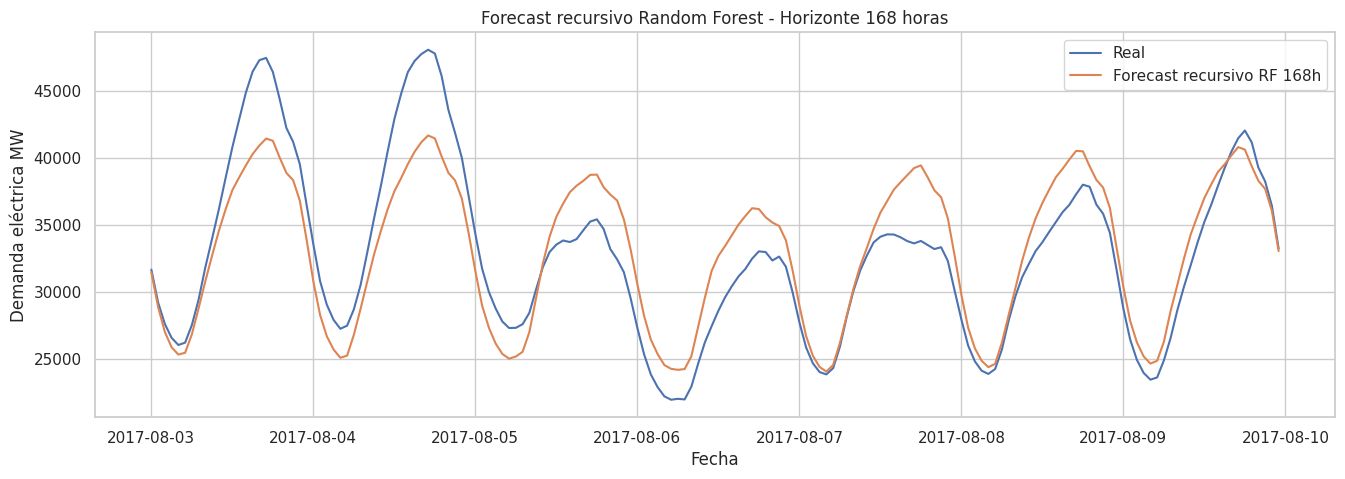

In [60]:
# ============================================================
# 58. VISUALIZACIÓN DEL FORECAST RECURSIVO DE 168 HORAS
# ============================================================

plt.figure(figsize=(16, 5))
plt.plot(y_true_168.index, y_true_168, label='Real')
plt.plot(rf_recursive_pred_168.index, rf_recursive_pred_168, label='Forecast recursivo RF 168h')

plt.title('Forecast recursivo Random Forest - Horizonte 168 horas')
plt.xlabel('Fecha')
plt.ylabel('Demanda eléctrica MW')
plt.legend()
plt.grid(True)
plt.show()

In [61]:
# ============================================================
# 59. EVALUACIÓN MULTI-STEP PARA HORIZONTES 24, 48 Y 168 HORAS
# ============================================================

horizons = [24, 48, 168]
recursive_results = []
recursive_predictions = {}

forecast_start = test.index.min()
history_available = df.loc[df.index < forecast_start, 'PJME_MW'].copy()

for h in horizons:
    y_pred_h = recursive_forecast(
        model=rf_model,
        history_series=history_available,
        start_timestamp=forecast_start,
        horizon_hours=h
    )

    y_true_h = df.loc[y_pred_h.index, 'PJME_MW']

    result_h = evaluate_forecast(
        y_true=y_true_h,
        y_pred=y_pred_h,
        model_name=f'Random Forest Recursive {h}h'
    )

    result_h['horizon_hours'] = h
    recursive_results.append(result_h)
    recursive_predictions[h] = {
        'y_true': y_true_h,
        'y_pred': y_pred_h
    }

recursive_results_df = pd.DataFrame(recursive_results)
recursive_results_df

,model,MAE,RMSE,MAPE_%,horizon_hours
0,Random Forest Recursive 24h,"2,649.79","3,336.06",6.42,24
1,Random Forest Recursive 48h,"3,312.60","3,888.59",8.18,48
2,Random Forest Recursive 168h,"2,515.31","3,000.23",7.44,168


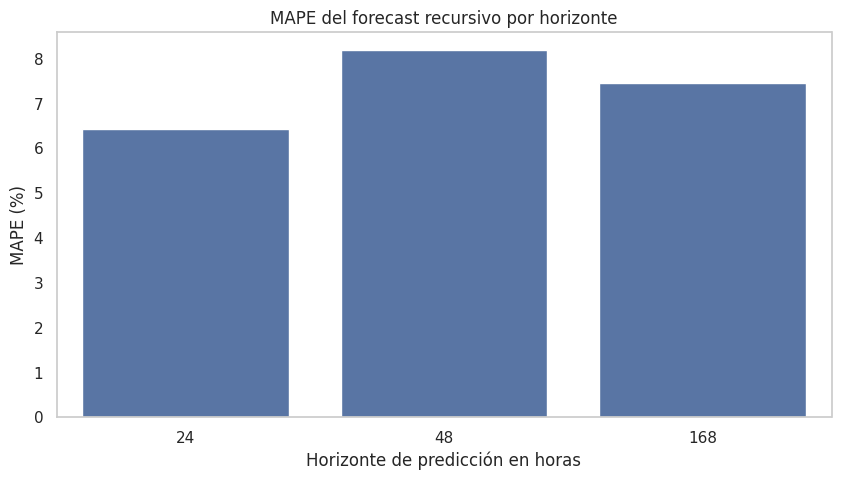

In [62]:
# ============================================================
# 60. COMPARACIÓN DEL MAPE POR HORIZONTE MULTI-STEP
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(
    data=recursive_results_df,
    x='horizon_hours',
    y='MAPE_%'
)

plt.title('MAPE del forecast recursivo por horizonte')
plt.xlabel('Horizonte de predicción en horas')
plt.ylabel('MAPE (%)')
plt.grid(axis='y')
plt.show()

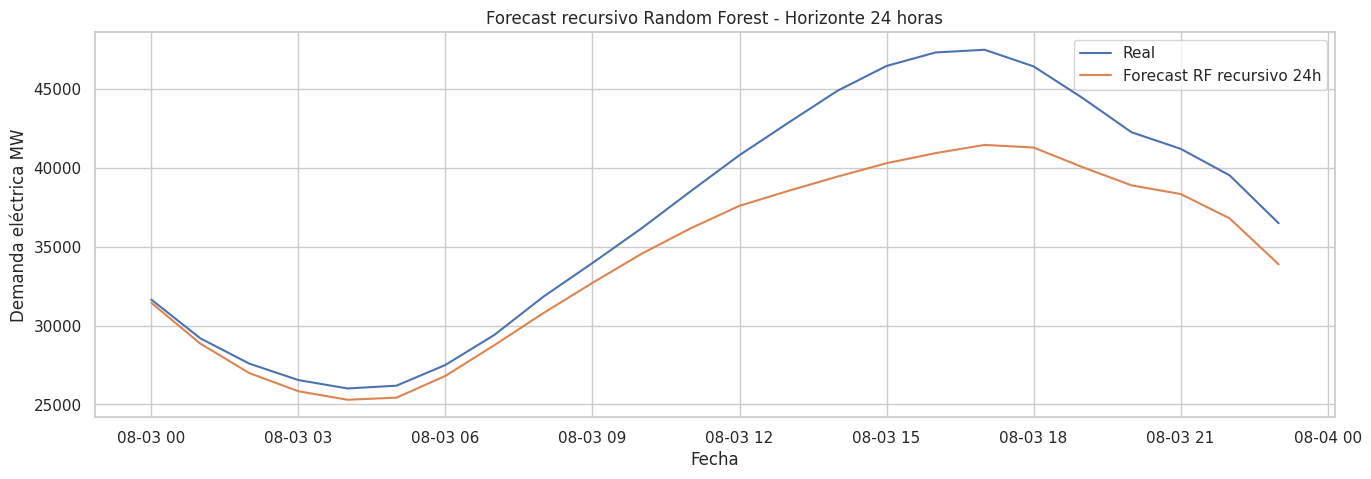

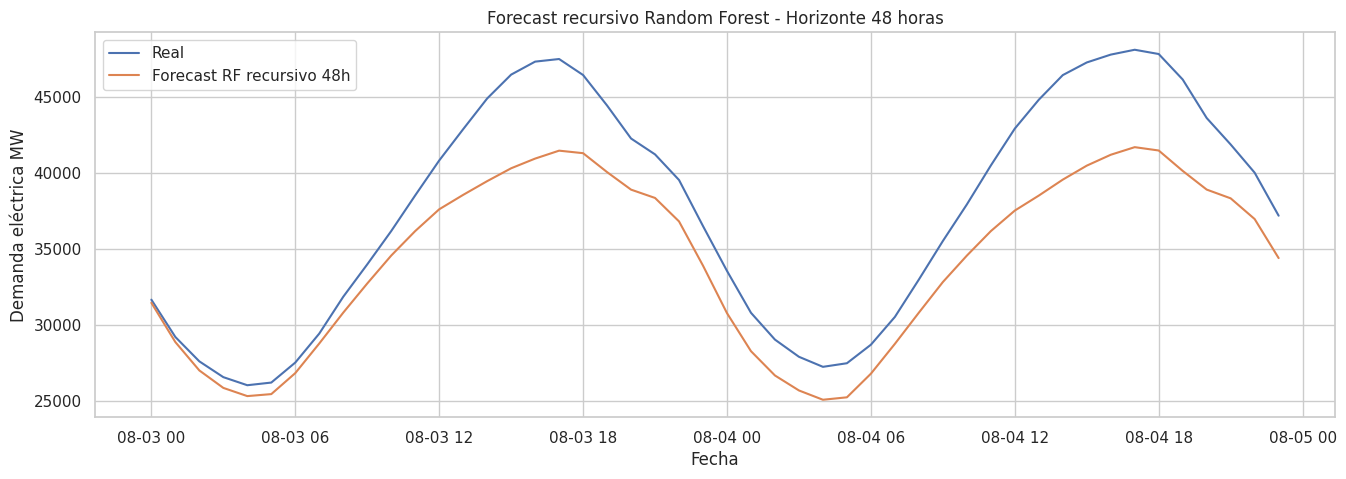

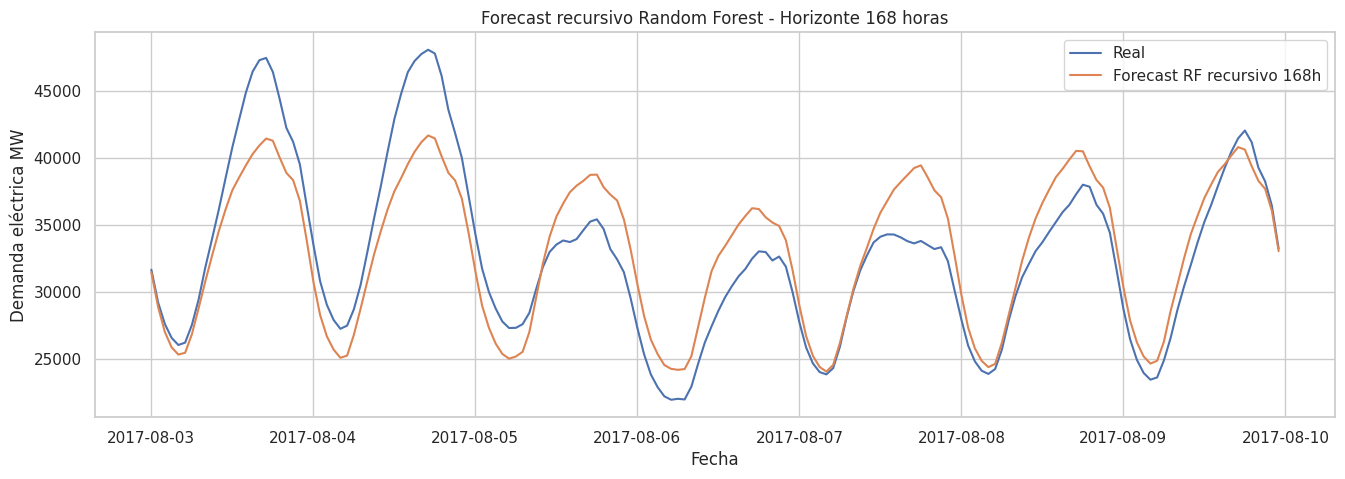

In [63]:
# ============================================================
# 61. VISUALIZACIÓN REAL VS FORECAST POR HORIZONTE
# ============================================================

for h in horizons:
    y_true_h = recursive_predictions[h]['y_true']
    y_pred_h = recursive_predictions[h]['y_pred']

    plt.figure(figsize=(16, 5))
    plt.plot(y_true_h.index, y_true_h, label='Real')
    plt.plot(y_pred_h.index, y_pred_h, label=f'Forecast RF recursivo {h}h')

    plt.title(f'Forecast recursivo Random Forest - Horizonte {h} horas')
    plt.xlabel('Fecha')
    plt.ylabel('Demanda eléctrica MW')
    plt.legend()
    plt.grid(True)
    plt.show()

In [64]:
# ============================================================
# 62. EVALUACIÓN RECURSIVA CON MÚLTIPLES PUNTOS DE INICIO
# ============================================================

# Para una evaluación más robusta, se prueban varios puntos de inicio dentro del test.
# Se usa un salto semanal para no sobrecargar el cómputo.

multi_origin_results = []

horizons = [24, 48, 168]
forecast_origins = pd.date_range(
    start=test.index.min(),
    end=test.index.max() - pd.Timedelta(hours=max(horizons)),
    freq='168h'
)

for origin in forecast_origins:
    history_available = df.loc[df.index < origin, 'PJME_MW'].copy()

    for h in horizons:
        y_pred_h = recursive_forecast(
            model=rf_model,
            history_series=history_available,
            start_timestamp=origin,
            horizon_hours=h
        )

        y_true_h = df.loc[y_pred_h.index, 'PJME_MW']

        result_h = evaluate_forecast(
            y_true=y_true_h,
            y_pred=y_pred_h,
            model_name=f'RF Recursive {h}h'
        )

        result_h['origin'] = origin
        result_h['horizon_hours'] = h
        multi_origin_results.append(result_h)

multi_origin_results_df = pd.DataFrame(multi_origin_results)

multi_origin_results_df.head()

,model,MAE,RMSE,MAPE_%,origin,horizon_hours
0,RF Recursive 24h,"2,649.79","3,336.06",6.42,2017-08-03,24
1,RF Recursive 48h,"3,312.60","3,888.59",8.18,2017-08-03,48
2,RF Recursive 168h,"2,515.31","3,000.23",7.44,2017-08-03,168
3,RF Recursive 24h,563.77,651.35,1.74,2017-08-10,24
4,RF Recursive 48h,543.77,657.64,1.61,2017-08-10,48


In [65]:
# ============================================================
# 63. RESUMEN DE DESEMPEÑO MULTI-ORIGIN POR HORIZONTE
# ============================================================

multi_origin_summary = (
    multi_origin_results_df
    .groupby('horizon_hours')
    .agg(
        MAE_mean=('MAE', 'mean'),
        MAE_std=('MAE', 'std'),
        RMSE_mean=('RMSE', 'mean'),
        RMSE_std=('RMSE', 'std'),
        MAPE_mean=('MAPE_%', 'mean'),
        MAPE_std=('MAPE_%', 'std'),
        n_origins=('origin', 'count')
    )
    .reset_index()
)

# Redondeo para presentación
cols_to_round = ['MAE_mean', 'MAE_std', 'RMSE_mean', 'RMSE_std', 'MAPE_mean', 'MAPE_std']
multi_origin_summary[cols_to_round] = multi_origin_summary[cols_to_round].round(2)

multi_origin_summary

,horizon_hours,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPE_mean,MAPE_std,n_origins
0,24,"1,472.60",977.20,"1,803.52","1,209.23",4.34,2.61,52
1,48,"1,971.21","1,361.81","2,383.05","1,604.51",5.97,4.02,52
2,168,"2,519.59","1,646.07","3,090.34","1,859.23",7.80,4.56,52


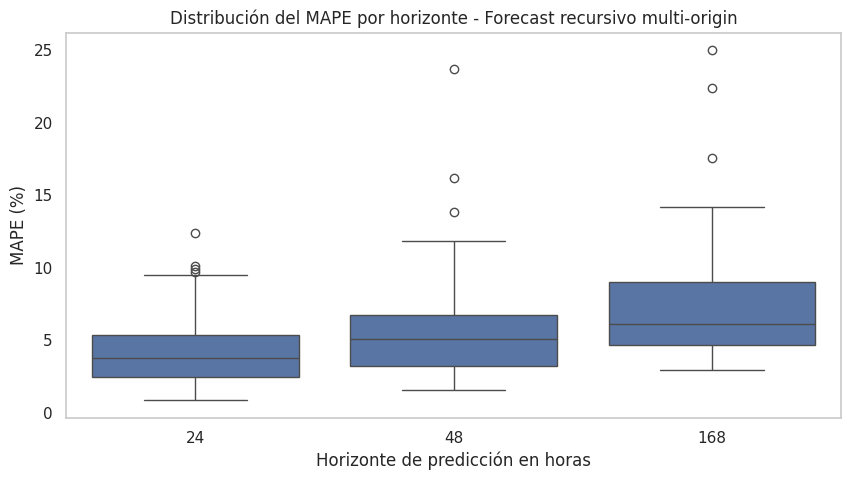

In [66]:
# ============================================================
# 64. DISTRIBUCIÓN DEL MAPE MULTI-ORIGIN POR HORIZONTE
# ============================================================

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=multi_origin_results_df,
    x='horizon_hours',
    y='MAPE_%'
)

plt.title('Distribución del MAPE por horizonte - Forecast recursivo multi-origin')
plt.xlabel('Horizonte de predicción en horas')
plt.ylabel('MAPE (%)')
plt.grid(axis='y')
plt.show()

La evaluación multi-step muestra un cambio importante respecto de la evaluación supervisada inicial.

En la evaluación supervisada, Random Forest había logrado un MAPE cercano a 0,99%, pero al pasar a un escenario recursivo, donde el modelo debe usar sus propias predicciones para proyectar hacia adelante, el error aumenta de forma considerable.

En la primera prueba desde el inicio del conjunto de test, los resultados fueron:

| Horizonte | MAE | RMSE | MAPE |
|---:|---:|---:|---:|
| 24 horas | 2.497,90 MW | 3.336,06 MW | 6,42% |
| 48 horas | 3.312,60 MW | 3.888,59 MW | 8,18% |
| 168 horas | 2.515,31 MW | 3.000,23 MW | 7,44% |

Estos resultados indican que el modelo pierde precisión cuando debe proyectar varios pasos hacia adelante sin conocer los valores reales intermedios.

El deterioro es esperable, ya que Random Forest dependía fuertemente de `lag_1`, es decir, del consumo de la hora inmediatamente anterior. Cuando el modelo entra en modo recursivo, ese `lag_1` deja de ser un dato real y empieza a ser una predicción previa. Por lo tanto, el error se puede ir propagando a lo largo del horizonte.

Visualmente, los gráficos muestran que el modelo conserva la forma general del ciclo diario, pero tiende a suavizar los peaks y valles. En varios tramos, el forecast subestima los máximos de demanda y no alcanza completamente la magnitud de los peaks reales.

Esto es crítico desde una perspectiva operacional, porque los peaks de demanda suelen ser precisamente los momentos de mayor interés para planificación, alertas y gestión de capacidad.

La evaluación multi-origin entrega una visión más robusta porque no depende de una sola semana inicial, sino que evalúa múltiples puntos de inicio dentro del período de prueba.

El resumen promedio por horizonte fue:

| Horizonte | MAE promedio | RMSE promedio | MAPE promedio | N orígenes |
|---:|---:|---:|---:|---:|
| 24 horas | 1.472,66 MW | 1.803,52 MW | 4,34% | 52 |
| 48 horas | 1.791,21 MW | 2.388,35 MW | 5,97% | 52 |
| 168 horas | 2.519,50 MW | 3.090,34 MW | 7,80% | 52 |

La tendencia es clara: a medida que aumenta el horizonte de predicción, aumenta también el error promedio.

El horizonte de 24 horas presenta el mejor desempeño, con un MAPE promedio de 4,34%. El horizonte de 48 horas aumenta a 5,97%, mientras que el forecast semanal de 168 horas alcanza un MAPE promedio de 7,80%.

El boxplot confirma además que la dispersión del error aumenta con el horizonte. En 24 horas, la distribución del MAPE es más compacta; en 48 y 168 horas aparecen mayor variabilidad y outliers más altos, algunos por encima del 20%.

Esto sugiere que Random Forest puede ser razonable para forecast diario de corto plazo, pero pierde robustez cuando se le exige proyectar una semana completa de forma recursiva.

Usando la equivalencia comunicacional definida en el proyecto:

- 1 MW ≈ 2.400 hogares equivalentes durante una hora.

Los errores promedio multi-origin pueden interpretarse de la siguiente manera:

| Horizonte | MAE promedio | Hogares equivalentes aproximados |
|---:|---:|---:|
| 24 horas | 1.472,66 MW | 3.534.384 hogares equivalentes |
| 48 horas | 1.791,21 MW | 4.298.904 hogares equivalentes |
| 168 horas | 2.519,50 MW | 6.046.800 hogares equivalentes |

Esta traducción no reemplaza las métricas técnicas, pero ayuda a dimensionar el orden de magnitud del error para audiencias no técnicas.

Aunque los porcentajes de error pueden parecer moderados, en sistemas eléctricos de gran escala un error de miles de MW puede equivaler al consumo horario promedio de millones de hogares. Esto refuerza la importancia de mejorar el forecast multi-step antes de pensar en una aplicación operacional real.

El forecast recursivo con Random Forest permite avanzar hacia un escenario más realista, pero evidencia una limitación importante del modelo: su dependencia del rezago inmediato (`lag_1`).

Mientras el modelo dispone de datos reales recientes, predice con alta precisión. Sin embargo, cuando debe usar sus propias predicciones como insumo, el error aumenta y los peaks tienden a suavizarse.

Por lo tanto, Random Forest sigue siendo un buen modelo base, pero no debería considerarse todavía como solución final para forecast semanal.

La siguiente etapa debe enfocarse en modelos o estrategias que mejoren el forecast multi-step, especialmente para horizontes de 48 y 168 horas.

El modelo Random Forest funciona muy bien para estimaciones de corto plazo cuando cuenta con información reciente real. Sin embargo, cuando se le exige proyectar hacia adelante durante 24, 48 o 168 horas, su precisión disminuye.

Esto no significa que el modelo sea malo. Significa que el problema cambió: ya no estamos evaluando una predicción con datos recientes conocidos, sino una simulación más cercana a la realidad operacional.

Desde una perspectiva de negocio, el modelo podría ser útil para alertas diarias o monitoreo táctico de corto plazo, pero todavía requiere mejoras antes de usarse para planificación semanal.

El principal desafío ahora es reducir la acumulación de error y mejorar la captura de peaks de demanda.

Esta etapa permite responder una pregunta más cercana a la realidad operacional:

> ¿Cuántas horas hacia adelante puede anticipar la demanda el modelo antes de que el error deje de ser aceptable?

Un horizonte de 24 horas podría ser útil para alertas tácticas diarias.

Un horizonte de 48 horas podría apoyar planificación de recursos y ajustes operacionales.

Un horizonte de 168 horas permitiría una mirada semanal, útil para programación y coordinación, siempre que el error se mantenga en niveles aceptables.

Además de reportar MAE, RMSE y MAPE, los errores en MW deberán traducirse a hogares equivalentes. Esto permitirá explicar de forma simple qué significa, en términos cotidianos, que el modelo se equivoque en cierta cantidad de MW.

Por ejemplo, un error de 100 MW durante una hora equivale aproximadamente al consumo horario promedio de 240.000 hogares equivalentes.

## Propósito de esta etapa

Después de evaluar el forecast multi-step inicial, esta sección profundiza en tres aspectos críticos:

1. Cómo evoluciona el error dentro del horizonte de predicción.
2. Si el modelo falla especialmente en eventos de alta demanda.
3. Si Random Forest recursivo realmente mejora reglas simples de persistencia diaria o semanal.

Estos análisis permiten decidir si Random Forest sigue siendo un buen candidato para forecast semanal o si conviene avanzar hacia otros enfoques, como XGBoost, LightGBM o modelos directos por horizonte.

## 30. Error por paso del horizonte de predicción

En un forecast multi-step no basta con conocer el error promedio del horizonte completo. También es necesario analizar cómo evoluciona el error a medida que el modelo avanza en el tiempo.

Este análisis permite identificar si el modelo se deteriora progresivamente al utilizar sus propias predicciones como insumo, o si el error se concentra en ciertos momentos específicos del horizonte.

En esta sección se evalúa el comportamiento del modelo Random Forest recursivo a lo largo de un horizonte de 168 horas, equivalente a una semana completa de predicción horaria.

In [67]:
# ============================================================
# 65. FORECAST RECURSIVO DETALLADO POR PASO DEL HORIZONTE
# ============================================================

def recursive_forecast_detailed(model, history_series, start_timestamp, horizon_hours):
    """
    Genera forecast recursivo y retorna un dataframe con:
    - fecha/hora predicha
    - paso del horizonte
    - predicción
    """

    history_extended = history_series.copy()
    rows = []

    future_timestamps = pd.date_range(
        start=start_timestamp,
        periods=horizon_hours,
        freq='h'
    )

    for step, ts in enumerate(future_timestamps, start=1):
        X_future = build_future_features(ts, history_extended)
        yhat = model.predict(X_future)[0]

        rows.append({
            'timestamp': ts,
            'step': step,
            'y_pred': yhat
        })

        history_extended.loc[ts] = yhat

    return pd.DataFrame(rows).set_index('timestamp')

In [68]:
# ============================================================
# 66. ERROR POR PASO DEL HORIZONTE CON MÚLTIPLES ORÍGENES
# ============================================================

step_error_rows = []

horizon_hours = 168
forecast_origins = pd.date_range(
    start=test.index.min(),
    end=test.index.max() - pd.Timedelta(hours=horizon_hours),
    freq='168h'
)

for origin in forecast_origins:
    history_available = df.loc[df.index < origin, 'PJME_MW'].copy()

    pred_df = recursive_forecast_detailed(
        model=rf_model,
        history_series=history_available,
        start_timestamp=origin,
        horizon_hours=horizon_hours
    )

    pred_df['y_true'] = df.loc[pred_df.index, 'PJME_MW']
    pred_df['error'] = pred_df['y_true'] - pred_df['y_pred']
    pred_df['abs_error'] = pred_df['error'].abs()
    pred_df['pct_error'] = pred_df['abs_error'] / pred_df['y_true'] * 100
    pred_df['origin'] = origin

    step_error_rows.append(pred_df.reset_index())

step_error_df = pd.concat(step_error_rows, ignore_index=True)

step_error_df.head()

,timestamp,step,y_pred,y_true,error,abs_error,pct_error,origin
0,2017-08-03 00:00:00,1,"31,440.57","31,646.00",205.43,205.43,0.65,2017-08-03
1,2017-08-03 01:00:00,2,"28,853.12","29,189.00",335.88,335.88,1.15,2017-08-03
2,2017-08-03 02:00:00,3,"26,985.51","27,584.00",598.49,598.49,2.17,2017-08-03
3,2017-08-03 03:00:00,4,"25,836.27","26,544.00",707.73,707.73,2.67,2017-08-03
4,2017-08-03 04:00:00,5,"25,295.99","26,012.00",716.01,716.01,2.75,2017-08-03


In [69]:
# ============================================================
# 67. RESUMEN DEL ERROR POR PASO DEL HORIZONTE
# ============================================================

step_error_summary = (
    step_error_df
    .groupby('step')
    .agg(
        MAE_step=('abs_error', 'mean'),
        MAPE_step=('pct_error', 'mean'),
        bias_step=('error', 'mean')
    )
    .reset_index()
)

step_error_summary[['MAE_step', 'MAPE_step', 'bias_step']] = (
    step_error_summary[['MAE_step', 'MAPE_step', 'bias_step']].round(2)
)

step_error_summary.head()

,step,MAE_step,MAPE_step,bias_step
0,1,252.33,0.85,155.68
1,2,407.87,1.45,311.83
2,3,536.14,1.97,388.91
3,4,591.55,2.23,427.63
4,5,680.66,2.58,472.09


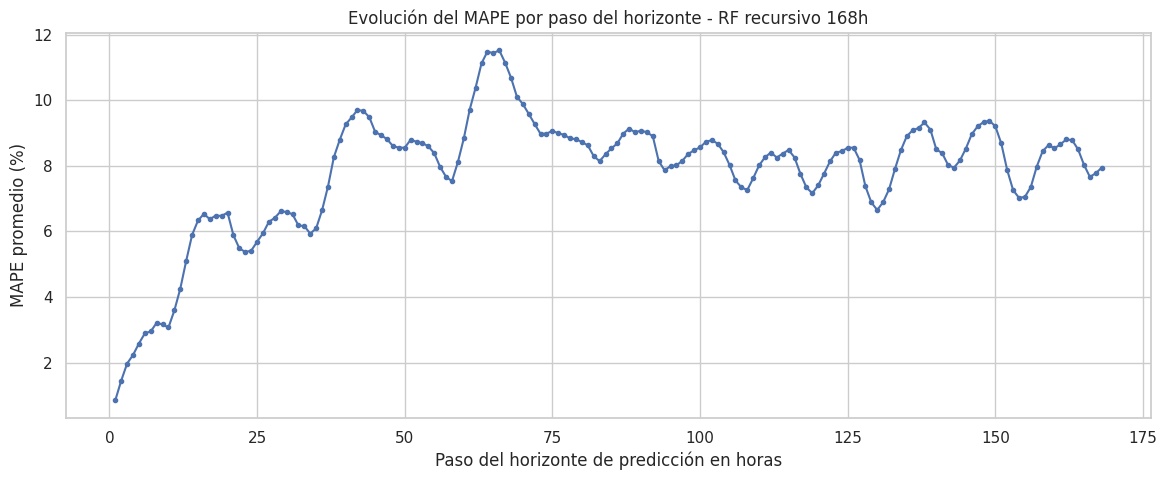

In [70]:
# ============================================================
# 68. EVOLUCIÓN DEL MAPE POR PASO DEL HORIZONTE
# ============================================================

plt.figure(figsize=(14, 5))
plt.plot(
    step_error_summary['step'],
    step_error_summary['MAPE_step'],
    marker='o',
    markersize=3
)

plt.title('Evolución del MAPE por paso del horizonte - RF recursivo 168h')
plt.xlabel('Paso del horizonte de predicción en horas')
plt.ylabel('MAPE promedio (%)')
plt.grid(True)
plt.show()

In [71]:
# ============================================================
# 69. ERROR POR PASO TRADUCIDO A HOGARES EQUIVALENTES
# ============================================================

# Definición del supuesto comunicacional de hogar equivalente.
# Se incluye aquí nuevamente para evitar errores si la celda anterior no fue ejecutada.

HOUSEHOLD_KWH_MONTH = 300
HOUSEHOLD_KWH_HOUR = HOUSEHOLD_KWH_MONTH / (30 * 24)
HOUSEHOLDS_PER_MW = 1000 / HOUSEHOLD_KWH_HOUR

print(f"Consumo horario de hogar equivalente: {HOUSEHOLD_KWH_HOUR:.3f} kWh/h")
print(f"1 MW equivale aproximadamente a {HOUSEHOLDS_PER_MW:,.0f} hogares equivalentes durante una hora")

step_error_summary['households_equivalent'] = (
    step_error_summary['MAE_step'] * HOUSEHOLDS_PER_MW
).round(0)

step_error_summary.head(24)

Consumo horario de hogar equivalente: 0.417 kWh/h
1 MW equivale aproximadamente a 2,400 hogares equivalentes durante una hora


,step,MAE_step,MAPE_step,bias_step,households_equivalent
0,1,252.33,0.85,155.68,"605,592.00"
1,2,407.87,1.45,311.83,"978,888.00"
2,3,536.14,1.97,388.91,"1,286,736.00"
3,4,591.55,2.23,427.63,"1,419,720.00"
4,5,680.66,2.58,472.09,"1,633,584.00"
5,6,778.95,2.89,488.39,"1,869,480.00"
6,7,828.10,2.95,356.32,"1,987,440.00"
7,8,973.77,3.21,73.05,"2,337,048.00"
8,9,"1,006.37",3.16,-208.21,"2,415,288.00"
9,10,"1,012.29",3.07,-286.08,"2,429,496.00"


### Primeros registros del forecast detallado

El dataframe `step_error_df` permite observar, para cada origen de forecast, la predicción realizada, el valor real, el error, el error absoluto y el error porcentual.

En los primeros registros del primer origen evaluado se observa que el modelo inicia con errores bajos, pero estos comienzan a aumentar a medida que avanza el horizonte.

| timestamp | step | y_pred | y_true | error | abs_error | pct_error | origin |
|---|---:|---:|---:|---:|---:|---:|---|
| 2017-08-03 00:00:00 | 1 | 31.440,57 | 31.646,00 | 205,43 | 205,43 | 0,65 | 2017-08-03 |
| 2017-08-03 01:00:00 | 2 | 28.853,12 | 29.189,00 | 335,88 | 335,88 | 1,15 | 2017-08-03 |
| 2017-08-03 02:00:00 | 3 | 26.985,51 | 27.584,00 | 598,49 | 598,49 | 2,17 | 2017-08-03 |
| 2017-08-03 03:00:00 | 4 | 25.836,27 | 26.544,00 | 707,73 | 707,73 | 2,66 | 2017-08-03 |
| 2017-08-03 04:00:00 | 5 | 25.295,99 | 26.012,00 | 716,01 | 716,01 | 2,75 | 2017-08-03 |

### Primeros pasos del resumen promedio

El resumen por paso muestra que el error promedio crece rápidamente durante las primeras horas del horizonte.

| Paso | MAE_step | MAPE_step | bias_step |
|---:|---:|---:|---:|
| 1 | 252,33 | 0,85 | 155,68 |
| 2 | 407,87 | 1,45 | 311,83 |
| 3 | 536,14 | 1,97 | 388,91 |
| 4 | 591,55 | 2,23 | 427,63 |
| 5 | 680,66 | 2,58 | 472,09 |

### Primeras 24 horas traducidas a hogares equivalentes

La conversión a hogares equivalentes permite dimensionar el error promedio horario en una unidad más comprensible para una audiencia no técnica.

| Paso | MAE_step | MAPE_step | bias_step | Hogares equivalentes |
|---:|---:|---:|---:|---:|
| 1 | 252,33 | 0,85 | 155,68 | 605.592 |
| 2 | 407,87 | 1,45 | 311,83 | 978.888 |
| 3 | 536,14 | 1,97 | 388,91 | 1.286.736 |
| 4 | 591,55 | 2,23 | 427,63 | 1.419.720 |
| 5 | 680,66 | 2,58 | 472,09 | 1.633.584 |
| 6 | 778,95 | 2,89 | 488,39 | 1.869.480 |
| 7 | 828,10 | 2,95 | 356,32 | 1.987.440 |
| 8 | 973,77 | 3,21 | 73,05 | 2.337.048 |
| 9 | 1.006,37 | 3,16 | -208,21 | 2.415.288 |
| 10 | 1.012,29 | 3,07 | -286,80 | 2.429.496 |
| 11 | 1.202,40 | 3,59 | -529,84 | 2.885.760 |
| 12 | 1.448,18 | 4,20 | -713,20 | 3.475.632 |
| 13 | 1.747,63 | 5,10 | -755,80 | 4.194.312 |
| 14 | 2.030,70 | 5,89 | -729,36 | 4.873.680 |
| 15 | 2.217,84 | 6,33 | -547,81 | 5.322.816 |
| 16 | 2.311,40 | 6,53 | -364,86 | 5.547.360 |
| 17 | 2.284,37 | 6,37 | -90,02 | 5.482.488 |
| 18 | 2.366,13 | 6,48 | 99,33 | 5.678.712 |
| 19 | 2.409,52 | 6,47 | 226,18 | 5.782.848 |
| 20 | 2.423,26 | 6,57 | 274,24 | 5.815.824 |
| 21 | 2.174,10 | 5,88 | 226,67 | 5.217.840 |
| 22 | 1.996,00 | 5,48 | 95,00 | 4.790.400 |
| 23 | 1.879,80 | 5,37 | 88,20 | 4.511.520 |
| 24 | 1.773,56 | 5,41 | 223,86 | 4.256.544 |

### Conclusiones del error por paso del horizonte

El análisis por paso del horizonte muestra que el error del forecast recursivo aumenta rápidamente durante las primeras horas de predicción.

En los primeros pasos, el modelo mantiene errores relativamente bajos. Por ejemplo, el MAPE parte en 0,85% en la primera hora, sube a 1,45% en la segunda hora y alcanza 2,58% hacia la quinta hora.

Esto indica que Random Forest conserva buena capacidad predictiva cuando el horizonte es muy corto. Sin embargo, a medida que el modelo comienza a utilizar sus propias predicciones como insumo, el error aumenta de forma progresiva.

Durante las primeras 24 horas, el MAPE llega a valores cercanos a 5% - 6,5% en varias horas del día. Esto evidencia una acumulación de error propia del enfoque recursivo.

El gráfico de evolución del MAPE para los 168 pasos muestra que el error crece con fuerza al inicio y luego se mueve en una banda alta, principalmente entre 7% y 10%, con algunos peaks cercanos a 11% - 12%.

Este comportamiento confirma que el modelo Random Forest, aunque fue muy efectivo en la evaluación supervisada inicial, pierde precisión cuando debe proyectar varios pasos hacia adelante sin conocer los valores reales intermedios.

### Inferencia técnica

La principal explicación técnica de este deterioro está relacionada con la alta importancia de la variable `lag_1` en el modelo Random Forest.

En una predicción de una hora hacia adelante, `lag_1` corresponde a un valor real conocido y reciente. Sin embargo, en un forecast recursivo, después del primer paso, `lag_1` comienza a ser una predicción generada por el propio modelo.

Esto genera una dinámica de propagación del error:

Predicción imperfecta → se usa como entrada del siguiente paso → genera nuevo error → el error se acumula en el horizonte.

Por esta razón, el modelo mantiene la forma general de la serie, pero suaviza peaks, pierde precisión y aumenta su error a medida que avanza el horizonte de predicción.

### Traducción a hogares equivalentes

Para facilitar la interpretación de los errores, se utiliza la equivalencia comunicacional definida en el proyecto:

**1 MW ≈ 2.400 hogares equivalentes durante una hora.**

Bajo esta referencia, un error de 252,33 MW en la primera hora equivale aproximadamente al consumo horario promedio de 605.592 hogares equivalentes.

Hacia las horas de mayor error dentro del primer día, el impacto aumenta considerablemente. Por ejemplo, un error de 2.423,26 MW equivale aproximadamente al consumo horario promedio de 5.815.824 hogares equivalentes.

Esta equivalencia no reemplaza las métricas técnicas, pero ayuda a dimensionar el tamaño del error en una unidad más comprensible para una audiencia no especializada.

### Lectura ejecutiva

Desde una perspectiva operacional, el modelo Random Forest recursivo puede ser útil para predicciones de muy corto plazo, especialmente durante las primeras horas del horizonte.

Sin embargo, su confiabilidad disminuye cuando se exige una proyección más larga. El aumento progresivo del error sugiere que el modelo no debería utilizarse todavía como solución final para planificación semanal o gestión anticipada de peaks de demanda.

El modelo puede servir como una primera base para monitoreo táctico, pero requiere mejoras antes de convertirse en una herramienta de planificación operativa de mayor horizonte.

### Cierre de la evaluación por paso del horizonte

El análisis confirma que Random Forest recursivo puede ser útil para predicciones de muy corto plazo, especialmente durante las primeras horas del horizonte.

Sin embargo, su desempeño se deteriora cuando se le exige proyectar una semana completa. Esto limita su uso como solución final para planificación semanal o gestión anticipada de peaks de demanda.

Por lo tanto, el siguiente paso metodológico será evaluar si el modelo tiende a subestimar o sobreestimar la demanda, especialmente en eventos de alta demanda, y comparar su desempeño contra baselines recursivos simples.

Estos análisis permitirán decidir si conviene mejorar Random Forest, probar modelos como XGBoost o LightGBM, o cambiar hacia un enfoque directo por horizonte.

## 31. Análisis de sesgo del forecast recursivo

Además del error absoluto, es importante saber si el modelo tiende a subestimar o sobreestimar la demanda.

Un modelo con bajo error promedio puede ser riesgoso si sistemáticamente subestima los peaks de demanda, ya que podría entregar una falsa sensación de seguridad operativa.

En esta sección se analiza el signo del error del forecast recursivo para identificar si el modelo presenta un sesgo sistemático por horizonte de predicción.

In [72]:
# ============================================================
# 70. DATASET DETALLADO MULTI-ORIGIN PARA SESGO Y PEAKS
# ============================================================

multi_origin_detail_rows = []

horizons = [24, 48, 168]
forecast_origins = pd.date_range(
    start=test.index.min(),
    end=test.index.max() - pd.Timedelta(hours=max(horizons)),
    freq='168h'
)

for origin in forecast_origins:
    history_available = df.loc[df.index < origin, 'PJME_MW'].copy()

    for h in horizons:
        pred_df = recursive_forecast_detailed(
            model=rf_model,
            history_series=history_available,
            start_timestamp=origin,
            horizon_hours=h
        )

        pred_df['y_true'] = df.loc[pred_df.index, 'PJME_MW']
        pred_df['error'] = pred_df['y_true'] - pred_df['y_pred']
        pred_df['abs_error'] = pred_df['error'].abs()
        pred_df['pct_error'] = pred_df['abs_error'] / pred_df['y_true'] * 100
        pred_df['origin'] = origin
        pred_df['horizon_hours'] = h
        pred_df['hour'] = pred_df.index.hour
        pred_df['dayofweek'] = pred_df.index.dayofweek
        pred_df['month'] = pred_df.index.month

        multi_origin_detail_rows.append(pred_df.reset_index())

multi_origin_detail_df = pd.concat(multi_origin_detail_rows, ignore_index=True)

multi_origin_detail_df.head()

,timestamp,step,y_pred,y_true,error,abs_error,pct_error,origin,horizon_hours,hour,dayofweek,month
0,2017-08-03 00:00:00,1,"31,440.57","31,646.00",205.43,205.43,0.65,2017-08-03,24,0,3,8
1,2017-08-03 01:00:00,2,"28,853.12","29,189.00",335.88,335.88,1.15,2017-08-03,24,1,3,8
2,2017-08-03 02:00:00,3,"26,985.51","27,584.00",598.49,598.49,2.17,2017-08-03,24,2,3,8
3,2017-08-03 03:00:00,4,"25,836.27","26,544.00",707.73,707.73,2.67,2017-08-03,24,3,3,8
4,2017-08-03 04:00:00,5,"25,295.99","26,012.00",716.01,716.01,2.75,2017-08-03,24,4,3,8


In [73]:
# ============================================================
# 71. RESUMEN DE SESGO POR HORIZONTE
# ============================================================

bias_summary = (
    multi_origin_detail_df
    .groupby('horizon_hours')
    .agg(
        mean_error=('error', 'mean'),
        median_error=('error', 'median'),
        mean_abs_error=('abs_error', 'mean'),
        mean_pct_error=('pct_error', 'mean')
    )
    .reset_index()
)

bias_summary[['mean_error', 'median_error', 'mean_abs_error', 'mean_pct_error']] = (
    bias_summary[['mean_error', 'median_error', 'mean_abs_error', 'mean_pct_error']].round(2)
)

bias_summary['bias_direction'] = np.where(
    bias_summary['mean_error'] > 0,
    'Subestima en promedio',
    'Sobreestima en promedio'
)

bias_summary['households_equivalent_mean_error'] = (
    bias_summary['mean_error'].abs() * HOUSEHOLDS_PER_MW
).round(0)

bias_summary

,horizon_hours,mean_error,median_error,mean_abs_error,mean_pct_error,bias_direction,households_equivalent_mean_error
0,24,-13.12,-57.10,"1,472.60",4.34,Sobreestima en promedio,"31,488.00"
1,48,-148.37,-222.34,"1,971.21",5.97,Sobreestima en promedio,"356,088.00"
2,168,286.94,-42.83,"2,519.59",7.80,Subestima en promedio,"688,656.00"


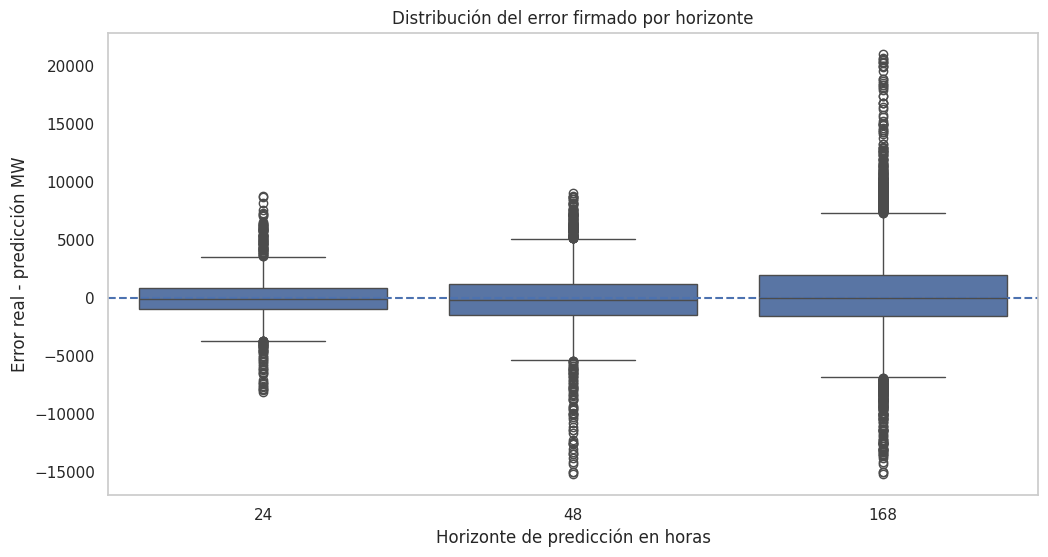

In [74]:
# ============================================================
# 72. DISTRIBUCIÓN DEL ERROR FIRMADO POR HORIZONTE
# ============================================================

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=multi_origin_detail_df,
    x='horizon_hours',
    y='error'
)

plt.axhline(0, linestyle='--')
plt.title('Distribución del error firmado por horizonte')
plt.xlabel('Horizonte de predicción en horas')
plt.ylabel('Error real - predicción MW')
plt.grid(axis='y')
plt.show()

### Primeros registros del dataset detallado multi-origin

El dataframe `multi_origin_detail_df` consolida las predicciones recursivas realizadas desde múltiples puntos de origen y para distintos horizontes de predicción.

Este dataset permite analizar el error firmado, el error absoluto, el error porcentual, el horizonte evaluado y variables temporales asociadas a cada predicción.

| timestamp | step | y_pred | y_true | error | abs_error | pct_error | origin | horizon_hours | hour | dayofweek | month |
|---|---:|---:|---:|---:|---:|---:|---|---:|---:|---:|---:|
| 2017-08-03 00:00:00 | 1 | 31.440,57 | 31.646,00 | 205,43 | 205,43 | 0,65 | 2017-08-03 | 24 | 0 | 3 | 8 |
| 2017-08-03 01:00:00 | 2 | 28.853,12 | 29.189,00 | 335,88 | 335,88 | 1,15 | 2017-08-03 | 24 | 1 | 3 | 8 |
| 2017-08-03 02:00:00 | 3 | 26.985,51 | 27.584,00 | 598,49 | 598,49 | 2,17 | 2017-08-03 | 24 | 2 | 3 | 8 |
| 2017-08-03 03:00:00 | 4 | 25.836,27 | 26.544,00 | 707,73 | 707,73 | 2,67 | 2017-08-03 | 24 | 3 | 3 | 8 |
| 2017-08-03 04:00:00 | 5 | 25.295,99 | 26.012,00 | 716,01 | 716,01 | 2,75 | 2017-08-03 | 24 | 4 | 3 | 8 |

### Resumen de sesgo por horizonte

El resumen de sesgo permite identificar si el modelo tiende a sobreestimar o subestimar la demanda en promedio para cada horizonte de predicción.

| Horizonte | Error medio | Error mediano | Error absoluto medio | Error porcentual medio | Dirección del sesgo | Hogares equivalentes del sesgo medio |
|---:|---:|---:|---:|---:|---|---:|
| 24 h | -13,12 MW | -5,70 MW | 1.472,60 MW | 4,34% | Sobreestima en promedio | 31.488 |
| 48 h | -148,37 MW | -222,34 MW | 1.791,21 MW | 5,97% | Sobreestima en promedio | 356.088 |
| 168 h | 286,94 MW | -42,83 MW | 2.519,59 MW | 7,80% | Subestima en promedio | 688.656 |

### Distribución del error firmado por horizonte

El boxplot de error firmado muestra cómo se distribuyen los errores del modelo para los horizontes de 24, 48 y 168 horas.

La línea horizontal en cero representa el punto donde la predicción coincide exactamente con el valor real.

Valores positivos indican subestimación, porque el valor real fue mayor que la predicción. Valores negativos indican sobreestimación, porque la predicción fue mayor que el valor real.

### Conclusiones del análisis de sesgo

El análisis de sesgo muestra que el comportamiento del modelo cambia según el horizonte de predicción.

Para el horizonte de 24 horas, el error medio es de -13,12 MW, lo que indica una sobreestimación promedio muy leve. Este sesgo es bajo en relación con el tamaño del sistema y sugiere que, en promedio, el modelo no presenta una desviación importante para el forecast diario.

Para el horizonte de 48 horas, el error medio baja a -148,37 MW, manteniendo una tendencia a sobreestimar la demanda. Aunque el sesgo sigue siendo moderado, el error absoluto medio aumenta a 1.791,21 MW y el MAPE promedio llega a 5,97%.

Para el horizonte de 168 horas, el error medio cambia de signo y alcanza 286,94 MW, lo que indica que el modelo comienza a subestimar la demanda en promedio cuando se proyecta una semana completa.

Este cambio de dirección es importante: el modelo no solo pierde precisión a mayor horizonte, sino que también cambia su comportamiento promedio, pasando desde una leve sobreestimación en 24 y 48 horas hacia una subestimación en el forecast semanal.

### Inferencia técnica

El signo del error permite interpretar la dirección del sesgo:

- Error positivo: el valor real fue mayor que la predicción; por lo tanto, el modelo subestimó la demanda.
- Error negativo: la predicción fue mayor que el valor real; por lo tanto, el modelo sobreestimó la demanda.

El resultado muestra que el modelo tiene un sesgo promedio bajo en 24 horas, una sobreestimación moderada en 48 horas y una subestimación promedio en 168 horas.

La distribución del error firmado confirma que la dispersión aumenta a medida que crece el horizonte de predicción. En 168 horas se observan errores extremos más amplios, tanto positivos como negativos, lo que evidencia mayor incertidumbre en el forecast semanal.

Esto es coherente con el comportamiento observado en el análisis por paso del horizonte: a medida que el modelo utiliza sus propias predicciones como entrada, el error se acumula y se vuelve más variable.

### Lectura ejecutiva del sesgo

No basta con saber cuánto se equivoca el modelo. También es importante saber en qué dirección se equivoca.

Cuando el modelo sobreestima, predice una demanda mayor a la real. Esto puede llevar a decisiones más conservadoras, aunque eventualmente menos eficientes.

Cuando el modelo subestima, predice una demanda menor a la real. En planificación energética, esto puede ser más riesgoso, especialmente durante eventos de alta demanda.

En este caso, el modelo sobreestima levemente en horizontes de 24 y 48 horas, pero comienza a subestimar en el horizonte semanal de 168 horas.

Traducido a hogares equivalentes, el sesgo promedio semanal de 286,94 MW equivale aproximadamente al consumo horario promedio de 688.656 hogares equivalentes.

Esta cifra no reemplaza la métrica técnica, pero ayuda a dimensionar que incluso un sesgo promedio aparentemente moderado puede representar una magnitud operacional relevante en un sistema eléctrico regional.

### Lectura del gráfico de error firmado

El gráfico de distribución del error firmado muestra que la variabilidad del error aumenta con el horizonte de predicción.

En 24 horas, los errores se concentran en un rango relativamente más acotado alrededor de cero.

En 48 horas, la dispersión aumenta y aparecen errores negativos más pronunciados, lo que indica episodios de sobreestimación relevantes.

En 168 horas, la dispersión es considerablemente mayor y se observan valores extremos tanto positivos como negativos. Esto confirma que el forecast semanal tiene mayor incertidumbre y puede presentar tanto subestimaciones como sobreestimaciones significativas.

Esta evidencia refuerza que Random Forest recursivo es útil como modelo base, pero requiere mejoras antes de ser usado como solución de planificación semanal.

### Cierre del análisis de sesgo

El análisis de sesgo complementa las métricas de error absoluto y porcentual.

Mientras MAE, RMSE y MAPE indican cuánto se equivoca el modelo, el sesgo permite entender si el modelo tiende a subestimar o sobreestimar la demanda.

Los resultados muestran que Random Forest recursivo mantiene un sesgo bajo para horizontes de 24 horas, aumenta su desviación en 48 horas y comienza a subestimar en promedio cuando se proyecta una semana completa.

Esta información será especialmente relevante para la siguiente sección, donde se evaluará el comportamiento del modelo durante eventos de peak demand.

## 32. Evaluación del error en eventos de peak demand

Los eventos de alta demanda son especialmente relevantes en sistemas eléctricos, ya que pueden tensionar la operación, aumentar costos y exigir decisiones rápidas de capacidad.

Por esta razón, se analiza el desempeño del forecast recursivo específicamente en las horas donde la demanda real se encuentra sobre el percentil 95 histórico.

In [75]:
# ============================================================
# 73. IDENTIFICACIÓN DE PEAK DEMAND EN FORECAST MULTI-STEP
# ============================================================

peak_threshold = df['PJME_MW'].quantile(0.95)

multi_origin_detail_df['is_peak_demand'] = np.where(
    multi_origin_detail_df['y_true'] >= peak_threshold,
    1,
    0
)

print(f"Umbral peak demand P95: {peak_threshold:,.2f} MW")
print("Registros peak en evaluación multi-origin:", multi_origin_detail_df['is_peak_demand'].sum())

Umbral peak demand P95: 44,187.00 MW
Registros peak en evaluación multi-origin: 438


In [76]:
# ============================================================
# 74. MÉTRICAS PEAK VS NO PEAK POR HORIZONTE
# ============================================================

peak_error_summary = (
    multi_origin_detail_df
    .groupby(['horizon_hours', 'is_peak_demand'])
    .agg(
        MAE=('abs_error', 'mean'),
        RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),
        MAPE=('pct_error', 'mean'),
        bias=('error', 'mean'),
        n_obs=('error', 'count')
    )
    .reset_index()
)

peak_error_summary[['MAE', 'RMSE', 'MAPE', 'bias']] = (
    peak_error_summary[['MAE', 'RMSE', 'MAPE', 'bias']].round(2)
)

peak_error_summary['segment'] = peak_error_summary['is_peak_demand'].map({
    0: 'No peak',
    1: 'Peak demand'
})

peak_error_summary['MAE_households_equivalent'] = (
    peak_error_summary['MAE'] * HOUSEHOLDS_PER_MW
).round(0)

peak_error_summary

,horizon_hours,is_peak_demand,MAE,RMSE,MAPE,bias,n_obs,segment,MAE_households_equivalent
0,24,0,"1,365.63","2,016.58",4.16,-171.15,1198,No peak,"3,277,512.00"
1,24,1,"4,035.68","4,421.20",8.62,"3,773.19",50,Peak demand,"9,685,632.00"
2,48,0,"1,863.59","2,733.73",5.81,-327.24,2402,No peak,"4,472,616.00"
3,48,1,"4,721.07","5,183.90",10.09,"4,422.42",94,Peak demand,"11,330,568.00"
4,168,0,"2,346.96","3,253.87",7.53,44.50,8442,No peak,"5,632,704.00"
5,168,1,"7,476.41","8,972.22",15.46,"7,248.17",294,Peak demand,"17,943,384.00"


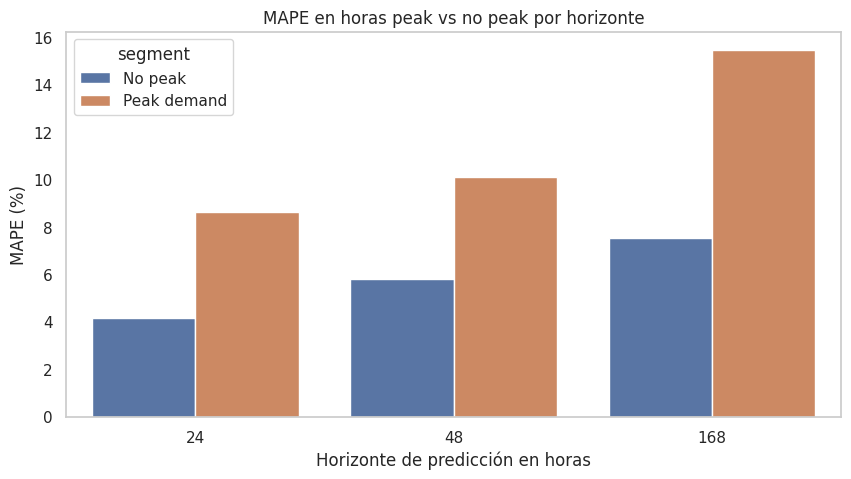

In [77]:
# ============================================================
# 75. MAPE PEAK VS NO PEAK POR HORIZONTE
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(
    data=peak_error_summary,
    x='horizon_hours',
    y='MAPE',
    hue='segment'
)

plt.title('MAPE en horas peak vs no peak por horizonte')
plt.xlabel('Horizonte de predicción en horas')
plt.ylabel('MAPE (%)')
plt.grid(axis='y')
plt.show()

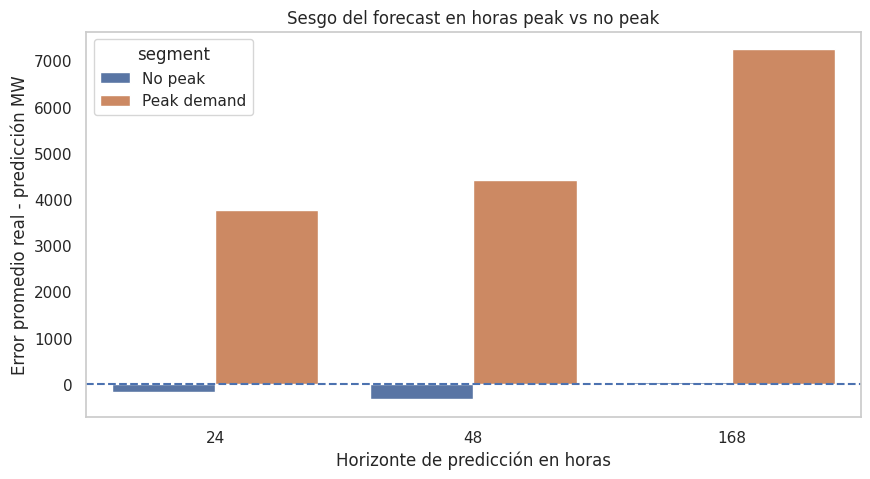

In [78]:
# ============================================================
# 76. SESGO EN HORAS PEAK VS NO PEAK
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(
    data=peak_error_summary,
    x='horizon_hours',
    y='bias',
    hue='segment'
)

plt.axhline(0, linestyle='--')
plt.title('Sesgo del forecast en horas peak vs no peak')
plt.xlabel('Horizonte de predicción en horas')
plt.ylabel('Error promedio real - predicción MW')
plt.grid(axis='y')
plt.show()

### Umbral de peak demand

Para identificar eventos de alta demanda se utilizó el percentil 95 de la serie histórica.

El umbral obtenido fue:

| Indicador | Valor |
|---|---:|
| Umbral peak demand P95 | 44.187,60 MW |
| Registros peak en evaluación multi-origin | 438 |

Esto significa que se consideran eventos de peak demand aquellas horas donde la demanda real fue igual o superior a 44.187,60 MW.

### Métricas peak vs no peak por horizonte

La siguiente tabla compara el desempeño del forecast recursivo entre horas normales y horas de peak demand.

| Horizonte | Segmento | MAE | RMSE | MAPE | Bias | N obs | Hogares equivalentes MAE |
|---:|---|---:|---:|---:|---:|---:|---:|
| 24 h | No peak | 1.365,63 MW | 2.016,58 MW | 4,16% | -171,15 MW | 1.198 | 3.277.512 |
| 24 h | Peak demand | 4.035,68 MW | 4.412,20 MW | 8,62% | 3.773,15 MW | 50 | 9.685.632 |
| 48 h | No peak | 1.863,59 MW | 2.733,73 MW | 5,81% | -327,24 MW | 2.402 | 4.472.616 |
| 48 h | Peak demand | 4.721,07 MW | 5.183,90 MW | 10,09% | 4.422,24 MW | 94 | 11.330.568 |
| 168 h | No peak | 2.346,96 MW | 3.253,87 MW | 7,53% | -44,50 MW | 8.442 | 5.632.704 |
| 168 h | Peak demand | 7.476,41 MW | 8.972,22 MW | 15,46% | 7.248,17 MW | 294 | 17.943.384 |

### Lectura de los gráficos peak vs no peak

El gráfico de MAPE muestra que el error porcentual es consistentemente mayor en horas de peak demand para todos los horizontes evaluados.

En 24 horas, el MAPE aumenta desde 4,16% en horas no peak hasta 8,62% en horas peak.

En 48 horas, el MAPE aumenta desde 5,81% hasta 10,09%.

En 168 horas, el MAPE aumenta desde 7,53% hasta 15,46%.

El gráfico de sesgo muestra un resultado crítico: en horas peak el modelo presenta un sesgo positivo alto en todos los horizontes. Esto significa que el valor real fue mayor que la predicción, por lo tanto el modelo está subestimando sistemáticamente la demanda en los momentos de mayor consumo.

### Conclusiones del error en peak demand

El análisis de peak demand muestra que el modelo Random Forest recursivo pierde precisión precisamente en los momentos de mayor demanda eléctrica.

En todos los horizontes evaluados, el error es más alto en horas peak que en horas no peak. Para el horizonte de 24 horas, el MAPE pasa de 4,16% en horas no peak a 8,62% en horas peak. Para 48 horas, aumenta de 5,81% a 10,09%. Para 168 horas, el error llega a 15,46% en peak demand.

Este deterioro es relevante porque los eventos peak son justamente los períodos donde una predicción precisa tiene mayor valor operativo.

Además, el sesgo en horas peak es positivo en todos los horizontes, lo que indica que el modelo subestima sistemáticamente la demanda durante eventos de alta exigencia.

Esto confirma que Random Forest recursivo, aunque es útil como modelo base, todavía no es suficiente como solución final para planificación semanal o gestión crítica de peak demand.

### Inferencia técnica

El análisis peak vs no peak evidencia que el modelo tiene dificultades para capturar la magnitud completa de los eventos de alta demanda.

Esto es consistente con lo observado en los gráficos de forecast recursivo, donde el modelo tiende a suavizar los peaks y no alcanza completamente los máximos reales.

La subestimación en horas peak puede estar asociada a tres factores:

1. Dependencia fuerte de rezagos recientes, especialmente `lag_1`.
2. Acumulación de error propia del enfoque recursivo.
3. Falta de variables exógenas relevantes, como temperatura, feriados, calendario laboral o eventos extremos.

Técnicamente, esto sugiere que mejorar el forecast semanal no solo requiere cambiar el algoritmo, sino también revisar la estrategia de modelamiento y la información disponible para anticipar peaks.

### Lectura ejecutiva del peak demand

Los eventos de peak demand son los momentos donde el sistema eléctrico alcanza niveles especialmente altos de consumo.

En estos períodos, una mala predicción puede ser más costosa que en horas normales, porque puede afectar decisiones de planificación, capacidad, costos y respuesta operativa.

El modelo evaluado se equivoca más en estos momentos críticos. Por ejemplo, en el horizonte semanal de 168 horas, el error promedio en horas peak es de 7.476,41 MW.

Usando la equivalencia definida en el proyecto, ese error equivale aproximadamente al consumo horario promedio de 17.943.384 hogares equivalentes.

Esta cifra muestra que, aunque el modelo pueda tener buen desempeño en condiciones normales, todavía requiere mejoras importantes antes de ser usado para anticipar eventos críticos de alta demanda.

### Riesgo operacional asociado

El principal riesgo detectado es la subestimación sistemática de la demanda en horas peak.

Desde una perspectiva operativa, subestimar la demanda puede ser más riesgoso que sobreestimarla, porque puede llevar a preparar menos capacidad de la necesaria o a activar tarde medidas de respuesta.

En una aplicación real, este comportamiento podría traducirse en alertas insuficientes, mala programación de recursos o decisiones tardías frente a eventos de alta demanda.

Por esta razón, cualquier solución predictiva basada en este modelo debería incorporar mecanismos específicos para mejorar la detección y predicción de peaks.

### Cierre de la evaluación en peak demand

El análisis de peak demand confirma una limitación importante del modelo Random Forest recursivo: su desempeño se deteriora en los períodos de mayor demanda eléctrica.

Aunque el modelo puede ser útil para monitoreo de corto plazo y escenarios normales, su subestimación sistemática en eventos peak limita su uso como herramienta de planificación crítica.

El siguiente paso será comparar este modelo contra baselines recursivos simples para determinar si Random Forest realmente agrega valor frente a reglas de persistencia diaria o semanal.

Luego, será necesario evaluar modelos candidatos como XGBoost, LightGBM o enfoques directos por horizonte, con especial atención a la mejora del desempeño en eventos de alta demanda.

## 33. Baseline recursivo comparable

Para evaluar correctamente el desempeño de Random Forest en forecast multi-step, es necesario compararlo contra una regla simple que también opere en modo futuro.

En esta sección se construyen dos baselines:

- Baseline 24h: usa el valor observado 24 horas antes.
- Baseline 168h: usa el valor observado 168 horas antes, es decir, el mismo horario de la semana anterior.

Estos baselines permiten evaluar si Random Forest realmente agrega valor frente a reglas simples de persistencia diaria o semanal.

In [79]:
# ============================================================
# 77. FUNCIÓN BASELINE ESTACIONAL MULTI-STEP
# ============================================================

def seasonal_baseline_forecast(history_series, start_timestamp, horizon_hours, seasonal_lag):
    """
    Forecast baseline usando persistencia estacional.
    seasonal_lag puede ser:
    - 24 para mismo horario del día anterior
    - 168 para mismo horario de la semana anterior
    """

    history_extended = history_series.copy()
    predictions = []
    prediction_index = []

    future_timestamps = pd.date_range(
        start=start_timestamp,
        periods=horizon_hours,
        freq='h'
    )

    for ts in future_timestamps:
        yhat = history_extended.loc[ts - pd.Timedelta(hours=seasonal_lag)]

        predictions.append(yhat)
        prediction_index.append(ts)

        history_extended.loc[ts] = yhat

    return pd.Series(predictions, index=prediction_index, name=f'baseline_lag_{seasonal_lag}')

In [80]:
# ============================================================
# 78. COMPARACIÓN MULTI-ORIGIN RF VS BASELINES ESTACIONALES
# ============================================================

baseline_comparison_results = []

horizons = [24, 48, 168]
seasonal_lags = [24, 168]

forecast_origins = pd.date_range(
    start=test.index.min(),
    end=test.index.max() - pd.Timedelta(hours=max(horizons)),
    freq='168h'
)

for origin in forecast_origins:
    history_available = df.loc[df.index < origin, 'PJME_MW'].copy()

    for h in horizons:
        rf_pred = recursive_forecast(
            model=rf_model,
            history_series=history_available,
            start_timestamp=origin,
            horizon_hours=h
        )
        y_true_h = df.loc[rf_pred.index, 'PJME_MW']

        rf_result = evaluate_forecast(
            y_true=y_true_h,
            y_pred=rf_pred,
            model_name='RF Recursive'
        )
        rf_result['origin'] = origin
        rf_result['horizon_hours'] = h
        baseline_comparison_results.append(rf_result)

        for lag in seasonal_lags:
            baseline_pred = seasonal_baseline_forecast(
                history_series=history_available,
                start_timestamp=origin,
                horizon_hours=h,
                seasonal_lag=lag
            )

            baseline_result = evaluate_forecast(
                y_true=y_true_h,
                y_pred=baseline_pred,
                model_name=f'Baseline lag_{lag}'
            )
            baseline_result['origin'] = origin
            baseline_result['horizon_hours'] = h
            baseline_comparison_results.append(baseline_result)

baseline_comparison_df = pd.DataFrame(baseline_comparison_results)

baseline_comparison_df.head()

,model,MAE,RMSE,MAPE_%,origin,horizon_hours
0,RF Recursive,"2,649.79","3,336.06",6.42,2017-08-03,24
1,Baseline lag_24,"2,608.29","2,713.07",7.28,2017-08-03,24
2,Baseline lag_168,"2,431.46","3,174.31",5.96,2017-08-03,24
3,RF Recursive,"3,312.60","3,888.59",8.18,2017-08-03,48
4,Baseline lag_24,"2,325.69","2,636.17",6.18,2017-08-03,48


In [81]:
# ============================================================
# 79. RESUMEN RF VS BASELINES POR HORIZONTE
# ============================================================

baseline_comparison_summary = (
    baseline_comparison_df
    .groupby(['horizon_hours', 'model'])
    .agg(
        MAE_mean=('MAE', 'mean'),
        RMSE_mean=('RMSE', 'mean'),
        MAPE_mean=('MAPE_%', 'mean'),
        MAPE_std=('MAPE_%', 'std'),
        n_origins=('origin', 'count')
    )
    .reset_index()
)

cols_round = ['MAE_mean', 'RMSE_mean', 'MAPE_mean', 'MAPE_std']
baseline_comparison_summary[cols_round] = baseline_comparison_summary[cols_round].round(2)

baseline_comparison_summary

,horizon_hours,model,MAE_mean,RMSE_mean,MAPE_mean,MAPE_std,n_origins
0,24,Baseline lag_168,"3,013.25","3,306.27",9.21,5.46,52
1,24,Baseline lag_24,"2,023.82","2,302.41",6.21,3.46,52
2,24,RF Recursive,"1,472.60","1,803.52",4.34,2.61,52
3,48,Baseline lag_168,"3,328.82","3,770.96",10.30,6.45,52
4,48,Baseline lag_24,"2,357.99","2,764.84",7.38,4.46,52
5,48,RF Recursive,"1,971.21","2,383.05",5.97,4.02,52
6,168,Baseline lag_168,"3,585.16","4,321.24",11.23,5.91,52
7,168,Baseline lag_24,"3,283.70","3,959.26",10.79,6.16,52
8,168,RF Recursive,"2,519.59","3,090.34",7.80,4.56,52


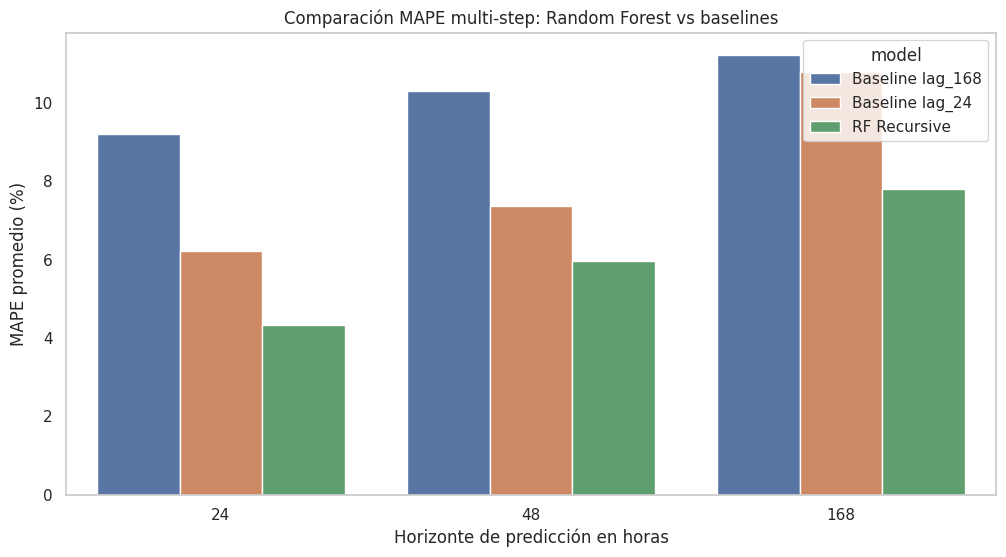

In [82]:
# ============================================================
# 80. COMPARACIÓN MAPE RF VS BASELINES POR HORIZONTE
# ============================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    data=baseline_comparison_summary,
    x='horizon_hours',
    y='MAPE_mean',
    hue='model'
)

plt.title('Comparación MAPE multi-step: Random Forest vs baselines')
plt.xlabel('Horizonte de predicción en horas')
plt.ylabel('MAPE promedio (%)')
plt.grid(axis='y')
plt.show()

## 34. Selección del mejor modelo base para forecast multi-step

La selección del mejor modelo no debe basarse únicamente en el desempeño supervisado inicial. También debe considerar el comportamiento del modelo en forecast multi-step, su desempeño en peak demand y su comparación contra baselines simples.

En esta etapa se integra la evidencia acumulada para decidir si Random Forest sigue siendo el modelo base más adecuado o si conviene avanzar hacia otros enfoques.

### Resultados de la evaluación supervisada inicial

En la evaluación supervisada inicial, donde los modelos fueron comparados bajo el mismo conjunto de prueba y usando rezagos observados, Random Forest fue el modelo con mejor desempeño.

| Modelo | MAE | RMSE | MAPE |
|---|---:|---:|---:|
| Baseline Naive lag_24 | 2.306,93 | 3.146,19 | 7,32% |
| Linear Regression | 785,51 | 1.004,98 | 2,48% |
| Random Forest | 316,64 | 433,67 | 0,99% |

Estos resultados muestran que Random Forest captura con alta precisión la demanda eléctrica cuando dispone de información reciente real.

### Evidencia acumulada del forecast multi-step

Al pasar desde la evaluación supervisada hacia un escenario recursivo multi-step, el desempeño de Random Forest cambia de forma importante.

En forecast recursivo multi-origin, Random Forest obtiene los siguientes resultados promedio:

| Horizonte | MAE promedio | RMSE promedio | MAPE promedio | N orígenes |
|---:|---:|---:|---:|---:|
| 24 h | 1.472,60 | 1.803,52 | 4,34% | 52 |
| 48 h | 1.971,21 | 2.383,05 | 5,97% | 52 |
| 168 h | 2.519,59 | 3.090,34 | 7,80% | 52 |

La tendencia muestra que el error aumenta a medida que crece el horizonte de predicción. Esto confirma que el enfoque recursivo acumula error cuando el modelo debe utilizar sus propias predicciones como insumo.

### Evidencia en eventos de peak demand

El análisis de peak demand muestra que Random Forest recursivo pierde precisión justamente en los momentos de mayor demanda eléctrica.

| Horizonte | Segmento | MAPE | Bias |
|---:|---|---:|---:|
| 24 h | No peak | 4,16% | -171,15 MW |
| 24 h | Peak demand | 8,62% | 3.773,15 MW |
| 48 h | No peak | 5,81% | -327,24 MW |
| 48 h | Peak demand | 10,09% | 4.422,24 MW |
| 168 h | No peak | 7,53% | -44,50 MW |
| 168 h | Peak demand | 15,46% | 7.248,17 MW |

Este resultado es crítico porque el modelo subestima sistemáticamente la demanda en horas peak. En el horizonte semanal, el error promedio en peak demand alcanza 7.476,41 MW, equivalente aproximadamente al consumo horario promedio de 17.943.384 hogares equivalentes.

### Comparación contra baselines recursivos

La comparación contra baselines recursivos permite verificar si Random Forest realmente agrega valor frente a reglas simples de persistencia diaria y semanal.

| Horizonte | Modelo | MAPE promedio |
|---:|---|---:|
| 24 h | Baseline lag_168 | 9,21% |
| 24 h | Baseline lag_24 | 6,21% |
| 24 h | RF Recursive | 4,34% |
| 48 h | Baseline lag_168 | 10,30% |
| 48 h | Baseline lag_24 | 7,38% |
| 48 h | RF Recursive | 5,97% |
| 168 h | Baseline lag_168 | 11,23% |
| 168 h | Baseline lag_24 | 10,79% |
| 168 h | RF Recursive | 7,80% |

Random Forest supera a ambos baselines en los tres horizontes evaluados. Por lo tanto, el modelo sí agrega valor frente a reglas simples, aunque todavía presenta limitaciones relevantes en horizontes largos y eventos de alta demanda.

### Selección del modelo base

La evidencia acumulada permite concluir que Random Forest debe mantenerse como modelo base de referencia para el proyecto.

En la evaluación supervisada inicial, Random Forest fue claramente el mejor modelo, con un MAPE de 0,99%. Además, en forecast multi-step recursivo supera tanto al baseline diario como al baseline semanal en los horizontes de 24, 48 y 168 horas.

Esto confirma que Random Forest aprende patrones útiles más allá de una regla simple de persistencia.

Sin embargo, Random Forest no debe considerarse la solución final. Al pasar a forecast recursivo, el error aumenta con el horizonte de predicción, y en eventos de peak demand el modelo subestima sistemáticamente la demanda.

Por lo tanto, Random Forest queda seleccionado como benchmark o modelo base de referencia, pero el proyecto debe avanzar hacia modelos y estrategias que reduzcan la acumulación de error y mejoren la predicción de peaks.

### Inferencia técnica

La selección de Random Forest como modelo base se justifica porque supera a los modelos iniciales y también a los baselines recursivos en forecast multi-step.

No obstante, el análisis muestra dos limitaciones principales:

1. El enfoque recursivo acumula error a medida que aumenta el horizonte.
2. El modelo subestima la demanda durante eventos de peak demand.

Estas limitaciones sugieren que el problema no se resuelve únicamente cambiando hiperparámetros del Random Forest. Es necesario evaluar modelos más robustos y, probablemente, estrategias de forecast distintas.

En particular, se recomienda avanzar hacia dos líneas:

- modelos gradient boosting, como XGBoost o LightGBM;
- modelos directos por horizonte, para reducir la propagación de errores propia del enfoque recursivo.

### Lectura ejecutiva

Random Forest es el mejor modelo desarrollado hasta esta etapa, pero todavía no es suficiente como solución final para planificación semanal.

El modelo funciona mejor que reglas simples como repetir el consumo del día anterior o de la semana anterior. Sin embargo, cuando debe proyectar varios días hacia adelante, su error aumenta.

Además, el modelo falla más en los momentos más críticos: las horas de mayor demanda eléctrica.

Desde una perspectiva de negocio, esto significa que Random Forest puede servir como una primera base para monitoreo y forecast de corto plazo, pero requiere mejoras antes de convertirse en una herramienta confiable para planificación semanal o gestión de peak demand.

### Decisión metodológica

La decisión metodológica de esta etapa es mantener Random Forest como benchmark de referencia y desarrollar un nuevo modelo candidato para intentar mejorar el forecast semanal.

El siguiente modelo a desarrollar será **XGBoost**, debido a su buen desempeño en problemas tabulares, su capacidad para capturar relaciones no lineales y su compatibilidad con variables temporales, rezagos y rolling windows.

Además, se recomienda evaluar XGBoost en dos enfoques:

1. XGBoost recursivo, para comparar directamente con Random Forest recursivo.
2. XGBoost directo por horizonte, para evaluar si se reduce la acumulación de error.

## 35. Modelos candidatos para mejorar el forecast semanal

Una vez evaluado Random Forest en modo recursivo, el siguiente paso es identificar modelos o estrategias que puedan mejorar el forecast multi-step.

El objetivo es reducir la acumulación de error, mejorar la predicción de peaks y aumentar la robustez del forecast semanal.

### Contexto metodológico

Random Forest fue seleccionado como benchmark de referencia porque superó a los modelos iniciales y también a los baselines recursivos de persistencia diaria y semanal.

Sin embargo, el análisis multi-step mostró tres limitaciones relevantes:

1. El error aumenta a medida que crece el horizonte de predicción.
2. El modelo subestima sistemáticamente la demanda en eventos de peak demand.
3. El enfoque recursivo acumula error al utilizar predicciones previas como insumo.

Por esta razón, la siguiente etapa busca evaluar modelos y enfoques que puedan mejorar el forecast semanal.

### Modelos candidatos

Los principales modelos o enfoques candidatos para mejorar el forecast semanal son:

| Candidato | Tipo de enfoque | Objetivo principal |
|---|---|---|
| XGBoost recursivo | Gradient boosting recursivo | Comparar directamente contra Random Forest recursivo |
| XGBoost directo por horizonte | Modelo directo | Reducir acumulación de error |
| LightGBM | Gradient boosting eficiente | Evaluar mejora con mayor velocidad y escalabilidad |
| Modelo multi-output | Predicción vectorial | Predecir varios pasos hacia adelante en una sola salida |
| SARIMAX | Modelo estadístico | Capturar estructura temporal y estacionalidad |
| Prophet | Modelo aditivo | Explorar tendencia, estacionalidad y feriados |
| LSTM | Deep learning secuencial | Capturar dependencias temporales complejas |

### Inferencia técnica sobre modelos candidatos

El siguiente modelo recomendado es XGBoost, porque funciona bien con datos tabulares, variables temporales, rezagos y rolling windows. Además, puede capturar relaciones no lineales y suele superar a Random Forest en problemas predictivos estructurados.

LightGBM también es un candidato natural por su eficiencia y capacidad predictiva.

Sin embargo, dado que el principal problema observado es la acumulación de error en forecast recursivo, también será importante evaluar enfoques directos por horizonte, donde se entrena un modelo específico para predecir 24, 48 o 168 horas hacia adelante.

### Decisión de desarrollo inmediato

El siguiente desarrollo del proyecto será implementar **XGBoost** como modelo candidato principal.

Se evaluarán dos enfoques:

1. **XGBoost recursivo**, para comparar directamente contra Random Forest recursivo bajo el mismo esquema de forecast multi-step.
2. **XGBoost directo por horizonte**, para evaluar si un modelo entrenado específicamente para ciertos horizontes reduce la acumulación de error observada en el enfoque recursivo.

La comparación final permitirá decidir si XGBoost mejora el benchmark actual y si el enfoque directo por horizonte es más adecuado para forecast semanal.

### Cierre de modelos candidatos

El próximo desarrollo del proyecto comparará Random Forest con XGBoost.

Random Forest queda como benchmark de referencia. XGBoost será el siguiente modelo candidato, evaluado tanto en enfoque recursivo como en enfoque directo por horizonte.

El criterio de selección no será solo el error promedio global, sino también:

- desempeño en horizonte de 24, 48 y 168 horas;
- comportamiento en peak demand;
- estabilidad del error;
- capacidad de reducir la acumulación de error;
- valor práctico para planificación semanal.

## 36. XGBoost recursivo

El primer modelo candidato a desarrollar será XGBoost bajo el mismo enfoque recursivo utilizado con Random Forest.

El objetivo es evaluar si un modelo de gradient boosting puede mejorar la precisión del forecast multi-step manteniendo la misma lógica de predicción iterativa.

Este enfoque permite una comparación directa contra Random Forest recursivo.

In [83]:
# ============================================================
# 81. IMPORTACIÓN DE XGBOOST
# ============================================================

# En Kaggle normalmente XGBoost ya viene instalado.
# Si no estuviera disponible, se puede activar la línea de instalación.
# !pip install xgboost

from xgboost import XGBRegressor

print("XGBoost importado correctamente")

XGBoost importado correctamente


In [84]:
# ============================================================
# 82. ENTRENAMIENTO DE XGBOOST BASE
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("Modelo XGBoost base entrenado correctamente")

Modelo XGBoost base entrenado correctamente


In [85]:
# ============================================================
# 83. EVALUACIÓN SUPERVISADA INICIAL DE XGBOOST
# ============================================================

# Predicción sobre el mismo conjunto test usado para los modelos anteriores.
y_pred_xgb = xgb_model.predict(X_test)

xgb_supervised_results = evaluate_forecast(
    y_true=y_test,
    y_pred=y_pred_xgb,
    model_name='XGBoost Supervised'
)

xgb_supervised_results

{'model': 'XGBoost Supervised',
 'MAE': 298.2,
 'RMSE': np.float64(401.01),
 'MAPE_%': 0.94}

In [86]:
# ============================================================
# 84. IMPORTANCIA DE VARIABLES XGBOOST
# ============================================================

xgb_importance_df = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

xgb_importance_df.head(15)

,feature,importance
14,lag_1,0.75
15,lag_24,0.13
9,hour_cos,0.03
16,lag_168,0.03
0,hour,0.01
17,rolling_24,0.01
1,dayofweek,0.01
12,dayofweek_sin,0.01
8,hour_sin,0.01
11,month_cos,0.01


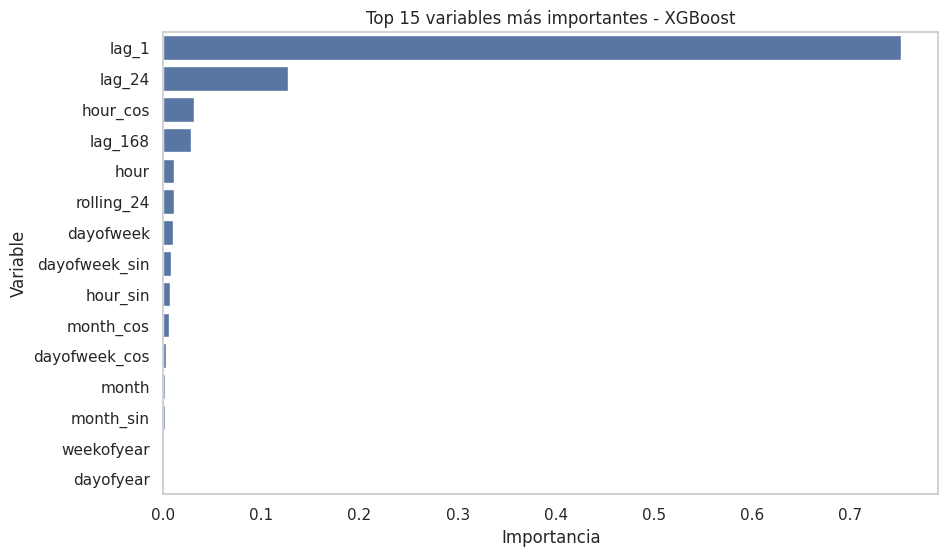

In [87]:
# ============================================================
# 85. VISUALIZACIÓN DE IMPORTANCIA DE VARIABLES XGBOOST
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(
    data=xgb_importance_df.head(15),
    x='importance',
    y='feature'
)

plt.title('Top 15 variables más importantes - XGBoost')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.grid(axis='x')
plt.show()

In [88]:
# ============================================================
# 86. FORECAST RECURSIVO CON XGBOOST PARA 24, 48 Y 168 HORAS
# ============================================================

xgb_recursive_results = []
xgb_recursive_predictions = {}

horizons = [24, 48, 168]
forecast_start = test.index.min()
history_available = df.loc[df.index < forecast_start, 'PJME_MW'].copy()

for h in horizons:
    y_pred_h = recursive_forecast(
        model=xgb_model,
        history_series=history_available,
        start_timestamp=forecast_start,
        horizon_hours=h
    )

    y_true_h = df.loc[y_pred_h.index, 'PJME_MW']

    result_h = evaluate_forecast(
        y_true=y_true_h,
        y_pred=y_pred_h,
        model_name=f'XGBoost Recursive {h}h'
    )

    result_h['horizon_hours'] = h
    xgb_recursive_results.append(result_h)
    xgb_recursive_predictions[h] = {
        'y_true': y_true_h,
        'y_pred': y_pred_h
    }

xgb_recursive_results_df = pd.DataFrame(xgb_recursive_results)
xgb_recursive_results_df

,model,MAE,RMSE,MAPE_%,horizon_hours
0,XGBoost Recursive 24h,"2,654.64","3,690.71",6.20,24
1,XGBoost Recursive 48h,"3,235.99","3,961.38",7.87,48
2,XGBoost Recursive 168h,"2,171.09","2,728.42",6.27,168


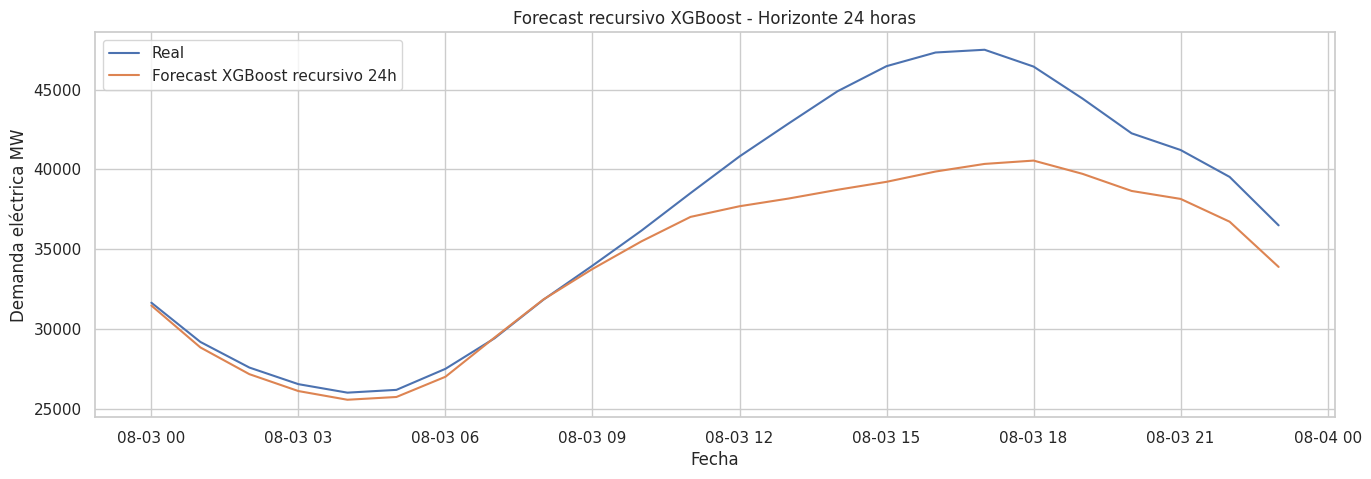

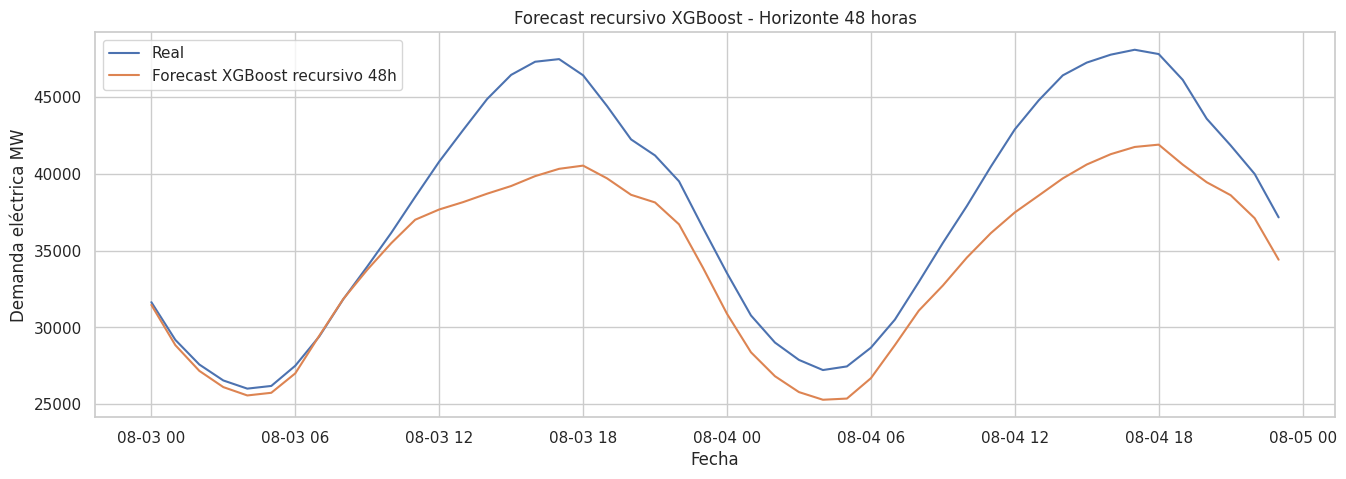

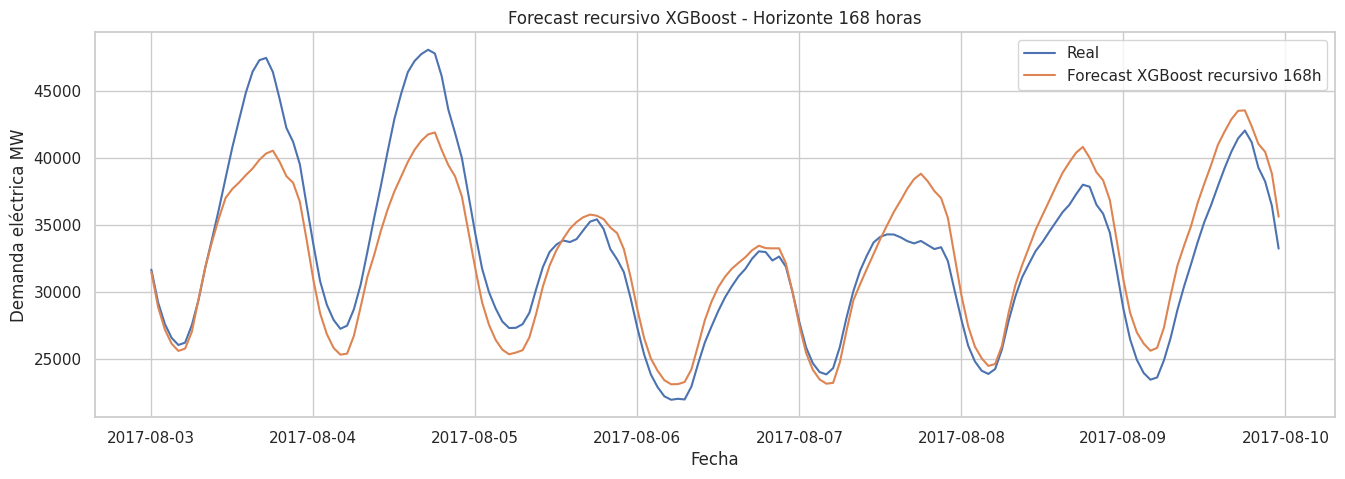

In [89]:
# ============================================================
# 87. VISUALIZACIÓN REAL VS FORECAST XGBOOST RECURSIVO
# ============================================================

for h in horizons:
    y_true_h = xgb_recursive_predictions[h]['y_true']
    y_pred_h = xgb_recursive_predictions[h]['y_pred']

    plt.figure(figsize=(16, 5))
    plt.plot(y_true_h.index, y_true_h, label='Real')
    plt.plot(y_pred_h.index, y_pred_h, label=f'Forecast XGBoost recursivo {h}h')

    plt.title(f'Forecast recursivo XGBoost - Horizonte {h} horas')
    plt.xlabel('Fecha')
    plt.ylabel('Demanda eléctrica MW')
    plt.legend()
    plt.grid(True)
    plt.show()

In [90]:
# ============================================================
# 88. EVALUACIÓN MULTI-ORIGIN DE XGBOOST RECURSIVO
# ============================================================

xgb_multi_origin_results = []

horizons = [24, 48, 168]
forecast_origins = pd.date_range(
    start=test.index.min(),
    end=test.index.max() - pd.Timedelta(hours=max(horizons)),
    freq='168h'
)

for origin in forecast_origins:
    history_available = df.loc[df.index < origin, 'PJME_MW'].copy()

    for h in horizons:
        y_pred_h = recursive_forecast(
            model=xgb_model,
            history_series=history_available,
            start_timestamp=origin,
            horizon_hours=h
        )

        y_true_h = df.loc[y_pred_h.index, 'PJME_MW']

        result_h = evaluate_forecast(
            y_true=y_true_h,
            y_pred=y_pred_h,
            model_name=f'XGBoost Recursive {h}h'
        )

        result_h['origin'] = origin
        result_h['horizon_hours'] = h
        xgb_multi_origin_results.append(result_h)

xgb_multi_origin_results_df = pd.DataFrame(xgb_multi_origin_results)
xgb_multi_origin_results_df.head()

,model,MAE,RMSE,MAPE_%,origin,horizon_hours
0,XGBoost Recursive 24h,"2,654.64","3,690.71",6.20,2017-08-03,24
1,XGBoost Recursive 48h,"3,235.99","3,961.38",7.87,2017-08-03,48
2,XGBoost Recursive 168h,"2,171.09","2,728.42",6.27,2017-08-03,168
3,XGBoost Recursive 24h,962.44,"1,187.97",2.75,2017-08-10,24
4,XGBoost Recursive 48h,700.68,921.45,2.03,2017-08-10,48


In [91]:
# ============================================================
# 89. RESUMEN MULTI-ORIGIN DE XGBOOST RECURSIVO
# ============================================================

xgb_recursive_multi_origin_summary = (
    xgb_multi_origin_results_df
    .groupby('horizon_hours')
    .agg(
        MAE_mean=('MAE', 'mean'),
        MAE_std=('MAE', 'std'),
        RMSE_mean=('RMSE', 'mean'),
        RMSE_std=('RMSE', 'std'),
        MAPE_mean=('MAPE_%', 'mean'),
        MAPE_std=('MAPE_%', 'std'),
        n_origins=('origin', 'count')
    )
    .reset_index()
)

cols_to_round = ['MAE_mean', 'MAE_std', 'RMSE_mean', 'RMSE_std', 'MAPE_mean', 'MAPE_std']
xgb_recursive_multi_origin_summary[cols_to_round] = (
    xgb_recursive_multi_origin_summary[cols_to_round].round(2)
)

xgb_recursive_multi_origin_summary

,horizon_hours,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPE_mean,MAPE_std,n_origins
0,24,"1,440.40","1,039.58","1,750.58","1,203.74",4.15,2.44,52
1,48,"1,851.23","1,222.88","2,237.13","1,375.82",5.49,3.05,52
2,168,"2,428.70","1,287.31","3,003.23","1,501.14",7.41,3.10,52


In [92]:
# ============================================================
# 90. COMPARACIÓN RF RECURSIVO VS XGBOOST RECURSIVO
# ============================================================

rf_recursive_summary_for_compare = multi_origin_summary.copy()
rf_recursive_summary_for_compare['model'] = 'Random Forest Recursive'

xgb_recursive_summary_for_compare = xgb_recursive_multi_origin_summary.copy()
xgb_recursive_summary_for_compare['model'] = 'XGBoost Recursive'

recursive_model_comparison = pd.concat([
    rf_recursive_summary_for_compare,
    xgb_recursive_summary_for_compare
], ignore_index=True)

recursive_model_comparison = recursive_model_comparison[[
    'model', 'horizon_hours', 'MAE_mean', 'RMSE_mean', 'MAPE_mean', 'MAPE_std', 'n_origins'
]]

recursive_model_comparison

,model,horizon_hours,MAE_mean,RMSE_mean,MAPE_mean,MAPE_std,n_origins
0,Random Forest Recursive,24,"1,472.60","1,803.52",4.34,2.61,52
1,Random Forest Recursive,48,"1,971.21","2,383.05",5.97,4.02,52
2,Random Forest Recursive,168,"2,519.59","3,090.34",7.80,4.56,52
3,XGBoost Recursive,24,"1,440.40","1,750.58",4.15,2.44,52
4,XGBoost Recursive,48,"1,851.23","2,237.13",5.49,3.05,52
5,XGBoost Recursive,168,"2,428.70","3,003.23",7.41,3.10,52


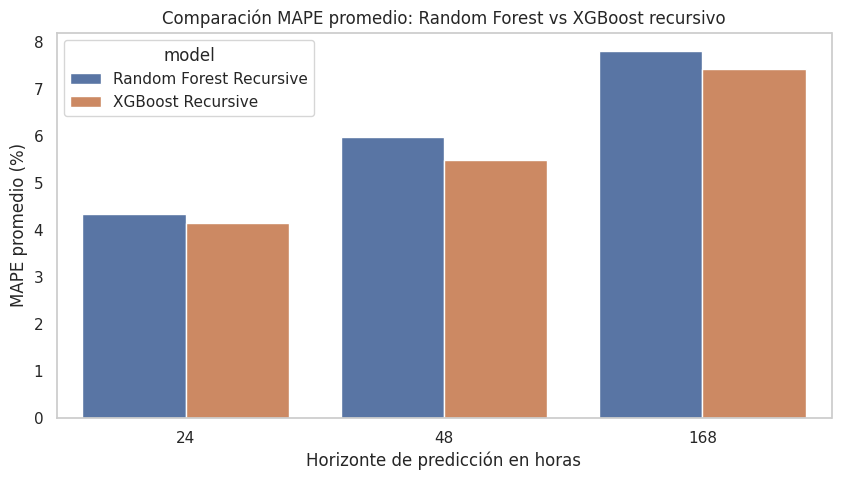

In [93]:
# ============================================================
# 91. GRÁFICO COMPARATIVO RF VS XGBOOST RECURSIVO
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(
    data=recursive_model_comparison,
    x='horizon_hours',
    y='MAPE_mean',
    hue='model'
)

plt.title('Comparación MAPE promedio: Random Forest vs XGBoost recursivo')
plt.xlabel('Horizonte de predicción en horas')
plt.ylabel('MAPE promedio (%)')
plt.grid(axis='y')
plt.show()

In [94]:
# ============================================================
# 92. ANÁLISIS DE PEAK DEMAND PARA XGBOOST RECURSIVO
# ============================================================

xgb_detail_rows = []

horizons = [24, 48, 168]
forecast_origins = pd.date_range(
    start=test.index.min(),
    end=test.index.max() - pd.Timedelta(hours=max(horizons)),
    freq='168h'
)

for origin in forecast_origins:
    history_available = df.loc[df.index < origin, 'PJME_MW'].copy()

    for h in horizons:
        pred_df = recursive_forecast_detailed(
            model=xgb_model,
            history_series=history_available,
            start_timestamp=origin,
            horizon_hours=h
        )

        pred_df['y_true'] = df.loc[pred_df.index, 'PJME_MW']
        pred_df['error'] = pred_df['y_true'] - pred_df['y_pred']
        pred_df['abs_error'] = pred_df['error'].abs()
        pred_df['pct_error'] = pred_df['abs_error'] / pred_df['y_true'] * 100
        pred_df['origin'] = origin
        pred_df['horizon_hours'] = h
        pred_df['is_peak_demand'] = np.where(pred_df['y_true'] >= peak_threshold, 1, 0)

        xgb_detail_rows.append(pred_df.reset_index())

xgb_recursive_detail_df = pd.concat(xgb_detail_rows, ignore_index=True)

xgb_peak_error_summary = (
    xgb_recursive_detail_df
    .groupby(['horizon_hours', 'is_peak_demand'])
    .agg(
        MAE=('abs_error', 'mean'),
        RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),
        MAPE=('pct_error', 'mean'),
        bias=('error', 'mean'),
        n_obs=('error', 'count')
    )
    .reset_index()
)

xgb_peak_error_summary[['MAE', 'RMSE', 'MAPE', 'bias']] = (
    xgb_peak_error_summary[['MAE', 'RMSE', 'MAPE', 'bias']].round(2)
)

xgb_peak_error_summary['segment'] = xgb_peak_error_summary['is_peak_demand'].map({
    0: 'No peak',
    1: 'Peak demand'
})

xgb_peak_error_summary['MAE_households_equivalent'] = (
    xgb_peak_error_summary['MAE'] * HOUSEHOLDS_PER_MW
).round(0)

xgb_peak_error_summary

,horizon_hours,is_peak_demand,MAE,RMSE,MAPE,bias,n_obs,segment,MAE_households_equivalent
0,24,0,"1,274.45","1,787.81",3.84,-34.96,1198,No peak,"3,058,680.00"
1,24,1,"5,416.52","5,948.04",11.48,"4,780.46",50,Peak demand,"12,999,648.00"
2,48,0,"1,688.41","2,335.76",5.20,88.14,2402,No peak,"4,052,184.00"
3,48,1,"6,011.61","6,540.21",12.81,"5,361.95",94,Peak demand,"14,427,864.00"
4,168,0,"2,271.39","3,076.18",7.17,488.17,8442,No peak,"5,451,336.00"
5,168,1,"6,945.85","7,871.25",14.51,"6,325.54",294,Peak demand,"16,670,040.00"


### Evaluación supervisada inicial de XGBoost

El modelo XGBoost fue evaluado inicialmente bajo el mismo esquema supervisado utilizado para los modelos anteriores.

| Modelo | MAE | RMSE | MAPE |
|---|---:|---:|---:|
| XGBoost Supervised | 298,20 | 401,01 | 0,94% |

Este resultado muestra que XGBoost mejora levemente el desempeño supervisado de Random Forest, que había obtenido un MAPE de 0,99%.

Sin embargo, esta evaluación todavía utiliza rezagos observados en el conjunto de prueba. Por lo tanto, debe ser interpretada como una comparación inicial, no como una prueba final de forecast operativo.

### Importancia de variables XGBoost

La importancia de variables muestra que XGBoost depende principalmente de los rezagos de la serie temporal.

| Variable | Importancia |
|---|---:|
| lag_1 | 0,75 |
| lag_24 | 0,13 |
| hour_cos | 0,03 |
| lag_168 | 0,03 |
| hour | 0,01 |
| rolling_24 | 0,01 |
| dayofweek | 0,01 |
| dayofweek_sin | 0,01 |
| hour_sin | 0,01 |
| month_cos | 0,01 |
| dayofweek_cos | 0,00 |
| month | 0,00 |
| month_sin | 0,00 |
| weekofyear | 0,00 |
| dayofyear | 0,00 |

La variable más importante es `lag_1`, pero a diferencia de Random Forest, XGBoost también asigna una relevancia mayor a `lag_24` y `lag_168`. Esto sugiere que el modelo está aprovechando señales de corto plazo, ciclo diario y ciclo semanal.

### Forecast recursivo inicial de XGBoost

En una primera prueba recursiva desde el inicio del conjunto de test, XGBoost obtuvo los siguientes resultados:

| Horizonte | MAE | RMSE | MAPE |
|---:|---:|---:|---:|
| 24 h | 2.654,64 | 3.690,71 | 6,20% |
| 48 h | 3.235,99 | 3.961,38 | 7,87% |
| 168 h | 2.171,09 | 2.728,42 | 6,27% |

Estos resultados corresponden a una única fecha de origen, por lo que deben interpretarse solo como una primera prueba visual y operacional. La evaluación más robusta corresponde al análisis multi-origin.

### Resumen multi-origin de XGBoost recursivo

El análisis multi-origin evalúa el modelo desde 52 puntos de inicio distintos, lo que permite obtener una medición más robusta del desempeño por horizonte.

| Horizonte | MAE promedio | MAE std | RMSE promedio | RMSE std | MAPE promedio | MAPE std | N orígenes |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 24 h | 1.440,40 | 1.039,58 | 1.750,58 | 1.203,74 | 4,15% | 2,44 | 52 |
| 48 h | 1.851,23 | 1.222,88 | 2.237,13 | 1.375,82 | 5,49% | 3,05 | 52 |
| 168 h | 2.428,70 | 1.287,31 | 3.003,23 | 1.501,14 | 7,41% | 3,10 | 52 |

La tendencia es similar a la observada con Random Forest: el error aumenta a medida que crece el horizonte de predicción. Sin embargo, XGBoost reduce el MAPE promedio en los tres horizontes.

### Comparación Random Forest recursivo vs XGBoost recursivo

La comparación directa muestra que XGBoost recursivo mejora a Random Forest recursivo en los tres horizontes evaluados.

| Modelo | Horizonte | MAE promedio | RMSE promedio | MAPE promedio | MAPE std | N orígenes |
|---|---:|---:|---:|---:|---:|---:|
| Random Forest Recursive | 24 h | 1.472,60 | 1.803,52 | 4,34% | 2,61 | 52 |
| Random Forest Recursive | 48 h | 1.971,21 | 2.383,05 | 5,97% | 4,02 | 52 |
| Random Forest Recursive | 168 h | 2.519,59 | 3.090,34 | 7,80% | 4,56 | 52 |
| XGBoost Recursive | 24 h | 1.440,40 | 1.750,58 | 4,15% | 2,44 | 52 |
| XGBoost Recursive | 48 h | 1.851,23 | 2.237,13 | 5,49% | 3,05 | 52 |
| XGBoost Recursive | 168 h | 2.428,70 | 3.003,23 | 7,41% | 3,10 | 52 |

La mejora es moderada, pero consistente. XGBoost reduce el MAPE promedio en 24, 48 y 168 horas, y también presenta menor dispersión del error, especialmente en el horizonte semanal.

### Análisis peak demand para XGBoost recursivo

El desempeño de XGBoost recursivo también fue evaluado separando horas normales y eventos de peak demand.

| Horizonte | Segmento | MAE | RMSE | MAPE | Bias | N obs | Hogares equivalentes MAE |
|---:|---|---:|---:|---:|---:|---:|---:|
| 24 h | No peak | 1.274,45 | 1.787,81 | 3,84% | -34,96 | 1.198 | 3.058.680 |
| 24 h | Peak demand | 5.416,52 | 5.948,04 | 11,48% | 4.780,46 | 50 | 12.999.648 |
| 48 h | No peak | 1.688,41 | 2.335,76 | 5,20% | 88,14 | 2.402 | 4.052.184 |
| 48 h | Peak demand | 6.011,61 | 6.540,21 | 12,81% | 5.361,95 | 94 | 14.427.864 |
| 168 h | No peak | 2.271,39 | 3.076,18 | 7,17% | 488,17 | 8.442 | 5.451.336 |
| 168 h | Peak demand | 6.945,85 | 7.871,25 | 14,51% | 6.325,54 | 294 | 16.670.040 |

El modelo mantiene un problema relevante en eventos de alta demanda. En horas peak, el sesgo es positivo en todos los horizontes, lo que indica que XGBoost recursivo también subestima la demanda durante los períodos más críticos.

### Conclusiones de XGBoost recursivo

XGBoost recursivo mejora a Random Forest recursivo en los tres horizontes evaluados.

En el horizonte de 24 horas, el MAPE promedio baja de 4,34% a 4,15%. En 48 horas, baja de 5,97% a 5,49%. En 168 horas, baja de 7,80% a 7,41%.

La mejora no es radical, pero sí es consistente. Esto permite considerar a XGBoost recursivo como un nuevo benchmark técnico para el forecast multi-step.

Además, XGBoost muestra una distribución de importancia de variables más equilibrada que Random Forest. Aunque `lag_1` sigue siendo la variable dominante, también utiliza `lag_24` y `lag_168`, lo que sugiere que incorpora mejor señales de ciclo diario y semanal.

Sin embargo, el análisis de peak demand muestra que XGBoost recursivo todavía presenta una limitación importante: subestima la demanda en eventos de alta exigencia.

En el horizonte semanal de 168 horas, el MAPE en horas peak alcanza 14,51%, con un sesgo positivo de 6.325,54 MW. Esto significa que, en promedio, el valor real fue mayor que la predicción durante eventos peak.

Por lo tanto, XGBoost recursivo mejora el benchmark, pero aún no resuelve completamente el problema operativo más crítico: anticipar correctamente los peaks de demanda.

### Inferencia técnica

XGBoost recursivo muestra una mejora consistente sobre Random Forest recursivo, lo que indica que el algoritmo de gradient boosting captura mejor algunas relaciones no lineales entre rezagos, variables temporales y demanda eléctrica.

La importancia de variables muestra que `lag_1` sigue siendo la señal principal, con una importancia de 0,75. Sin embargo, `lag_24` alcanza una importancia de 0,13 y `lag_168` también aparece dentro de las variables relevantes. Esto sugiere que XGBoost aprovecha mejor la memoria diaria y semanal de la serie.

A pesar de esta mejora, el modelo sigue enfrentando el problema estructural del enfoque recursivo: a medida que avanza el horizonte, las predicciones previas reemplazan valores reales y el error puede propagarse.

La mejora de XGBoost respecto de Random Forest es suficiente para convertirlo en el nuevo benchmark recursivo, pero no elimina la necesidad de probar un enfoque directo por horizonte.

El análisis de peak demand refuerza esta conclusión. Aunque XGBoost mejora el MAPE general, todavía subestima los peaks de demanda, especialmente en horizontes largos.

### Lectura ejecutiva de XGBoost recursivo

XGBoost mejora el desempeño de Random Forest en forecast multi-step, por lo que representa un avance técnico dentro del proyecto.

La mejora es consistente en 24, 48 y 168 horas, lo que indica que el modelo aporta valor como nuevo benchmark.

Sin embargo, el modelo todavía se equivoca más durante eventos de alta demanda. En términos simples: predice mejor que Random Forest en promedio, pero todavía no anticipa suficientemente bien los momentos más críticos del sistema.

Desde una perspectiva de negocio, XGBoost recursivo puede ser una mejor base para monitoreo y planificación táctica, pero aún requiere mejoras antes de ser usado para planificación semanal crítica o gestión de peak demand.

### Lectura en hogares equivalentes

En el horizonte semanal de 168 horas, XGBoost recursivo obtiene un MAE promedio de 2.428,70 MW.

Usando la equivalencia del proyecto, esto representa aproximadamente el consumo horario promedio de 5.828.880 hogares equivalentes.

En eventos de peak demand del horizonte semanal, el MAE alcanza 6.945,85 MW, equivalente aproximadamente al consumo horario promedio de 16.670.040 hogares equivalentes.

Esta diferencia muestra que el modelo tiene un desempeño razonable en promedio, pero su error aumenta fuertemente en los momentos de mayor demanda.

### Cierre de XGBoost recursivo

XGBoost recursivo mejora a Random Forest recursivo y queda definido como nuevo benchmark técnico para la etapa multi-step.

Aun así, el modelo mantiene dos limitaciones relevantes:

1. El error aumenta a medida que crece el horizonte de predicción.
2. El modelo subestima la demanda en eventos de peak demand.

Por esta razón, el siguiente paso será evaluar XGBoost directo por horizonte, con el objetivo de reducir la acumulación de error propia del enfoque recursivo.

## 37. XGBoost directo por horizonte

Además del enfoque recursivo, se evaluará un enfoque directo por horizonte.

En este caso, el modelo se entrena para predecir directamente un horizonte específico, por ejemplo 24, 48 o 168 horas hacia adelante.

Este enfoque busca reducir la acumulación de error, ya que el modelo no necesita usar sus propias predicciones intermedias como insumo.

In [95]:
# ============================================================
# 93. CREACIÓN DE TARGETS DESPLAZADOS POR HORIZONTE
# ============================================================

# En el enfoque directo, cada modelo aprende a predecir y(t+h)
# usando las variables disponibles en el tiempo t.

# Importante:
# El error KeyError aparece cuando se intenta usar df.copy(),
# porque df contiene la serie original, pero no necesariamente contiene
# todas las variables de features como hour_sin, hour_cos, lag_1,
# lag_24, rolling_24, rolling_168, etc.

# Por eso, primero reconstruimos un dataframe base que contenga:
# 1. La variable objetivo original PJME_MW.
# 2. Todas las variables predictoras ya creadas en X_train y X_test.

horizons = [24, 48, 168]
direct_datasets = {}

target_col = 'PJME_MW'

# Unimos las features ya usadas en los modelos anteriores.
features_all = pd.concat([X_train[features], X_test[features]], axis=0).sort_index()

# Construimos base para modelos directos.
direct_base_df = df[[target_col]].join(features_all, how='inner')

print("Dataset base para modelos directos:", direct_base_df.shape)
print("Columnas disponibles:")
print(direct_base_df.columns.tolist())

for h in horizons:
    temp_df = direct_base_df.copy()
    temp_df[f'target_h_{h}'] = temp_df[target_col].shift(-h)

    # Se eliminan filas sin target futuro y filas con NA en features.
    temp_df = temp_df.dropna(subset=features + [f'target_h_{h}'])

    direct_datasets[h] = temp_df

    print(f"Horizonte {h}h - dataset directo: {temp_df.shape}")

Dataset base para modelos directos: (145224, 20)
Columnas disponibles:
['PJME_MW', 'hour', 'dayofweek', 'dayofmonth', 'dayofyear', 'weekofyear', 'month', 'quarter', 'year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'lag_1', 'lag_24', 'lag_168', 'rolling_24', 'rolling_168']
Horizonte 24h - dataset directo: (145200, 21)
Horizonte 48h - dataset directo: (145176, 21)
Horizonte 168h - dataset directo: (145056, 21)


In [96]:
# ============================================================
# 94. FUNCIÓN PARA ENTRENAR XGBOOST DIRECTO POR HORIZONTE
# ============================================================

def train_xgb_direct_horizon(data, horizon, features, test_start):
    """
    Entrena un modelo XGBoost directo para un horizonte específico.

    data: dataframe con features y target_h_{horizon}
    horizon: horizonte de predicción en horas
    features: lista de variables predictoras
    test_start: fecha de inicio del conjunto de test
    """

    target_h = f'target_h_{horizon}'

    train_h = data.loc[data.index < test_start].copy()
    test_h = data.loc[data.index >= test_start].copy()

    X_train_h = train_h[features]
    y_train_h = train_h[target_h]

    X_test_h = test_h[features]
    y_test_h = test_h[target_h]

    model_h = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    model_h.fit(X_train_h, y_train_h)

    y_pred_h = model_h.predict(X_test_h)

    results_h = evaluate_forecast(
        y_true=y_test_h,
        y_pred=y_pred_h,
        model_name=f'XGBoost Direct h+{horizon}'
    )

    results_h['horizon_hours'] = horizon

    pred_df_h = pd.DataFrame({
        'timestamp_origin': X_test_h.index,
        'timestamp_target': X_test_h.index + pd.Timedelta(hours=horizon),
        'y_true': y_test_h.values,
        'y_pred': y_pred_h
    })

    pred_df_h['error'] = pred_df_h['y_true'] - pred_df_h['y_pred']
    pred_df_h['abs_error'] = pred_df_h['error'].abs()
    pred_df_h['pct_error'] = pred_df_h['abs_error'] / pred_df_h['y_true'] * 100
    pred_df_h['horizon_hours'] = horizon

    return model_h, results_h, pred_df_h

In [97]:
# ============================================================
# 95. ENTRENAMIENTO DE XGBOOST DIRECTO PARA 24, 48 Y 168 HORAS
# ============================================================

xgb_direct_models = {}
xgb_direct_results = []
xgb_direct_predictions = []

test_start = test.index.min()

for h in horizons:
    model_h, results_h, pred_df_h = train_xgb_direct_horizon(
        data=direct_datasets[h],
        horizon=h,
        features=features,
        test_start=test_start
    )

    xgb_direct_models[h] = model_h
    xgb_direct_results.append(results_h)
    xgb_direct_predictions.append(pred_df_h)

xgb_direct_results_df = pd.DataFrame(xgb_direct_results)
xgb_direct_predictions_df = pd.concat(xgb_direct_predictions, ignore_index=True)

xgb_direct_results_df

,model,MAE,RMSE,MAPE_%,horizon_hours
0,XGBoost Direct h+24,"1,937.22","2,673.50",6.01,24
1,XGBoost Direct h+48,"2,614.35","3,555.85",8.15,48
2,XGBoost Direct h+168,"2,889.81","4,027.81",8.83,168


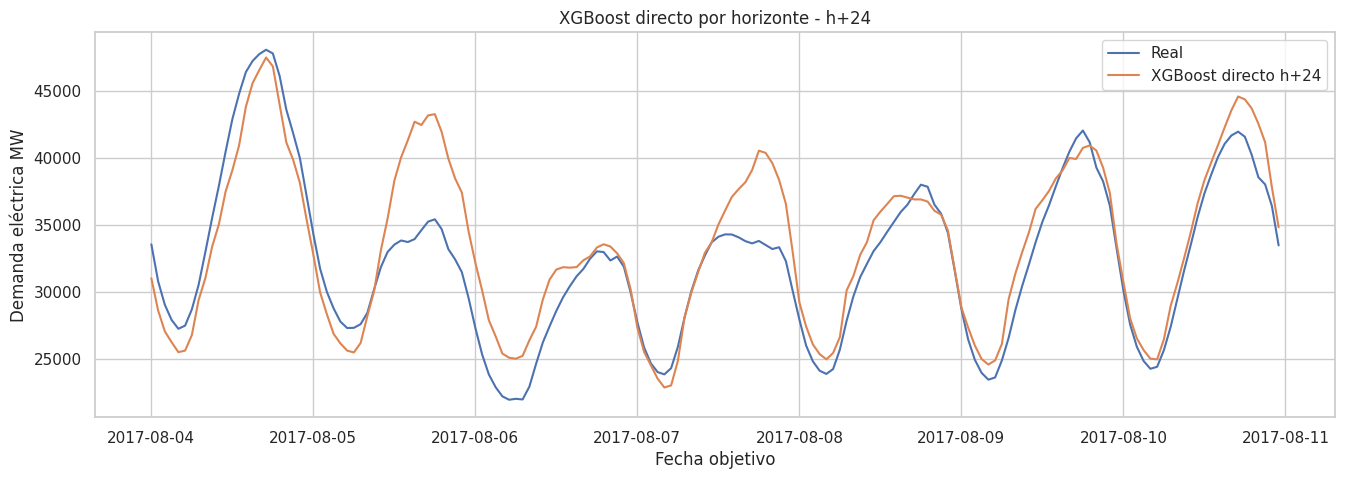

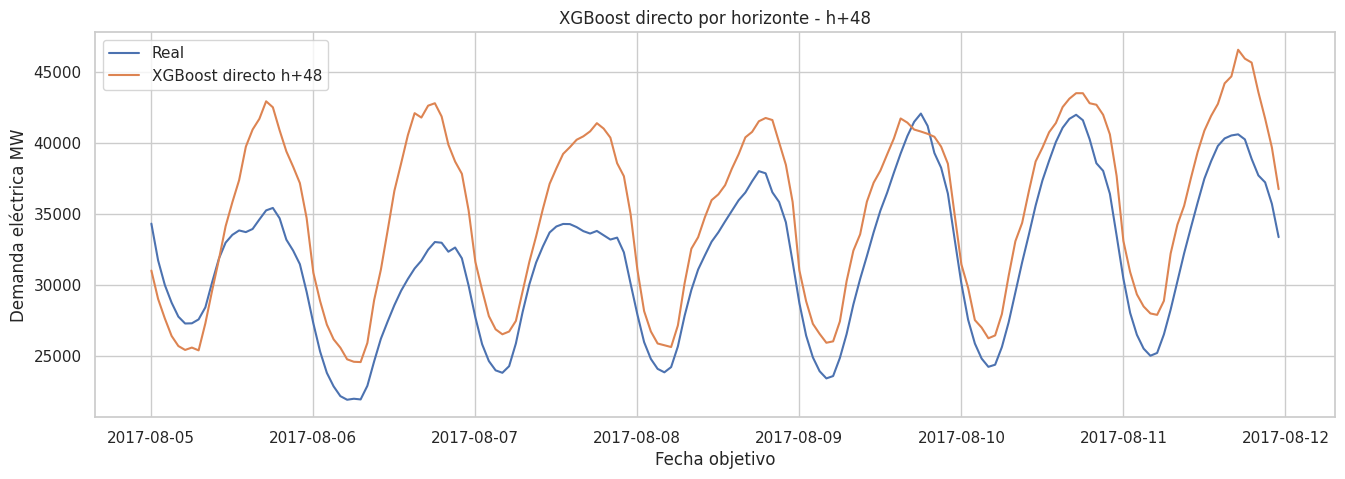

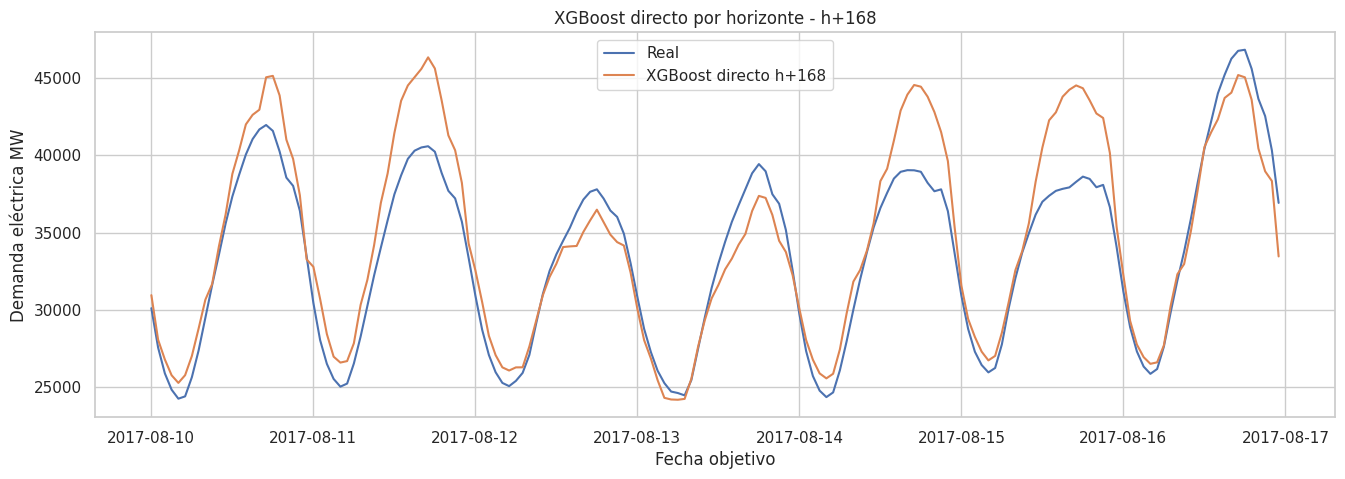

In [98]:
# ============================================================
# 96. VISUALIZACIÓN XGBOOST DIRECTO POR HORIZONTE
# ============================================================

for h in horizons:
    temp_plot = xgb_direct_predictions_df[
        xgb_direct_predictions_df['horizon_hours'] == h
    ].copy()

    # Se visualizan solo las primeras 168 predicciones para mantener legibilidad.
    temp_plot = temp_plot.sort_values('timestamp_target').head(168)

    plt.figure(figsize=(16, 5))
    plt.plot(temp_plot['timestamp_target'], temp_plot['y_true'], label='Real')
    plt.plot(temp_plot['timestamp_target'], temp_plot['y_pred'], label=f'XGBoost directo h+{h}')

    plt.title(f'XGBoost directo por horizonte - h+{h}')
    plt.xlabel('Fecha objetivo')
    plt.ylabel('Demanda eléctrica MW')
    plt.legend()
    plt.grid(True)
    plt.show()

In [99]:
# ============================================================
# 97. EVALUACIÓN PEAK DEMAND PARA XGBOOST DIRECTO
# ============================================================

xgb_direct_predictions_df['is_peak_demand'] = np.where(
    xgb_direct_predictions_df['y_true'] >= peak_threshold,
    1,
    0
)

xgb_direct_peak_summary = (
    xgb_direct_predictions_df
    .groupby(['horizon_hours', 'is_peak_demand'])
    .agg(
        MAE=('abs_error', 'mean'),
        RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),
        MAPE=('pct_error', 'mean'),
        bias=('error', 'mean'),
        n_obs=('error', 'count')
    )
    .reset_index()
)

xgb_direct_peak_summary[['MAE', 'RMSE', 'MAPE', 'bias']] = (
    xgb_direct_peak_summary[['MAE', 'RMSE', 'MAPE', 'bias']].round(2)
)

xgb_direct_peak_summary['segment'] = xgb_direct_peak_summary['is_peak_demand'].map({
    0: 'No peak',
    1: 'Peak demand'
})

xgb_direct_peak_summary['MAE_households_equivalent'] = (
    xgb_direct_peak_summary['MAE'] * HOUSEHOLDS_PER_MW
).round(0)

xgb_direct_peak_summary

,horizon_hours,is_peak_demand,MAE,RMSE,MAPE,bias,n_obs,segment,MAE_households_equivalent
0,24,0,"1,847.23","2,538.97",5.89,104.12,8442,No peak,"4,433,352.00"
1,24,1,"4,512.58","5,216.81",9.47,"3,753.94",295,Peak demand,"10,830,192.00"
2,48,0,"2,487.88","3,363.06",7.97,27.75,8425,No peak,"5,970,912.00"
3,48,1,"6,314.28","7,187.83",13.25,"5,811.74",288,Peak demand,"15,154,272.00"
4,168,0,"2,721.73","3,756.74",8.58,533.60,8305,No peak,"6,532,152.00"
5,168,1,"7,736.82","8,779.12",16.21,"7,056.40",288,Peak demand,"18,568,368.00"


In [100]:
# ============================================================
# 98. COMPARACIÓN MODELOS CANDIDATOS
# ============================================================

# Random Forest benchmark
rf_compare = multi_origin_summary.copy()
rf_compare['model'] = 'Random Forest Recursive'
rf_compare = rf_compare[['model', 'horizon_hours', 'MAE_mean', 'RMSE_mean', 'MAPE_mean', 'MAPE_std', 'n_origins']]

# XGBoost recursivo
xgb_rec_compare = xgb_recursive_multi_origin_summary.copy()
xgb_rec_compare['model'] = 'XGBoost Recursive'
xgb_rec_compare = xgb_rec_compare[['model', 'horizon_hours', 'MAE_mean', 'RMSE_mean', 'MAPE_mean', 'MAPE_std', 'n_origins']]

# XGBoost directo
xgb_direct_compare = xgb_direct_results_df.copy()
xgb_direct_compare = xgb_direct_compare.rename(columns={
    'MAE': 'MAE_mean',
    'RMSE': 'RMSE_mean',
    'MAPE_%': 'MAPE_mean'
})
xgb_direct_compare['MAPE_std'] = np.nan
xgb_direct_compare['n_origins'] = np.nan
xgb_direct_compare['model'] = 'XGBoost Direct'
xgb_direct_compare = xgb_direct_compare[['model', 'horizon_hours', 'MAE_mean', 'RMSE_mean', 'MAPE_mean', 'MAPE_std', 'n_origins']]

candidate_model_comparison = pd.concat([
    rf_compare,
    xgb_rec_compare,
    xgb_direct_compare
], ignore_index=True)

candidate_model_comparison[['MAE_mean', 'RMSE_mean', 'MAPE_mean']] = (
    candidate_model_comparison[['MAE_mean', 'RMSE_mean', 'MAPE_mean']].round(2)
)

candidate_model_comparison

,model,horizon_hours,MAE_mean,RMSE_mean,MAPE_mean,MAPE_std,n_origins
0,Random Forest Recursive,24,"1,472.60","1,803.52",4.34,2.61,52.00
1,Random Forest Recursive,48,"1,971.21","2,383.05",5.97,4.02,52.00
2,Random Forest Recursive,168,"2,519.59","3,090.34",7.80,4.56,52.00
3,XGBoost Recursive,24,"1,440.40","1,750.58",4.15,2.44,52.00
4,XGBoost Recursive,48,"1,851.23","2,237.13",5.49,3.05,52.00
5,XGBoost Recursive,168,"2,428.70","3,003.23",7.41,3.10,52.00
6,XGBoost Direct,24,"1,937.22","2,673.50",6.01,NaN,NaN
7,XGBoost Direct,48,"2,614.35","3,555.85",8.15,NaN,NaN
8,XGBoost Direct,168,"2,889.81","4,027.81",8.83,NaN,NaN


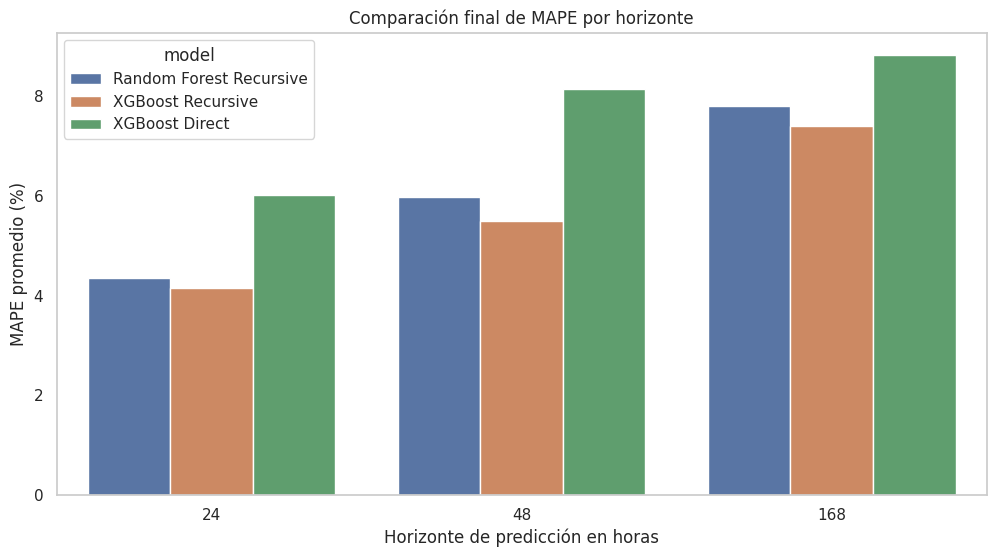

In [101]:
# ============================================================
# 99. GRÁFICO COMPARATIVO FINAL DE MODELOS CANDIDATOS
# ============================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    data=candidate_model_comparison,
    x='horizon_hours',
    y='MAPE_mean',
    hue='model'
)

plt.title('Comparación final de MAPE por horizonte')
plt.xlabel('Horizonte de predicción en horas')
plt.ylabel('MAPE promedio (%)')
plt.grid(axis='y')
plt.show()

In [102]:
# ============================================================
# 100. IMPORTACIÓN DE MODELO MULTI-OUTPUT
# ============================================================

from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

print("MultiOutputRegressor y XGBoost importados correctamente")

MultiOutputRegressor y XGBoost importados correctamente


In [103]:
# ============================================================
# 101. CREACIÓN DE TARGETS MULTI-OUTPUT
# ============================================================

# El objetivo es construir una matriz Y con tres columnas:
# - target_h_24
# - target_h_48
# - target_h_168

# Cada fila usa las variables disponibles en el tiempo t
# para predecir la demanda en t+24, t+48 y t+168.

multi_output_horizons = [24, 48, 168]
target_col = 'PJME_MW'

# Se reutiliza la lógica corregida del enfoque directo:
# unimos la serie original con las features ya creadas en X_train y X_test.
features_all = pd.concat([X_train[features], X_test[features]], axis=0).sort_index()
multi_output_base_df = df[[target_col]].join(features_all, how='inner')

for h in multi_output_horizons:
    multi_output_base_df[f'target_h_{h}'] = multi_output_base_df[target_col].shift(-h)

multi_output_target_cols = [f'target_h_{h}' for h in multi_output_horizons]

multi_output_df = multi_output_base_df.dropna(subset=features + multi_output_target_cols).copy()

print("Dataset multi-output:", multi_output_df.shape)
print("Targets multi-output:", multi_output_target_cols)

multi_output_df.head()

Dataset multi-output: (145056, 23)
Targets multi-output: ['target_h_24', 'target_h_48', 'target_h_168']


,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos,lag_1,lag_24,lag_168,rolling_24,rolling_168,target_h_24,target_h_48,target_h_168
Datetime,,,,,,,,,,,,,,,,,,,,,,,
2002-01-08 01:00:00,"29,445.00",1,1,8,8,2,1,1,2002,0.26,0.97,0.50,0.87,0.78,0.62,"31,187.00","26,862.00","30,393.00","33,452.58","32,519.51","29,082.00","27,144.00","25,643.00"
2002-01-08 02:00:00,"28,670.00",2,1,8,8,2,1,1,2002,0.50,0.87,0.50,0.87,0.78,0.62,"29,445.00","25,976.00","29,265.00","33,560.21","32,513.87","28,154.00","26,163.00","24,967.00"
2002-01-08 03:00:00,"28,375.00",3,1,8,8,2,1,1,2002,0.71,0.71,0.50,0.87,0.78,0.62,"28,670.00","25,641.00","28,357.00","33,672.46","32,510.33","27,829.00","25,752.00","24,715.00"
2002-01-08 04:00:00,"28,542.00",4,1,8,8,2,1,1,2002,0.87,0.50,0.50,0.87,0.78,0.62,"28,375.00","25,666.00","27,899.00","33,786.38","32,510.43","27,759.00","25,629.00","24,826.00"
2002-01-08 05:00:00,"29,261.00",5,1,8,8,2,1,1,2002,0.97,0.26,0.50,0.87,0.78,0.62,"28,542.00","26,328.00","28,057.00","33,906.21","32,514.26","28,308.00","26,257.00","25,630.00"


In [104]:
# ============================================================
# 102. SEPARACIÓN TEMPORAL TRAIN/TEST PARA MULTI-OUTPUT
# ============================================================

test_start = test.index.min()

multi_train = multi_output_df.loc[multi_output_df.index < test_start].copy()
multi_test = multi_output_df.loc[multi_output_df.index >= test_start].copy()

X_train_multi = multi_train[features]
Y_train_multi = multi_train[multi_output_target_cols]

X_test_multi = multi_test[features]
Y_test_multi = multi_test[multi_output_target_cols]

print("X_train_multi:", X_train_multi.shape)
print("Y_train_multi:", Y_train_multi.shape)
print("X_test_multi:", X_test_multi.shape)
print("Y_test_multi:", Y_test_multi.shape)

X_train_multi: (136463, 19)
Y_train_multi: (136463, 3)
X_test_multi: (8593, 19)
Y_test_multi: (8593, 3)


In [105]:
# ============================================================
# 103. ENTRENAMIENTO DE XGBOOST MULTI-OUTPUT
# ============================================================

base_xgb_multi = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_multi_output_model = MultiOutputRegressor(base_xgb_multi)

xgb_multi_output_model.fit(X_train_multi, Y_train_multi)

print("Modelo XGBoost multi-output entrenado correctamente")

Modelo XGBoost multi-output entrenado correctamente


In [106]:
# ============================================================
# 104. PREDICCIÓN MULTI-OUTPUT
# ============================================================

Y_pred_multi = xgb_multi_output_model.predict(X_test_multi)

Y_pred_multi_df = pd.DataFrame(
    Y_pred_multi,
    index=X_test_multi.index,
    columns=[f'pred_h_{h}' for h in multi_output_horizons]
)

Y_pred_multi_df.head()

,pred_h_24,pred_h_48,pred_h_168
Datetime,,,
2017-08-03 00:00:00,"30,999.16","31,005.14","30,940.95"
2017-08-03 01:00:00,"28,594.52","29,006.07","28,049.57"
2017-08-03 02:00:00,"27,028.42","27,630.58","26,770.66"
2017-08-03 03:00:00,"26,218.49","26,404.27","25,748.69"
2017-08-03 04:00:00,"25,474.49","25,696.02","25,254.02"


In [107]:
# ============================================================
# 105. EVALUACIÓN GLOBAL DEL MODELO MULTI-OUTPUT POR HORIZONTE
# ============================================================

multi_output_results = []
multi_output_predictions = []

for h in multi_output_horizons:
    target_h = f'target_h_{h}'
    pred_h = f'pred_h_{h}'

    y_true_h = Y_test_multi[target_h]
    y_pred_h = Y_pred_multi_df[pred_h]

    result_h = evaluate_forecast(
        y_true=y_true_h,
        y_pred=y_pred_h,
        model_name=f'XGBoost MultiOutput h+{h}'
    )

    result_h['horizon_hours'] = h
    multi_output_results.append(result_h)

    pred_df_h = pd.DataFrame({
        'timestamp_origin': X_test_multi.index,
        'timestamp_target': X_test_multi.index + pd.Timedelta(hours=h),
        'y_true': y_true_h.values,
        'y_pred': y_pred_h.values,
        'horizon_hours': h
    })

    pred_df_h['error'] = pred_df_h['y_true'] - pred_df_h['y_pred']
    pred_df_h['abs_error'] = pred_df_h['error'].abs()
    pred_df_h['pct_error'] = pred_df_h['abs_error'] / pred_df_h['y_true'] * 100

    multi_output_predictions.append(pred_df_h)

xgb_multi_output_results_df = pd.DataFrame(multi_output_results)
xgb_multi_output_predictions_df = pd.concat(multi_output_predictions, ignore_index=True)

xgb_multi_output_results_df

,model,MAE,RMSE,MAPE_%,horizon_hours
0,XGBoost MultiOutput h+24,"1,934.07","2,670.78",6.01,24
1,XGBoost MultiOutput h+48,"2,609.20","3,551.91",8.15,48
2,XGBoost MultiOutput h+168,"2,889.81","4,027.81",8.83,168


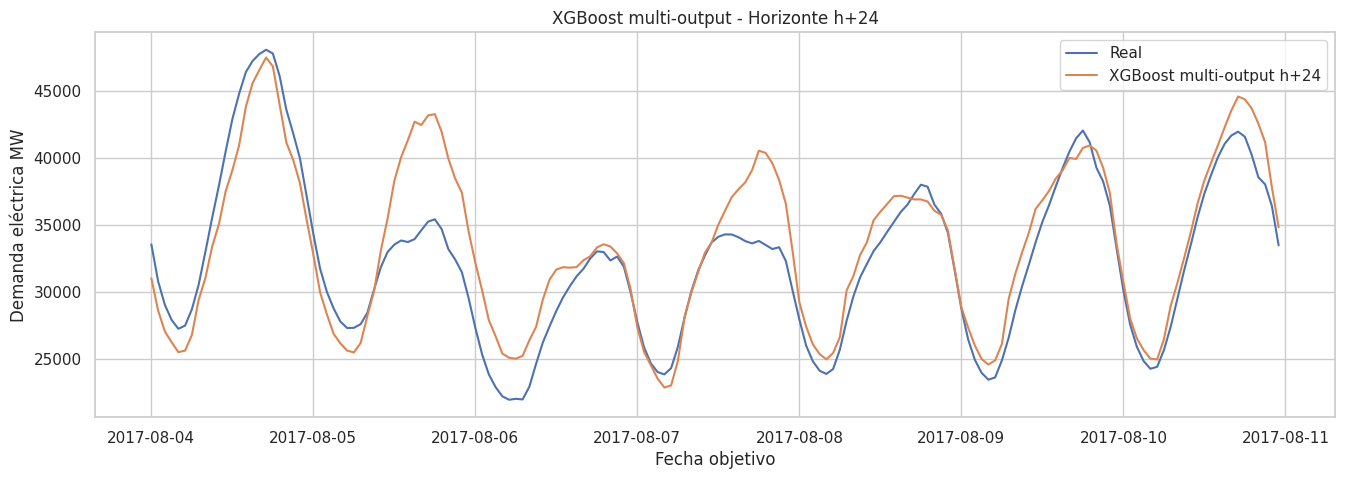

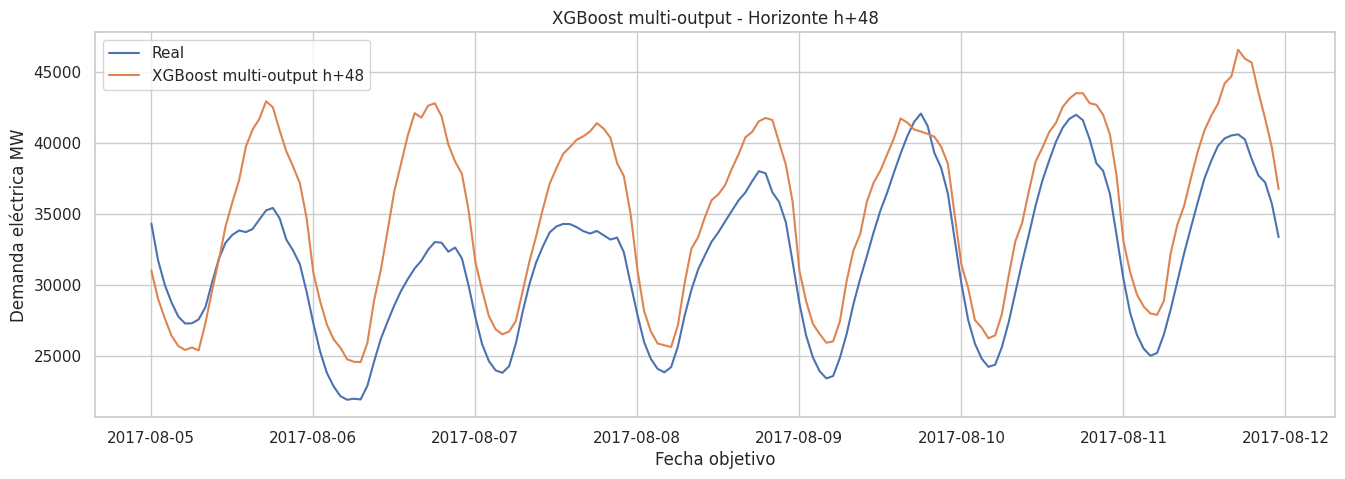

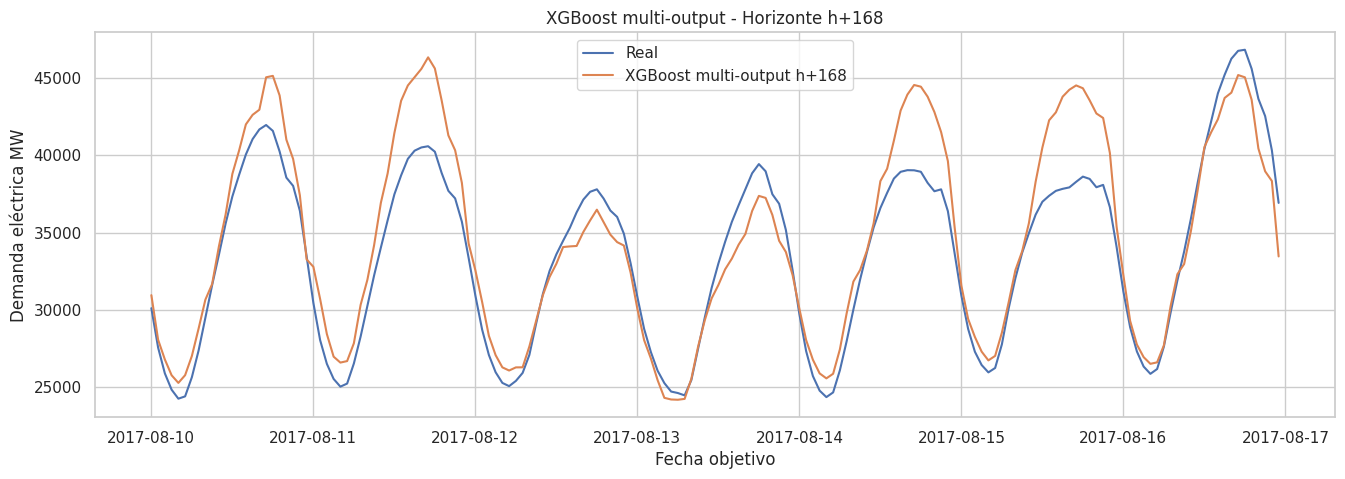

In [108]:
# ============================================================
# 106. VISUALIZACIÓN MULTI-OUTPUT POR HORIZONTE
# ============================================================

for h in multi_output_horizons:
    temp_plot = xgb_multi_output_predictions_df[
        xgb_multi_output_predictions_df['horizon_hours'] == h
    ].copy()

    temp_plot = temp_plot.sort_values('timestamp_target').head(168)

    plt.figure(figsize=(16, 5))
    plt.plot(temp_plot['timestamp_target'], temp_plot['y_true'], label='Real')
    plt.plot(temp_plot['timestamp_target'], temp_plot['y_pred'], label=f'XGBoost multi-output h+{h}')

    plt.title(f'XGBoost multi-output - Horizonte h+{h}')
    plt.xlabel('Fecha objetivo')
    plt.ylabel('Demanda eléctrica MW')
    plt.legend()
    plt.grid(True)
    plt.show()

In [109]:
# ============================================================
# 107. EVALUACIÓN PEAK DEMAND PARA XGBOOST MULTI-OUTPUT
# ============================================================

xgb_multi_output_predictions_df['is_peak_demand'] = np.where(
    xgb_multi_output_predictions_df['y_true'] >= peak_threshold,
    1,
    0
)

xgb_multi_output_peak_summary = (
    xgb_multi_output_predictions_df
    .groupby(['horizon_hours', 'is_peak_demand'])
    .agg(
        MAE=('abs_error', 'mean'),
        RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),
        MAPE=('pct_error', 'mean'),
        bias=('error', 'mean'),
        n_obs=('error', 'count')
    )
    .reset_index()
)

xgb_multi_output_peak_summary[['MAE', 'RMSE', 'MAPE', 'bias']] = (
    xgb_multi_output_peak_summary[['MAE', 'RMSE', 'MAPE', 'bias']].round(2)
)

xgb_multi_output_peak_summary['segment'] = xgb_multi_output_peak_summary['is_peak_demand'].map({
    0: 'No peak',
    1: 'Peak demand'
})

xgb_multi_output_peak_summary['MAE_households_equivalent'] = (
    xgb_multi_output_peak_summary['MAE'] * HOUSEHOLDS_PER_MW
).round(0)

xgb_multi_output_peak_summary

,horizon_hours,is_peak_demand,MAE,RMSE,MAPE,bias,n_obs,segment,MAE_households_equivalent
0,24,0,"1,846.77","2,540.69",5.89,95.50,8313,No peak,"4,432,248.00"
1,24,1,"4,526.17","5,221.14",9.50,"3,770.48",280,Peak demand,"10,862,808.00"
2,48,0,"2,489.54","3,368.59",7.99,12.77,8320,No peak,"5,974,896.00"
3,48,1,"6,255.93","7,161.05",13.12,"5,725.77",273,Peak demand,"15,014,232.00"
4,168,0,"2,721.73","3,756.74",8.58,533.60,8305,No peak,"6,532,152.00"
5,168,1,"7,736.82","8,779.12",16.21,"7,056.40",288,Peak demand,"18,568,368.00"


In [110]:
# ============================================================
# 108. COMPARACIÓN FINAL INCLUYENDO MULTI-OUTPUT
# ============================================================

# Random Forest benchmark
rf_compare = multi_origin_summary.copy()
rf_compare['model'] = 'Random Forest Recursive'
rf_compare = rf_compare[['model', 'horizon_hours', 'MAE_mean', 'RMSE_mean', 'MAPE_mean', 'MAPE_std', 'n_origins']]

# XGBoost recursivo
xgb_rec_compare = xgb_recursive_multi_origin_summary.copy()
xgb_rec_compare['model'] = 'XGBoost Recursive'
xgb_rec_compare = xgb_rec_compare[['model', 'horizon_hours', 'MAE_mean', 'RMSE_mean', 'MAPE_mean', 'MAPE_std', 'n_origins']]

# XGBoost directo
xgb_direct_compare = xgb_direct_results_df.copy().rename(columns={
    'MAE': 'MAE_mean',
    'RMSE': 'RMSE_mean',
    'MAPE_%': 'MAPE_mean'
})
xgb_direct_compare['MAPE_std'] = np.nan
xgb_direct_compare['n_origins'] = np.nan
xgb_direct_compare['model'] = 'XGBoost Direct'
xgb_direct_compare = xgb_direct_compare[['model', 'horizon_hours', 'MAE_mean', 'RMSE_mean', 'MAPE_mean', 'MAPE_std', 'n_origins']]

# XGBoost multi-output
xgb_multi_compare = xgb_multi_output_results_df.copy().rename(columns={
    'MAE': 'MAE_mean',
    'RMSE': 'RMSE_mean',
    'MAPE_%': 'MAPE_mean'
})
xgb_multi_compare['MAPE_std'] = np.nan
xgb_multi_compare['n_origins'] = np.nan
xgb_multi_compare['model'] = 'XGBoost MultiOutput'
xgb_multi_compare = xgb_multi_compare[['model', 'horizon_hours', 'MAE_mean', 'RMSE_mean', 'MAPE_mean', 'MAPE_std', 'n_origins']]

final_model_comparison = pd.concat([
    rf_compare,
    xgb_rec_compare,
    xgb_direct_compare,
    xgb_multi_compare
], ignore_index=True)

final_model_comparison[['MAE_mean', 'RMSE_mean', 'MAPE_mean']] = (
    final_model_comparison[['MAE_mean', 'RMSE_mean', 'MAPE_mean']].round(2)
)

final_model_comparison

,model,horizon_hours,MAE_mean,RMSE_mean,MAPE_mean,MAPE_std,n_origins
0,Random Forest Recursive,24,"1,472.60","1,803.52",4.34,2.61,52.00
1,Random Forest Recursive,48,"1,971.21","2,383.05",5.97,4.02,52.00
2,Random Forest Recursive,168,"2,519.59","3,090.34",7.80,4.56,52.00
3,XGBoost Recursive,24,"1,440.40","1,750.58",4.15,2.44,52.00
4,XGBoost Recursive,48,"1,851.23","2,237.13",5.49,3.05,52.00
5,XGBoost Recursive,168,"2,428.70","3,003.23",7.41,3.10,52.00
6,XGBoost Direct,24,"1,937.22","2,673.50",6.01,NaN,NaN
7,XGBoost Direct,48,"2,614.35","3,555.85",8.15,NaN,NaN
8,XGBoost Direct,168,"2,889.81","4,027.81",8.83,NaN,NaN
9,XGBoost MultiOutput,24,"1,934.07","2,670.78",6.01,NaN,NaN


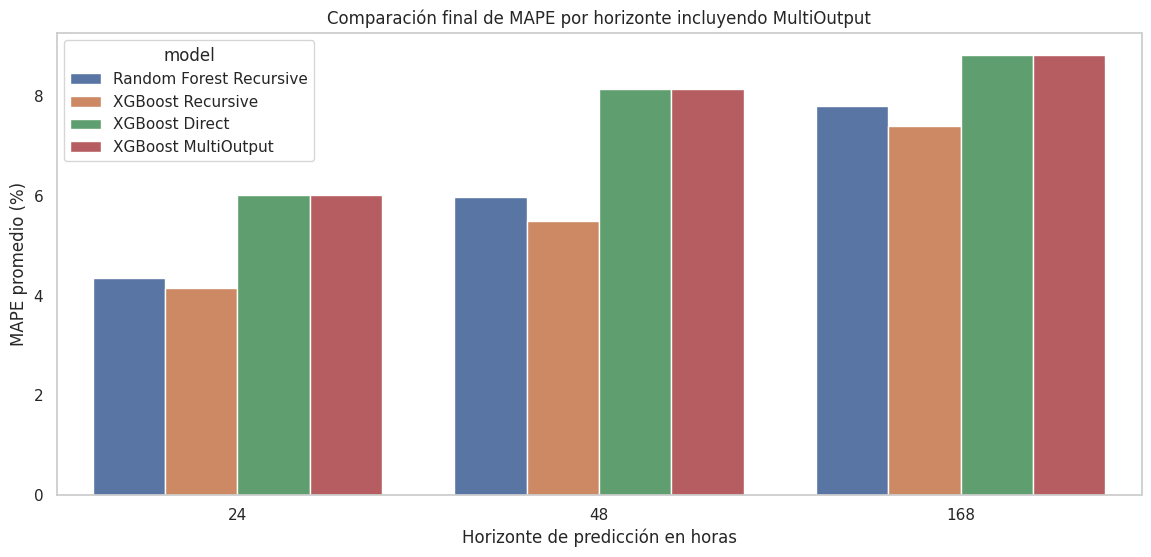

In [111]:
# ============================================================
# 109. GRÁFICO FINAL INCLUYENDO MULTI-OUTPUT
# ============================================================

plt.figure(figsize=(14, 6))
sns.barplot(
    data=final_model_comparison,
    x='horizon_hours',
    y='MAPE_mean',
    hue='model'
)

plt.title('Comparación final de MAPE por horizonte incluyendo MultiOutput')
plt.xlabel('Horizonte de predicción en horas')
plt.ylabel('MAPE promedio (%)')
plt.grid(axis='y')
plt.show()

In [112]:
# ============================================================
# 110. SELECCIÓN AUTOMÁTICA DEL MEJOR MODELO POR HORIZONTE
# ============================================================

best_model_by_horizon = (
    final_model_comparison
    .sort_values(['horizon_hours', 'MAPE_mean'])
    .groupby('horizon_hours')
    .first()
    .reset_index()
)

best_model_by_horizon

,horizon_hours,model,MAE_mean,RMSE_mean,MAPE_mean,MAPE_std,n_origins
0,24,XGBoost Recursive,"1,440.40","1,750.58",4.15,2.44,52.00
1,48,XGBoost Recursive,"1,851.23","2,237.13",5.49,3.05,52.00
2,168,XGBoost Recursive,"2,428.70","3,003.23",7.41,3.10,52.00
